# C01 — Environment and Project Configuration

This section initializes the execution environment and defines the shared
configuration used throughout the Core pipeline.

It mounts Google Drive, loads the common Python dependencies, configures
logging, and defines the project paths used for input data, database storage,
standard outputs, and quality artifacts.

In [70]:
# @title
# ============================================================
# C01 — ENVIRONMENT AND PROJECT CONFIGURATION
# ============================================================

from pathlib import Path
import logging
import sqlite3

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import drive


# ------------------------------------------------------------
# Logging configuration
# ------------------------------------------------------------

logging.basicConfig(
    level=logging.INFO,
    format="%(levelname)s | %(message)s",
    force=True
)

logger = logging.getLogger("FSSM")
logger.setLevel(logging.INFO)


# ------------------------------------------------------------
# Google Drive
# ------------------------------------------------------------

logger.info("[C01] Mounting Google Drive")

drive.mount("/content/drive")


# ------------------------------------------------------------
# Project configuration
# ------------------------------------------------------------

PROJECT_ROOT = Path(
    "/content/drive/MyDrive/_MyDrive/Colab Notebooks/"
    "Functional Structural Signature Model"
)

DB_DIR = PROJECT_ROOT / "db"
INPUT_DIR = PROJECT_ROOT / "input"
OUTPUT_DIR = PROJECT_ROOT / "output"
QUALITY_DIR = PROJECT_ROOT / "quality"

DB_PATH = DB_DIR / "DB_BASELINE.sqlite"
RAW_BASELINE_PATH = INPUT_DIR / "RAW_BASELINE.csv"


# ------------------------------------------------------------
# Directory structure initialization
# ------------------------------------------------------------

PROJECT_DIRECTORIES = [
    DB_DIR,
    INPUT_DIR,
    OUTPUT_DIR,
    QUALITY_DIR,
]

for directory in PROJECT_DIRECTORIES:
    directory.mkdir(
        parents=True,
        exist_ok=True
    )

logger.info(
    "[C01] Project directory structure initialized"
)


# ------------------------------------------------------------
# Standard input check
# ------------------------------------------------------------

if not RAW_BASELINE_PATH.exists():
    logger.warning(
        "[C01] Standard input file not found: %s",
        RAW_BASELINE_PATH
    )
else:
    logger.info(
        "[C01] Standard input file found: %s",
        RAW_BASELINE_PATH
    )


# ------------------------------------------------------------
# Configuration summary
# ------------------------------------------------------------

logger.info("[C01] Project environment initialized")
logger.info("[C01] Project root: %s", PROJECT_ROOT)
logger.info("[C01] Database: %s", DB_PATH)
logger.info("[C01] Input directory: %s", INPUT_DIR)
logger.info("[C01] Output directory: %s", OUTPUT_DIR)
logger.info("[C01] Quality directory: %s", QUALITY_DIR)

INFO | [C01] Mounting Google Drive
INFO | [C01] Project directory structure initialized
INFO | [C01] Standard input file found: /content/drive/MyDrive/_MyDrive/Colab Notebooks/Functional Structural Signature Model/input/RAW_BASELINE.csv
INFO | [C01] Project environment initialized
INFO | [C01] Project root: /content/drive/MyDrive/_MyDrive/Colab Notebooks/Functional Structural Signature Model
INFO | [C01] Database: /content/drive/MyDrive/_MyDrive/Colab Notebooks/Functional Structural Signature Model/db/DB_BASELINE.sqlite
INFO | [C01] Input directory: /content/drive/MyDrive/_MyDrive/Colab Notebooks/Functional Structural Signature Model/input
INFO | [C01] Output directory: /content/drive/MyDrive/_MyDrive/Colab Notebooks/Functional Structural Signature Model/output
INFO | [C01] Quality directory: /content/drive/MyDrive/_MyDrive/Colab Notebooks/Functional Structural Signature Model/quality


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# C02 — Database Initialization and Raw Baseline Loading

This step initializes the SQLite database used by the Core pipeline and performs
a full refresh of the raw baseline.

The database tables are recreated to guarantee a clean processing state.
The raw baseline is then loaded from the input CSV file, converted into the
expected numerical format, enriched with the initial structural indicators,
and stored in `TB_BASELINE`.

At the end of this step, the database contains the normalized starting dataset
used by the subsequent Core processing stages.

In [71]:
# @title
# ============================================================
# C02.1 — DATABASE INITIALIZATION
# ============================================================

logger.info("[C02] Initializing baseline database")

schema_sql = """
DROP TABLE IF EXISTS TB_BASELINE;

CREATE TABLE TB_BASELINE (
    PROJECT_CODE           TEXT,
    APPLICATION_DOMAIN     TEXT,
    FP_EFFORT              REAL,
    IFPUG_FP               REAL,
    IFPUG_ILF              REAL,
    IFPUG_EIF              REAL,
    IFPUG_EI               REAL,
    IFPUG_EQ               REAL,
    IFPUG_EO               REAL,

    -- Derived metrics
    IFPUG_PROD_GREZZA_FP   REAL,
    IS_ILF                 REAL,
    IS_EIF                 REAL,
    IS_EI                  REAL,
    IS_EQ                  REAL,
    IS_EO                  REAL,
    IFPUG_PROD_ATTESA_FP   REAL,
    STRUCTURAL_PROD_INDEX  REAL,
    DIST_STRUTTURALE       REAL,

    CLUSTER                TEXT,
    DATASET_TYPE           TEXT,
    CLASSE_COERENZA        TEXT,
    NOTE_PROFILO           TEXT
);


DROP TABLE IF EXISTS TB_BASELINE_PROFILE;

CREATE TABLE TB_BASELINE_PROFILE (
    APPLICATION_DOMAIN      TEXT,
    CLUSTER                 TEXT,

    -- Sample metrics
    N_PROGETTI              INTEGER,
    DATASET_TYPE            TEXT,
    FP_EFFORT               REAL,
    IFPUG_FP                REAL,
    PROD_GREZZA_FP          REAL,

    -- Aggregated structural indices
    IS_ILF                  REAL,
    IS_EIF                  REAL,
    IS_EI                   REAL,
    IS_EQ                   REAL,
    IS_EO                   REAL,

    -- Structural profile coefficients
    B_ILF                   REAL,
    B_EIF                   REAL,
    B_EI                    REAL,
    B_EQ                    REAL,
    B_EO                    REAL,

    -- Profile quality indicators
    N_COMP_MARGINALI        INTEGER,
    N_BETA_NEGATIVI         INTEGER,
    N_COMP_MISMATCH_IS_B    INTEGER,
    IS_DOMINANZA_FORTE      INTEGER,
    IS_PROFILO_PIATTO       INTEGER,
    PROFILE_CLASS           TEXT,
    PROFILE_QUALITY_NOTES   TEXT
);


DROP TABLE IF EXISTS TB_COMPARISON;

CREATE TABLE TB_COMPARISON (
    CLUSTER                   TEXT,
    GROUP_NAME                TEXT,

    N_PROGETTI                INTEGER,

    MEDIA_FP                  REAL,
    MEDIA_EFFORT              REAL,
    MEDIA_PROD_GREZZA         REAL,
    MEDIA_PROD_ATTESA         REAL,
    MEDIA_SPI                 REAL,
    MEDIA_DIST_STRUTTURALE    REAL,
    MEDIA_DEVIANCE            REAL,

    MEDIANA_FP                REAL,
    MEDIANA_EFFORT            REAL,
    MEDIANA_PROD_GREZZA       REAL,
    MEDIANA_PROD_ATTESA       REAL,
    MEDIANA_SPI               REAL,
    MEDIANA_DIST_STRUTTURALE  REAL,
    MEDIANA_DEVIANCE          REAL,

    ICS                       REAL,
    ICP                       REAL,
    IAS                       REAL,

    PRIMARY KEY (CLUSTER, GROUP_NAME)
);
"""

with sqlite3.connect(DB_PATH) as conn:
    conn.executescript(schema_sql)

logger.info("[C02] Database tables successfully initialized")

INFO | [C02] Initializing baseline database
INFO | [C02] Database tables successfully initialized


In [72]:
# @title
# ============================================================
# C02.2 — RAW BASELINE LOADING
# ============================================================

logger.info("[C02] Loading raw baseline")

raw_baseline_path = INPUT_DIR / "RAW_BASELINE.csv"

df = pd.read_csv(
    raw_baseline_path,
    sep=";",
    decimal=",",
    encoding="utf-8"
)

logger.info(
    "[C02] Raw baseline loaded: %d records",
    len(df)
)


# ------------------------------------------------------------
# Numeric columns
# ------------------------------------------------------------

numeric_columns = [
    "FP_EFFORT",
    "IFPUG_FP",
    "IFPUG_ILF",
    "IFPUG_EIF",
    "IFPUG_EI",
    "IFPUG_EQ",
    "IFPUG_EO",
]

df[numeric_columns] = df[numeric_columns].apply(
    pd.to_numeric,
    errors="coerce"
)


# ------------------------------------------------------------
# Raw productivity
# ------------------------------------------------------------

df["IFPUG_PROD_GREZZA_FP"] = (
    df["IFPUG_FP"]
    / df["FP_EFFORT"].replace(0, np.nan)
)


# ------------------------------------------------------------
# Structural indices
# ------------------------------------------------------------

component_columns = [
    "IFPUG_ILF",
    "IFPUG_EIF",
    "IFPUG_EI",
    "IFPUG_EQ",
    "IFPUG_EO",
]

structural_denominator = df[component_columns].sum(axis=1)

for component in ["ILF", "EIF", "EI", "EQ", "EO"]:
    df[f"IS_{component}"] = (
        df[f"IFPUG_{component}"]
        / structural_denominator.replace(0, np.nan)
    )


# ------------------------------------------------------------
# Initial classification
# ------------------------------------------------------------

df["CLUSTER"] = "0"

if "DATASET_TYPE" in df.columns:
    df["DATASET_TYPE"] = df["DATASET_TYPE"].fillna("B")
else:
    df["DATASET_TYPE"] = "B"


# ------------------------------------------------------------
# Database loading
# ------------------------------------------------------------

with sqlite3.connect(DB_PATH) as conn:
    df.to_sql(
        "TB_BASELINE",
        conn,
        if_exists="append",
        index=False
    )

    baseline_count = conn.execute(
        "SELECT COUNT(*) FROM TB_BASELINE"
    ).fetchone()[0]


logger.info(
    "[C02] Baseline refresh completed: %d records loaded",
    baseline_count
)

INFO | [C02] Loading raw baseline
INFO | [C02] Raw baseline loaded: 207 records
INFO | [C02] Baseline refresh completed: 207 records loaded


# C03 — Baseline Profile Creation

C03.1 — Baseline Profile Generation
        - Domain Profile / Profile 0
        - Cluster Profiles, when available
        - Calculation of aggregated IS
        - Calculation of Beta coefficients
        - Storage in TB_BASELINE_PROFILE

C03.2 — Baseline Profile Validation
        - Marginal components
        - Negative Beta coefficients
        - IS/Beta mismatch
        - Structural dominance
        - Flat structural profile
        - PROFILE_CLASS
        - PROFILE_QUALITY_NOTES

This step builds the structural productivity profiles used as reference models
for the subsequent analysis.

Two complementary profile levels are generated:

1. **Domain Baseline Profile (`CLUSTER = 0`)**  
   Represents the overall structural profile of all baseline projects belonging
   to the same application domain.

2. **Cluster Baseline Profiles (`CLUSTER != 0`)**  
   Represent more specific structural profiles for the clusters available within
   each application domain.

Both profile levels use the same calculation method: aggregated structural
indices and a multivariate linear regression without intercept are used to
derive the structural productivity coefficients.

Cluster-specific profiles are generated only when non-zero cluster assignments
are available in the baseline dataset.

All generated profiles are stored in `TB_BASELINE_PROFILE`.

In [73]:
# @title
# ============================================================
# C03.1 — BASELINE PROFILE CREATION
# ============================================================

logger.info("[C03] Starting baseline profile creation")


# ------------------------------------------------------------
# Load baseline projects
# ------------------------------------------------------------

with sqlite3.connect(DB_PATH) as conn:
    df_base = pd.read_sql_query(
        "SELECT * FROM TB_BASELINE",
        conn
    )

df_base["DATASET_TYPE"] = (
    df_base["DATASET_TYPE"]
    .astype(str)
    .str.strip()
    .str.upper()
)

df_base["CLUSTER"] = (
    df_base["CLUSTER"]
    .astype(str)
    .str.strip()
)

df_baseline = df_base[
    df_base["DATASET_TYPE"] == "B"
].copy()

logger.info(
    "[C03] Baseline projects available: %d",
    len(df_baseline)
)


# ------------------------------------------------------------
# Profile calculation
# ------------------------------------------------------------

def calculate_baseline_profile(
    df_subset,
    application_domain,
    cluster
):
    """
    Calculate a structural productivity profile for a subset
    of baseline projects.

    The profile includes aggregated structural indices,
    productivity regression coefficients, and overall
    productivity metrics.
    """

    profile_columns = [
        "FP_EFFORT",
        "IFPUG_FP",
        "IFPUG_ILF",
        "IFPUG_EIF",
        "IFPUG_EI",
        "IFPUG_EQ",
        "IFPUG_EO",
        "IS_ILF",
        "IS_EIF",
        "IS_EI",
        "IS_EQ",
        "IS_EO",
        "IFPUG_PROD_GREZZA_FP",
    ]

    df_subset = (
        df_subset
        .dropna(subset=profile_columns)
        .copy()
    )

    if df_subset.empty:
        logger.warning(
            "[C03] No valid projects for domain=%s, cluster=%s",
            application_domain,
            cluster
        )
        return None


    # --------------------------------------------------------
    # Aggregated structural indices
    # --------------------------------------------------------

    component_columns = [
        "IFPUG_ILF",
        "IFPUG_EIF",
        "IFPUG_EI",
        "IFPUG_EQ",
        "IFPUG_EO",
    ]

    component_totals = df_subset[
        component_columns
    ].sum()

    total_components = component_totals.sum()

    if total_components == 0:
        logger.warning(
            "[C03] Zero functional components for domain=%s, cluster=%s",
            application_domain,
            cluster
        )
        return None

    structural_indices = (
        component_totals
        / total_components
    )


    # --------------------------------------------------------
    # Structural productivity coefficients
    # --------------------------------------------------------

    structural_columns = [
        "IS_ILF",
        "IS_EIF",
        "IS_EI",
        "IS_EQ",
        "IS_EO",
    ]

    X = df_subset[
        structural_columns
    ].to_numpy(dtype=float)

    y = df_subset[
        "IFPUG_PROD_GREZZA_FP"
    ].to_numpy(dtype=float)

    valid_rows = (
        ~np.isnan(X).any(axis=1)
        & ~np.isnan(y)
    )

    X = X[valid_rows]
    y = y[valid_rows]

    if X.shape[0] < X.shape[1]:
        logger.warning(
            "[C03] Insufficient projects for regression: "
            "domain=%s, cluster=%s, projects=%d",
            application_domain,
            cluster,
            X.shape[0]
        )
        return None

    beta, _, _, _ = np.linalg.lstsq(
        X,
        y,
        rcond=None
    )


    # --------------------------------------------------------
    # Profile aggregates
    # --------------------------------------------------------

    total_effort = df_subset[
        "FP_EFFORT"
    ].sum()

    total_fp = df_subset[
        "IFPUG_FP"
    ].sum()

    raw_productivity = (
        total_fp / total_effort
        if total_effort != 0
        else np.nan
    )


    return {
        "APPLICATION_DOMAIN": application_domain,
        "DATASET_TYPE": "B",
        "CLUSTER": str(cluster),

        "IS_ILF": structural_indices["IFPUG_ILF"],
        "IS_EIF": structural_indices["IFPUG_EIF"],
        "IS_EI": structural_indices["IFPUG_EI"],
        "IS_EQ": structural_indices["IFPUG_EQ"],
        "IS_EO": structural_indices["IFPUG_EO"],

        "B_ILF": beta[0],
        "B_EIF": beta[1],
        "B_EI": beta[2],
        "B_EQ": beta[3],
        "B_EO": beta[4],

        "N_PROGETTI": len(df_subset),
        "FP_EFFORT": total_effort,
        "IFPUG_FP": total_fp,
        "PROD_GREZZA_FP": raw_productivity,
    }


# ------------------------------------------------------------
# C03.1 — Domain baseline profiles (Cluster 0)
# ------------------------------------------------------------

profiles = []

for application_domain, df_domain in df_baseline.groupby(
    "APPLICATION_DOMAIN"
):

    profile = calculate_baseline_profile(
        df_subset=df_domain,
        application_domain=application_domain,
        cluster="0"
    )

    if profile is not None:
        profiles.append(profile)

        logger.info(
            "[C03] Domain profile created: %s / cluster 0",
            application_domain
        )


# ------------------------------------------------------------
# C03.2 — Cluster baseline profiles
# ------------------------------------------------------------

for application_domain, df_domain in df_baseline.groupby(
    "APPLICATION_DOMAIN"
):

    cluster_values = sorted(
        cluster
        for cluster in df_domain["CLUSTER"].dropna().unique()
        if cluster != "0"
    )

    for cluster in cluster_values:

        df_cluster = df_domain[
            df_domain["CLUSTER"] == cluster
        ]

        profile = calculate_baseline_profile(
            df_subset=df_cluster,
            application_domain=application_domain,
            cluster=cluster
        )

        if profile is not None:
            profiles.append(profile)

            logger.info(
                "[C03] Cluster profile created: %s / cluster %s",
                application_domain,
                cluster
            )


# ------------------------------------------------------------
# Store generated profiles
# ------------------------------------------------------------

df_profiles = pd.DataFrame(profiles)

if df_profiles.empty:
    raise ValueError(
        "No baseline profiles were generated."
    )

with sqlite3.connect(DB_PATH) as conn:

    conn.execute(
        "DELETE FROM TB_BASELINE_PROFILE"
    )

    df_profiles.to_sql(
        "TB_BASELINE_PROFILE",
        conn,
        if_exists="append",
        index=False
    )


logger.info(
    "[C03] Baseline profile creation completed: %d profiles generated",
    len(df_profiles)
)

INFO | [C03] Starting baseline profile creation
INFO | [C03] Baseline projects available: 207
INFO | [C03] Domain profile created: Billing / cluster 0
INFO | [C03] Domain profile created: Data Platform / cluster 0
INFO | [C03] Domain profile created: Integration / cluster 0
INFO | [C03] Baseline profile creation completed: 3 profiles generated


In [74]:
# @title
# ============================================================
# C03.2 — BASELINE PROFILE VALIDATION
# ============================================================

logger.info("[C03.2] Starting baseline profile validation")


# ------------------------------------------------------------
# Load baseline profiles
# ------------------------------------------------------------

with sqlite3.connect(DB_PATH) as conn:
    df_profiles = pd.read_sql_query(
        "SELECT * FROM TB_BASELINE_PROFILE",
        conn
    )

if df_profiles.empty:
    raise ValueError(
        "TB_BASELINE_PROFILE is empty: no profiles available for validation."
    )

logger.info(
    "[C03.2] Profiles available for validation: %d",
    len(df_profiles)
)


# ------------------------------------------------------------
# Validation configuration
# ------------------------------------------------------------

COMPONENTS = ["ILF", "EIF", "EI", "EQ", "EO"]

MARGINAL_IS_THRESHOLD = 0.05
RELEVANT_IS_THRESHOLD = 0.10
BETA_MIN_THRESHOLD = 0.05
DOMINANCE_THRESHOLD = 0.60
FLAT_PROFILE_STD_THRESHOLD = 0.02


# ------------------------------------------------------------
# Profile validation
# ------------------------------------------------------------

quality_classes = []
quality_notes = []

num_marginal_components = []
num_negative_betas = []
num_is_beta_mismatches = []

dominance_flags = []
flat_profile_flags = []


for _, row in df_profiles.iterrows():

    n_projects = row["N_PROGETTI"]

    structural_indices = {
        component: row[f"IS_{component}"]
        for component in COMPONENTS
    }

    beta_coefficients = {
        component: row[f"B_{component}"]
        for component in COMPONENTS
    }


    # --------------------------------------------------------
    # 1. Marginal structural components
    # --------------------------------------------------------

    marginal_components = [
        component
        for component in COMPONENTS
        if (
            pd.notnull(structural_indices[component])
            and structural_indices[component] < MARGINAL_IS_THRESHOLD
        )
    ]


    # --------------------------------------------------------
    # 2. Negative Beta coefficients
    # --------------------------------------------------------

    negative_beta_components = [
        component
        for component in COMPONENTS
        if (
            pd.notnull(beta_coefficients[component])
            and beta_coefficients[component] < 0
        )
    ]


    # --------------------------------------------------------
    # 3. IS / Beta mismatch
    # --------------------------------------------------------

    mismatch_components = [
        component
        for component in COMPONENTS
        if (
            pd.notnull(structural_indices[component])
            and structural_indices[component] >= RELEVANT_IS_THRESHOLD
            and pd.notnull(beta_coefficients[component])
            and abs(beta_coefficients[component]) < BETA_MIN_THRESHOLD
        )
    ]


    # --------------------------------------------------------
    # 4. Structural dominance and flatness
    # --------------------------------------------------------

    valid_is_values = [
        structural_indices[component]
        for component in COMPONENTS
        if pd.notnull(structural_indices[component])
    ]

    max_is = (
        max(valid_is_values)
        if valid_is_values
        else np.nan
    )

    std_is = (
        float(np.nanstd(valid_is_values))
        if valid_is_values
        else np.nan
    )

    dominant_profile = (
        not np.isnan(max_is)
        and max_is > DOMINANCE_THRESHOLD
    )

    flat_profile = (
        not np.isnan(std_is)
        and std_is < FLAT_PROFILE_STD_THRESHOLD
    )


    # --------------------------------------------------------
    # 5. Profile quality classification
    # --------------------------------------------------------

    quality_class = "ALTA"

    # Low-quality profile
    if (
        pd.isna(n_projects)
        or n_projects < 3
        or len(negative_beta_components) >= 2
        or (
            dominant_profile
            and len(marginal_components) >= 3
        )
    ):
        quality_class = "BASSA"

    # Medium-quality profile
    elif (
        3 <= n_projects < 7
        or len(negative_beta_components) == 1
        or len(mismatch_components) >= 1
        or len(marginal_components) >= 2
        or dominant_profile
        or flat_profile
    ):
        quality_class = "MEDIA"


    # --------------------------------------------------------
    # 6. Diagnostic notes
    # --------------------------------------------------------

    notes = []

    if pd.isna(n_projects) or n_projects < 3:
        notes.append(
            "profile based on very few projects"
        )

    elif n_projects < 7:
        notes.append(
            "profile based on a limited number of projects"
        )

    if marginal_components:
        notes.append(
            "marginal components: "
            + ", ".join(marginal_components)
        )

    if negative_beta_components:
        notes.append(
            "negative Beta coefficients: "
            + ", ".join(negative_beta_components)
        )

    if mismatch_components:
        notes.append(
            "near-zero Beta coefficients for non-marginal components: "
            + ", ".join(mismatch_components)
        )

    if dominant_profile:
        notes.append(
            "profile dominated by a single structural component"
        )

    if flat_profile:
        notes.append(
            "nearly flat structural profile"
        )

    profile_notes = (
        "; ".join(notes)
        if notes
        else "profile consistent with the available information"
    )


    # --------------------------------------------------------
    # Collect validation results
    # --------------------------------------------------------

    quality_classes.append(quality_class)
    quality_notes.append(profile_notes)

    num_marginal_components.append(
        len(marginal_components)
    )

    num_negative_betas.append(
        len(negative_beta_components)
    )

    num_is_beta_mismatches.append(
        len(mismatch_components)
    )

    dominance_flags.append(
        1 if dominant_profile else 0
    )

    flat_profile_flags.append(
        1 if flat_profile else 0
    )


# ------------------------------------------------------------
# Add validation results to baseline profiles
# ------------------------------------------------------------

df_profiles["N_COMP_MARGINALI"] = (
    num_marginal_components
)

df_profiles["N_BETA_NEGATIVI"] = (
    num_negative_betas
)

df_profiles["N_COMP_MISMATCH_IS_B"] = (
    num_is_beta_mismatches
)

df_profiles["IS_DOMINANZA_FORTE"] = (
    dominance_flags
)

df_profiles["IS_PROFILO_PIATTO"] = (
    flat_profile_flags
)

df_profiles["PROFILE_CLASS"] = (
    quality_classes
)

df_profiles["PROFILE_QUALITY_NOTES"] = (
    quality_notes
)


# ------------------------------------------------------------
# Store validated profiles
# ------------------------------------------------------------

with sqlite3.connect(DB_PATH) as conn:

    conn.execute(
        "DELETE FROM TB_BASELINE_PROFILE"
    )

    df_profiles.to_sql(
        "TB_BASELINE_PROFILE",
        conn,
        if_exists="append",
        index=False
    )

    profile_count = conn.execute(
        "SELECT COUNT(*) FROM TB_BASELINE_PROFILE"
    ).fetchone()[0]


logger.info(
    "[C03.2] Baseline profile validation completed: %d profiles updated",
    profile_count
)

INFO | [C03.2] Starting baseline profile validation
INFO | [C03.2] Profiles available for validation: 3
INFO | [C03.2] Baseline profile validation completed: 3 profiles updated


# C04 — Baseline Enrichment

## C04.1 — Baseline Enrichment with Structural Profile

This step applies the corresponding baseline structural profile to each project.

The reference profile is selected according to the project's application domain
and cluster. Three indicators are then calculated:

- expected functional productivity;
- Structural Productivity Index (SPI);
- structural distance from the reference profile.

The calculated indicators are stored directly in `TB_BASELINE` and provide the
quantitative basis for the subsequent project coherence assessment.

## C04.2 — Project Coherence Assessment

This step evaluates each project's coherence with the empirical distribution
of its reference baseline population.

Reference thresholds are calculated independently for each application domain
and cluster using baseline projects only.

Two dimensions are considered:

- structural distance from the reference profile;
- absolute deviation of the Structural Productivity Index from its expected
  value of 1.

Two configurable percentile levels define the lower and upper coherence
thresholds. Projects within the lower thresholds are classified as highly
coherent, projects within the upper thresholds as moderately coherent, and
the remaining projects as low-coherence cases.

Projects without an applicable reference population are marked as not
assessable.



This step applies the corresponding baseline structural profile to each project.

For every project, the reference profile is selected according to its
application domain and cluster. The profile is then used to calculate:

- expected functional productivity;
- the Structural Productivity Index (SPI);
- the structural distance between the project and its reference profile.

The resulting indicators are stored directly in `TB_BASELINE` and provide
the quantitative basis for the subsequent project coherence assessment.

In [75]:
# @title
# ============================================================
# C04.1 — BASELINE ENRICHMENT WITH STRUCTURAL PROFILE
# ============================================================

logger.info("[C04.1] Starting baseline enrichment with structural profiles")


# ------------------------------------------------------------
# Load baseline data and reference profiles
# ------------------------------------------------------------

with sqlite3.connect(DB_PATH) as conn:
    df_base = pd.read_sql_query(
        "SELECT * FROM TB_BASELINE",
        conn
    )

    df_profiles = pd.read_sql_query(
        "SELECT * FROM TB_BASELINE_PROFILE",
        conn
    )

logger.info(
    "[C04.1] Loaded %d projects and %d baseline profiles",
    len(df_base),
    len(df_profiles)
)


# ------------------------------------------------------------
# Normalize key fields
# ------------------------------------------------------------

df_base["DATASET_TYPE"] = (
    df_base["DATASET_TYPE"]
    .astype(str)
    .str.strip()
    .str.upper()
)

df_profiles["DATASET_TYPE"] = (
    df_profiles["DATASET_TYPE"]
    .astype(str)
    .str.strip()
    .str.upper()
)

df_base["CLUSTER"] = (
    df_base["CLUSTER"]
    .astype(str)
    .str.strip()
)

df_profiles["CLUSTER"] = (
    df_profiles["CLUSTER"]
    .astype(str)
    .str.strip()
)


# ------------------------------------------------------------
# Select baseline reference profiles
# ------------------------------------------------------------

df_reference_profiles = df_profiles[
    df_profiles["DATASET_TYPE"] == "B"
].copy()

if df_reference_profiles.empty:
    raise ValueError(
        "No baseline profiles are available in TB_BASELINE_PROFILE."
    )

logger.info(
    "[C04.1] Baseline reference profiles available: %d",
    len(df_reference_profiles)
)


# ------------------------------------------------------------
# Rename profile structural indices
# ------------------------------------------------------------

df_reference_profiles = df_reference_profiles.rename(
    columns={
        "IS_ILF": "IS_ILF_PROFILE",
        "IS_EIF": "IS_EIF_PROFILE",
        "IS_EI": "IS_EI_PROFILE",
        "IS_EQ": "IS_EQ_PROFILE",
        "IS_EO": "IS_EO_PROFILE",
    }
)

df_reference_profiles = df_reference_profiles[
    [
        "APPLICATION_DOMAIN",
        "CLUSTER",
        "IS_ILF_PROFILE",
        "IS_EIF_PROFILE",
        "IS_EI_PROFILE",
        "IS_EQ_PROFILE",
        "IS_EO_PROFILE",
        "B_ILF",
        "B_EIF",
        "B_EI",
        "B_EQ",
        "B_EO",
    ]
]


# ------------------------------------------------------------
# Associate each project with its reference profile
# ------------------------------------------------------------

df_merged = df_base.merge(
    df_reference_profiles,
    on=["APPLICATION_DOMAIN", "CLUSTER"],
    how="left"
)

missing_profiles = df_merged[
    df_merged["B_ILF"].isna()
]

if not missing_profiles.empty:
    logger.warning(
        "[C04.1] Projects without a matching baseline profile: %d",
        len(missing_profiles)
    )

df_valid = df_merged[
    df_merged["B_ILF"].notna()
].copy()

logger.info(
    "[C04.1] Projects with a valid reference profile: %d",
    len(df_valid)
)


# ------------------------------------------------------------
# Expected functional productivity
# ------------------------------------------------------------

df_valid["IFPUG_PROD_ATTESA_FP"] = (
    df_valid["IS_ILF"] * df_valid["B_ILF"]
    + df_valid["IS_EIF"] * df_valid["B_EIF"]
    + df_valid["IS_EI"] * df_valid["B_EI"]
    + df_valid["IS_EQ"] * df_valid["B_EQ"]
    + df_valid["IS_EO"] * df_valid["B_EO"]
)


# ------------------------------------------------------------
# Structural Productivity Index
# ------------------------------------------------------------

df_valid["STRUCTURAL_PROD_INDEX"] = np.where(
    df_valid["IFPUG_PROD_ATTESA_FP"] != 0,
    (
        df_valid["IFPUG_PROD_GREZZA_FP"]
        / df_valid["IFPUG_PROD_ATTESA_FP"]
    ),
    np.nan
)


# ------------------------------------------------------------
# Structural distance
# ------------------------------------------------------------

df_valid["DIST_STRUTTURALE"] = np.sqrt(
    (df_valid["IS_ILF"] - df_valid["IS_ILF_PROFILE"]) ** 2
    + (df_valid["IS_EIF"] - df_valid["IS_EIF_PROFILE"]) ** 2
    + (df_valid["IS_EI"] - df_valid["IS_EI_PROFILE"]) ** 2
    + (df_valid["IS_EQ"] - df_valid["IS_EQ_PROFILE"]) ** 2
    + (df_valid["IS_EO"] - df_valid["IS_EO_PROFILE"]) ** 2
)


# ------------------------------------------------------------
# Update TB_BASELINE
# ------------------------------------------------------------

with sqlite3.connect(DB_PATH) as conn:

    cursor = conn.cursor()
    updated_rows = 0

    for _, row in df_valid.iterrows():

        cursor.execute(
            """
            UPDATE TB_BASELINE
            SET
                IFPUG_PROD_ATTESA_FP = ?,
                STRUCTURAL_PROD_INDEX = ?,
                DIST_STRUTTURALE = ?
            WHERE PROJECT_CODE = ?
              AND APPLICATION_DOMAIN = ?
              AND DATASET_TYPE = ?
              AND CLUSTER = ?;
            """,
            (
                float(row["IFPUG_PROD_ATTESA_FP"])
                if pd.notnull(row["IFPUG_PROD_ATTESA_FP"])
                else None,

                float(row["STRUCTURAL_PROD_INDEX"])
                if pd.notnull(row["STRUCTURAL_PROD_INDEX"])
                else None,

                float(row["DIST_STRUTTURALE"])
                if pd.notnull(row["DIST_STRUTTURALE"])
                else None,

                row["PROJECT_CODE"],
                row["APPLICATION_DOMAIN"],
                row["DATASET_TYPE"],
                row["CLUSTER"],
            )
        )

        updated_rows += cursor.rowcount


logger.info(
    "[C04.1] Baseline enrichment completed: %d projects updated",
    updated_rows
)

INFO | [C04.1] Starting baseline enrichment with structural profiles
INFO | [C04.1] Loaded 207 projects and 3 baseline profiles
INFO | [C04.1] Baseline reference profiles available: 3
INFO | [C04.1] Projects with a valid reference profile: 207
INFO | [C04.1] Baseline enrichment completed: 207 projects updated


In [76]:
# @title
# ============================================================
# C04.2 — PROJECT COHERENCE ASSESSMENT
# ============================================================

logger.info("[C04.2] Starting project coherence assessment")


# ------------------------------------------------------------
# Coherence configuration
# ------------------------------------------------------------

PERCENTILE_MIN = 0.40
PERCENTILE_MAX = 0.80


# ------------------------------------------------------------
# Load enriched projects
# ------------------------------------------------------------

with sqlite3.connect(DB_PATH) as conn:
    df_base = pd.read_sql_query(
        "SELECT * FROM TB_BASELINE",
        conn
    )

logger.info(
    "[C04.2] Projects available for coherence assessment: %d",
    len(df_base)
)


# ------------------------------------------------------------
# Normalize key fields
# ------------------------------------------------------------

df_base["DATASET_TYPE"] = (
    df_base["DATASET_TYPE"]
    .astype(str)
    .str.strip()
    .str.upper()
)

df_base["CLUSTER"] = (
    df_base["CLUSTER"]
    .astype(str)
    .str.strip()
)


# ------------------------------------------------------------
# Build baseline reference population
# ------------------------------------------------------------

df_reference = (
    df_base[
        df_base["DATASET_TYPE"] == "B"
    ]
    .dropna(
        subset=[
            "STRUCTURAL_PROD_INDEX",
            "DIST_STRUTTURALE",
        ]
    )
    .copy()
)

if df_reference.empty:
    raise ValueError(
        "No baseline projects with valid structural indicators "
        "are available for threshold calculation."
    )


# Structural Productivity Index deviation from expected value
df_reference["SPI_REL_ERR"] = (
    df_reference["STRUCTURAL_PROD_INDEX"] - 1.0
).abs()


# ------------------------------------------------------------
# Calculate coherence thresholds
# ------------------------------------------------------------

def compute_thresholds(group):
    """
    Calculate lower and upper coherence thresholds for a
    baseline population.
    """

    return pd.Series(
        {
            "DIST_THRESHOLD_MIN":
                group["DIST_STRUTTURALE"].quantile(
                    PERCENTILE_MIN
                ),

            "DIST_THRESHOLD_MAX":
                group["DIST_STRUTTURALE"].quantile(
                    PERCENTILE_MAX
                ),

            "SPI_THRESHOLD_MIN":
                group["SPI_REL_ERR"].quantile(
                    PERCENTILE_MIN
                ),

            "SPI_THRESHOLD_MAX":
                group["SPI_REL_ERR"].quantile(
                    PERCENTILE_MAX
                ),

            "N_BASELINE_REF":
                len(group),
        }
    )


df_thresholds = (
    df_reference
    .groupby(
        ["APPLICATION_DOMAIN", "CLUSTER"],
        as_index=False
    )
    .apply(compute_thresholds)
)


logger.info(
    "[C04.2] Coherence thresholds generated for %d reference groups",
    len(df_thresholds)
)


# ------------------------------------------------------------
# Associate thresholds with all projects
# ------------------------------------------------------------

df_all = df_base.merge(
    df_thresholds,
    on=["APPLICATION_DOMAIN", "CLUSTER"],
    how="left"
)

projects_without_thresholds = (
    df_all["DIST_THRESHOLD_MIN"]
    .isna()
    .sum()
)

if projects_without_thresholds > 0:
    logger.warning(
        "[C04.2] Projects without specific coherence thresholds: %d",
        projects_without_thresholds
    )


# ------------------------------------------------------------
# Coherence classification
# ------------------------------------------------------------

def classify_coherence(row):
    """
    Classify a project using the thresholds associated with its
    application domain and cluster.
    """

    spi = row["STRUCTURAL_PROD_INDEX"]
    structural_distance = row["DIST_STRUTTURALE"]

    dist_threshold_min = row["DIST_THRESHOLD_MIN"]
    dist_threshold_max = row["DIST_THRESHOLD_MAX"]

    spi_threshold_min = row["SPI_THRESHOLD_MIN"]
    spi_threshold_max = row["SPI_THRESHOLD_MAX"]


    # Missing reference population
    if (
        pd.isna(dist_threshold_min)
        or pd.isna(spi_threshold_min)
    ):
        return "Non valutabile"


    # Missing project indicators
    if (
        pd.isna(spi)
        or pd.isna(structural_distance)
    ):
        return "Non valutabile"


    spi_deviation = abs(spi - 1.0)


    # High coherence
    if (
        structural_distance <= dist_threshold_min
        and spi_deviation <= spi_threshold_min
    ):
        return "Alta coerenza"


    # Medium coherence
    if (
        structural_distance <= dist_threshold_max
        and spi_deviation <= spi_threshold_max
    ):
        return "Media coerenza"


    # Low coherence
    return "Bassa coerenza"


# ------------------------------------------------------------
# Coherence interpretation
# ------------------------------------------------------------

def build_profile_note(coherence_class):

    if coherence_class == "Alta coerenza":
        return (
            "Structure and productivity are aligned with the "
            "reference structural profile for the corresponding "
            "application domain and cluster."
        )

    if coherence_class == "Media coerenza":
        return (
            "Structure and/or productivity show moderate deviations "
            "but remain compatible with the reference structural profile."
        )

    if coherence_class == "Bassa coerenza":
        return (
            "Structure and/or productivity differ significantly from "
            "the reference structural profile; the project may represent "
            "an outlier or a non-comparable context."
        )

    return (
        "Coherence assessment is not available because no comparable "
        "baseline reference population is available."
    )


# ------------------------------------------------------------
# Apply coherence assessment
# ------------------------------------------------------------

df_all["CLASSE_COERENZA"] = (
    df_all.apply(
        classify_coherence,
        axis=1
    )
)

df_all["NOTE_PROFILO"] = (
    df_all["CLASSE_COERENZA"]
    .apply(build_profile_note)
)


coherence_distribution = (
    df_all["CLASSE_COERENZA"]
    .value_counts()
    .to_dict()
)

logger.info(
    "[C04.2] Coherence distribution: %s",
    coherence_distribution
)


# ------------------------------------------------------------
# Update TB_BASELINE
# ------------------------------------------------------------

with sqlite3.connect(DB_PATH) as conn:

    cursor = conn.cursor()
    updated_rows = 0

    for _, row in df_all.iterrows():

        cursor.execute(
            """
            UPDATE TB_BASELINE
            SET
                CLASSE_COERENZA = ?,
                NOTE_PROFILO = ?
            WHERE PROJECT_CODE = ?
              AND APPLICATION_DOMAIN = ?
              AND DATASET_TYPE = ?
              AND CLUSTER = ?;
            """,
            (
                row["CLASSE_COERENZA"],
                row["NOTE_PROFILO"],
                row["PROJECT_CODE"],
                row["APPLICATION_DOMAIN"],
                row["DATASET_TYPE"],
                row["CLUSTER"],
            )
        )

        updated_rows += cursor.rowcount


logger.info(
    "[C04.2] Project coherence assessment completed: %d projects updated",
    updated_rows
)

INFO | [C04.2] Starting project coherence assessment
INFO | [C04.2] Projects available for coherence assessment: 207
/tmp/ipykernel_489/1609543306.py:125: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(compute_thresholds)
INFO | [C04.2] Coherence thresholds generated for 3 reference groups
INFO | [C04.2] Coherence distribution: {'Media coerenza': 90, 'Bassa coerenza': 74, 'Alta coerenza': 43}
INFO | [C04.2] Project coherence assessment completed: 207 projects updated


# C05 — Test Project Comparison with Baseline

This step compares each test dataset with its corresponding baseline population.

The analysis is performed independently for each application domain and cluster.
Baseline projects (`DATASET_TYPE = 'B'`) are used as the reference group (`B0`),
while every other available dataset type is treated as a comparison group.

For each group, descriptive statistics are calculated for size, effort,
productivity, Structural Productivity Index, structural distance, and deviance.

Three comparison indicators are also derived:

- **ICS** — relative structural distance with respect to the baseline;
- **ICP** — relative productivity deviance with respect to the baseline;
- **IAS** — absolute deviation of the median Structural Productivity Index from 1.

The resulting aggregated comparison dataset is stored in `TB_COMPARISON`.

In [77]:
# @title
# ============================================================
# C05 — TEST PROJECT COMPARISON WITH BASELINE
# ============================================================

logger.info("[C05] Starting test project comparison with baseline")


# ------------------------------------------------------------
# Load enriched project data
# ------------------------------------------------------------

with sqlite3.connect(DB_PATH) as conn:
    df_base = pd.read_sql_query(
        "SELECT * FROM TB_BASELINE",
        conn
    )

logger.info(
    "[C05] Projects available for comparison: %d",
    len(df_base)
)


# ------------------------------------------------------------
# Normalize grouping fields
# ------------------------------------------------------------

df_base["DATASET_TYPE"] = (
    df_base["DATASET_TYPE"]
    .astype(str)
    .str.strip()
    .str.upper()
)

df_base["CLUSTER"] = (
    df_base["CLUSTER"]
    .astype(str)
    .str.strip()
)

df_base["APPLICATION_DOMAIN"] = (
    df_base["APPLICATION_DOMAIN"]
    .astype(str)
    .str.strip()
)


# ------------------------------------------------------------
# Calculate productivity deviance
# ------------------------------------------------------------

df_base["DEVIANCE"] = (
    df_base["IFPUG_PROD_GREZZA_FP"]
    - df_base["IFPUG_PROD_ATTESA_FP"]
).abs()


# ------------------------------------------------------------
# Group statistics
# ------------------------------------------------------------

def compute_group_statistics(df_group):
    """
    Calculate mean and median statistics for a baseline
    or test-project group.
    """

    return {
        "N_PROGETTI": len(df_group),

        "MEDIA_FP":
            df_group["IFPUG_FP"].mean(),

        "MEDIA_EFFORT":
            df_group["FP_EFFORT"].mean(),

        "MEDIA_PROD_GREZZA":
            df_group["IFPUG_PROD_GREZZA_FP"].mean(),

        "MEDIA_PROD_ATTESA":
            df_group["IFPUG_PROD_ATTESA_FP"].mean(),

        "MEDIA_SPI":
            df_group["STRUCTURAL_PROD_INDEX"].mean(),

        "MEDIA_DIST_STRUTTURALE":
            df_group["DIST_STRUTTURALE"].mean(),

        "MEDIA_DEVIANCE":
            df_group["DEVIANCE"].mean(),

        "MEDIANA_FP":
            df_group["IFPUG_FP"].median(),

        "MEDIANA_EFFORT":
            df_group["FP_EFFORT"].median(),

        "MEDIANA_PROD_GREZZA":
            df_group["IFPUG_PROD_GREZZA_FP"].median(),

        "MEDIANA_PROD_ATTESA":
            df_group["IFPUG_PROD_ATTESA_FP"].median(),

        "MEDIANA_SPI":
            df_group["STRUCTURAL_PROD_INDEX"].median(),

        "MEDIANA_DIST_STRUTTURALE":
            df_group["DIST_STRUTTURALE"].median(),

        "MEDIANA_DEVIANCE":
            df_group["DEVIANCE"].median(),
    }


def safe_ratio(numerator, denominator):
    """
    Return a ratio when the denominator is valid.
    """

    if (
        pd.isna(denominator)
        or denominator == 0
    ):
        return np.nan

    return float(
        numerator / denominator
    )


# ------------------------------------------------------------
# Compare each application domain and cluster
# ------------------------------------------------------------

comparison_rows = []

group_keys = (
    df_base[
        ["APPLICATION_DOMAIN", "CLUSTER"]
    ]
    .dropna()
    .drop_duplicates()
    .sort_values(
        ["APPLICATION_DOMAIN", "CLUSTER"]
    )
)


for _, group_key in group_keys.iterrows():

    application_domain = (
        group_key["APPLICATION_DOMAIN"]
    )

    cluster = (
        group_key["CLUSTER"]
    )

    df_group = df_base[
        (df_base["APPLICATION_DOMAIN"] == application_domain)
        & (df_base["CLUSTER"] == cluster)
    ].copy()


    # --------------------------------------------------------
    # Baseline reference group
    # --------------------------------------------------------

    df_baseline = df_group[
        df_group["DATASET_TYPE"] == "B"
    ].copy()

    if df_baseline.empty:
        logger.warning(
            "[C05] No baseline projects for domain=%s, cluster=%s",
            application_domain,
            cluster
        )
        continue


    baseline_stats = compute_group_statistics(
        df_baseline
    )

    baseline_ias = abs(
        baseline_stats["MEDIANA_SPI"] - 1.0
    )


    # Baseline reference row
    comparison_rows.append(
        {
            "APPLICATION_DOMAIN":
                application_domain,

            "CLUSTER":
                cluster,

            "GROUP_NAME":
                "B0",

            **baseline_stats,

            "ICS":
                1.0,

            "ICP":
                1.0,

            "IAS":
                baseline_ias,
        }
    )


    # --------------------------------------------------------
    # Test groups
    # --------------------------------------------------------

    test_dataset_types = sorted(
        df_group.loc[
            df_group["DATASET_TYPE"] != "B",
            "DATASET_TYPE"
        ]
        .dropna()
        .unique()
    )


    for dataset_type in test_dataset_types:

        df_test = df_group[
            df_group["DATASET_TYPE"]
            == dataset_type
        ].copy()

        test_stats = compute_group_statistics(
            df_test
        )


        # Structural comparison index
        ics = safe_ratio(
            test_stats[
                "MEDIANA_DIST_STRUTTURALE"
            ],
            baseline_stats[
                "MEDIANA_DIST_STRUTTURALE"
            ]
        )


        # Productivity comparison index
        icp = safe_ratio(
            test_stats[
                "MEDIANA_DEVIANCE"
            ],
            baseline_stats[
                "MEDIANA_DEVIANCE"
            ]
        )


        # Absolute structural productivity deviation
        ias = abs(
            test_stats["MEDIANA_SPI"] - 1.0
        )


        comparison_rows.append(
            {
                "APPLICATION_DOMAIN":
                    application_domain,

                "CLUSTER":
                    cluster,

                "GROUP_NAME":
                    dataset_type,

                **test_stats,

                "ICS":
                    ics,

                "ICP":
                    icp,

                "IAS":
                    ias,
            }
        )


# ------------------------------------------------------------
# Build comparison dataset
# ------------------------------------------------------------

df_comparison = pd.DataFrame(
    comparison_rows
)

if df_comparison.empty:
    raise ValueError(
        "No valid baseline/test comparisons were generated."
    )


logger.info(
    "[C05] Comparison groups generated: %d",
    len(df_comparison)
)


# ------------------------------------------------------------
# Store comparison results
# ------------------------------------------------------------

with sqlite3.connect(DB_PATH) as conn:

    df_comparison.to_sql(
        "TB_COMPARISON",
        conn,
        if_exists="replace",
        index=False
    )

    comparison_count = conn.execute(
        "SELECT COUNT(*) FROM TB_COMPARISON"
    ).fetchone()[0]


logger.info(
    "[C05] Test project comparison completed: %d comparison rows stored",
    comparison_count
)

INFO | [C05] Starting test project comparison with baseline
INFO | [C05] Projects available for comparison: 207
INFO | [C05] Comparison groups generated: 3
INFO | [C05] Test project comparison completed: 3 comparison rows stored


# C06 — Comparison Reporting and Visualization

This step provides the reporting and visualization layer of the Core pipeline.

It summarizes the processed baseline and test-project data and produces the
main graphical views required to interpret structural profiles and project
comparisons.

The analysis includes:

- an application-domain summary;
- structural-index distributions;
- productivity-profile coefficients;
- project dispersion in terms of expected productivity and structural distance.

Each reporting dataset is exported together with its corresponding figure.
All generated artifacts are stored in the `Quality` directory using the
`C06_xx` naming convention.

This step is read-only with respect to the project database.

INFO | [C06] Starting comparison reporting and visualization
INFO | [C06] Loaded 207 projects, 3 profiles and 3 comparison rows
INFO | [C06] After filters: projects=207, profiles=3, comparison rows=3
INFO | [C06] Table saved: /content/drive/MyDrive/_MyDrive/Colab Notebooks/Functional Structural Signature Model/quality/C06_01_domain_summary.csv


,APPLICATION_DOMAIN,PROJECT_COUNT,TOTAL_EFFORT,TOTAL_FUNCTION_POINTS
0,Billing,62,1759.3,2535.0
1,Data Platform,67,1558.3,3222.0
2,Integration,78,1474.4,2433.0


INFO | [C06] Table saved: /content/drive/MyDrive/_MyDrive/Colab Notebooks/Functional Structural Signature Model/quality/C06_02_structural_index_distribution.csv
INFO | [C06] Figure saved: /content/drive/MyDrive/_MyDrive/Colab Notebooks/Functional Structural Signature Model/quality/C06_02_structural_index_distribution.png


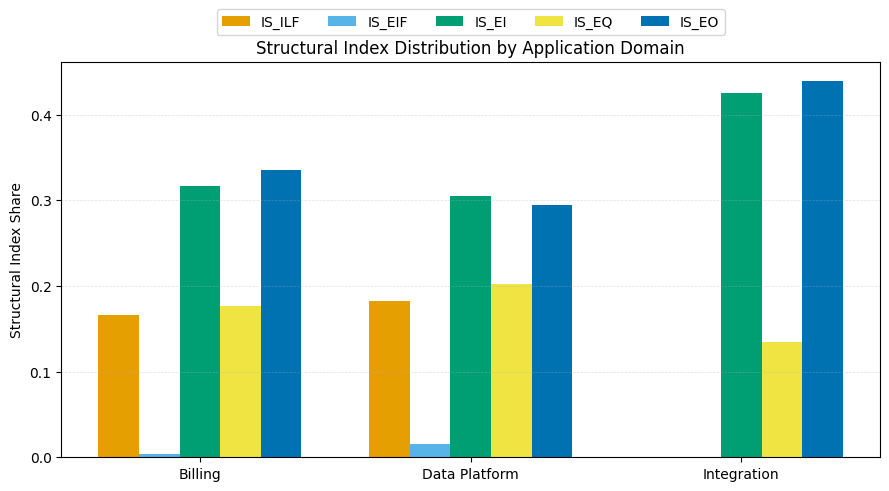

INFO | [C06] Table saved: /content/drive/MyDrive/_MyDrive/Colab Notebooks/Functional Structural Signature Model/quality/C06_03_productivity_profile_coefficients.csv
INFO | [C06] Figure saved: /content/drive/MyDrive/_MyDrive/Colab Notebooks/Functional Structural Signature Model/quality/C06_03_productivity_profile_coefficients.png


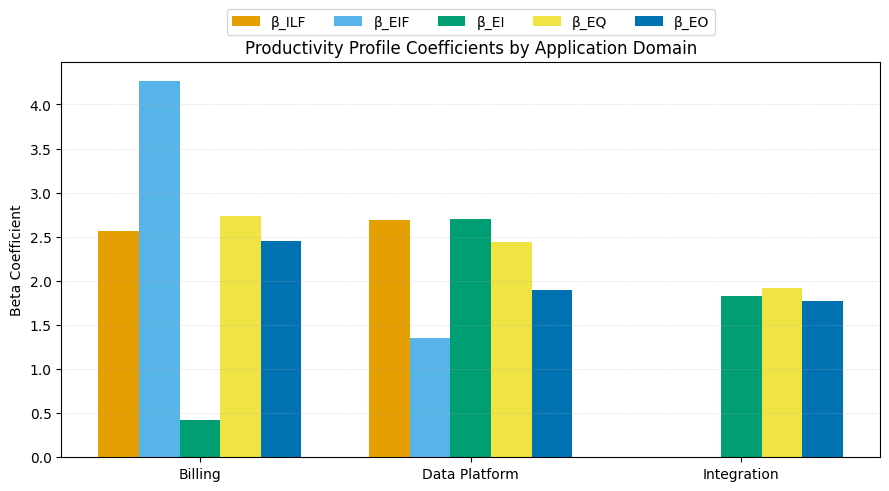

INFO | [C06] Table saved: /content/drive/MyDrive/_MyDrive/Colab Notebooks/Functional Structural Signature Model/quality/C06_04_expected_productivity_vs_structural_distance.csv
INFO | [C06] Figure saved: /content/drive/MyDrive/_MyDrive/Colab Notebooks/Functional Structural Signature Model/quality/C06_04_expected_productivity_vs_structural_distance_billing.png


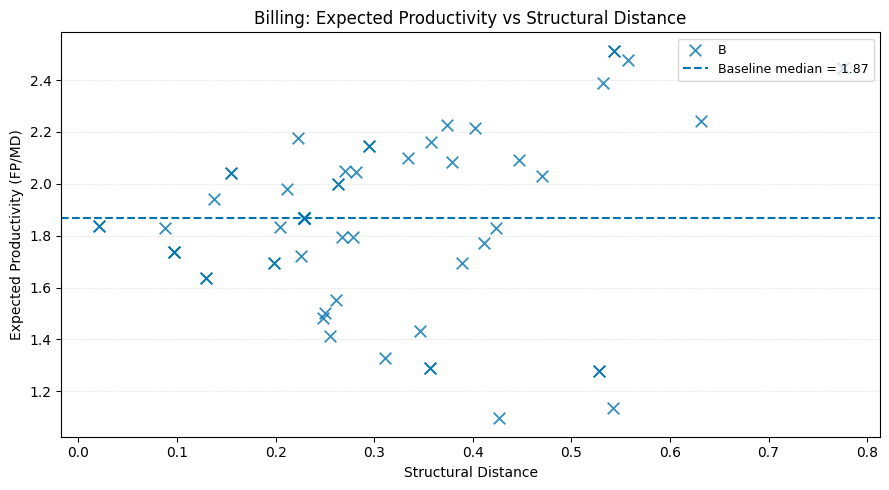

INFO | [C06] Figure saved: /content/drive/MyDrive/_MyDrive/Colab Notebooks/Functional Structural Signature Model/quality/C06_04_expected_productivity_vs_structural_distance_data_platform.png


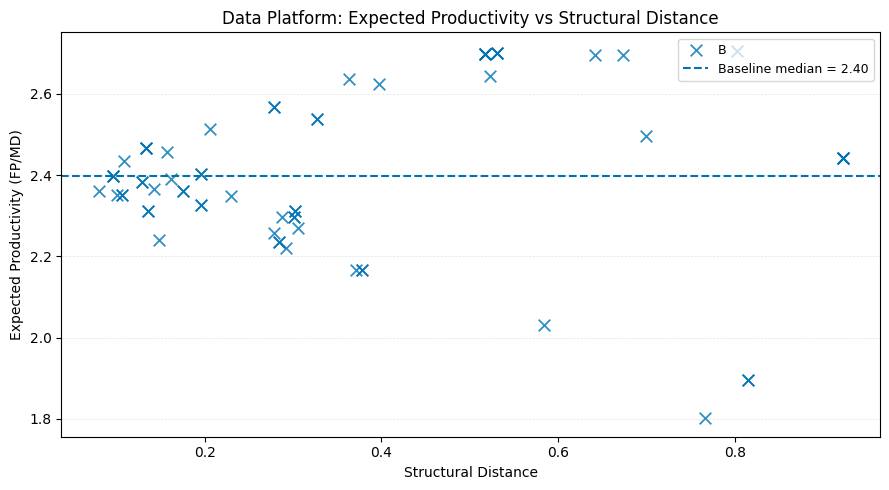

INFO | [C06] Figure saved: /content/drive/MyDrive/_MyDrive/Colab Notebooks/Functional Structural Signature Model/quality/C06_04_expected_productivity_vs_structural_distance_integration.png


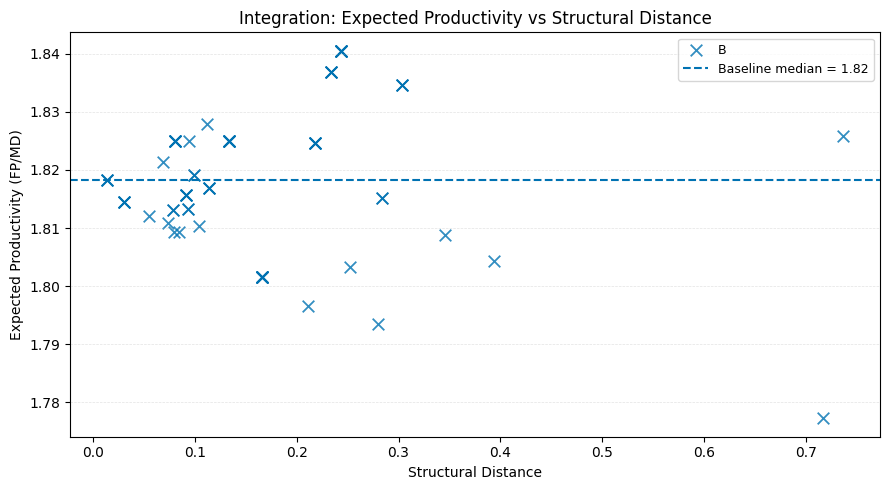

INFO | [C06] Comparison reporting and visualization completed


In [78]:
# @title
# ============================================================
# C06 — COMPARISON REPORTING AND VISUALIZATION
# ============================================================

logger.info("[C06] Starting comparison reporting and visualization")


# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

FIGURE_DPI = 200

# Optional filters (None = all values)
FILTER_DOMAIN = None
FILTER_CLUSTER = None


# ------------------------------------------------------------
# Helper functions
# ------------------------------------------------------------

def apply_filters(df):
    """Apply optional application-domain and cluster filters."""

    filtered_df = df.copy()

    if (
        FILTER_DOMAIN is not None
        and "APPLICATION_DOMAIN" in filtered_df.columns
    ):
        filtered_df = filtered_df[
            filtered_df["APPLICATION_DOMAIN"] == FILTER_DOMAIN
        ]

    if (
        FILTER_CLUSTER is not None
        and "CLUSTER" in filtered_df.columns
    ):
        filtered_df = filtered_df[
            filtered_df["CLUSTER"].astype(str)
            == str(FILTER_CLUSTER)
        ]

    return filtered_df


def export_table(df, filename):
    """Export a table to the Quality directory."""

    output_path = QUALITY_DIR / filename

    df.to_csv(
        output_path,
        index=False
    )

    logger.info(
        "[C06] Table saved: %s",
        output_path
    )


def save_figure(fig, filename):
    """Save a figure to the Quality directory."""

    output_path = QUALITY_DIR / filename

    fig.savefig(
        output_path,
        dpi=FIGURE_DPI,
        bbox_inches="tight"
    )

    logger.info(
        "[C06] Figure saved: %s",
        output_path
    )


# ------------------------------------------------------------
# Load reporting data
# ------------------------------------------------------------

with sqlite3.connect(DB_PATH) as conn:

    df_base = pd.read_sql_query(
        "SELECT * FROM TB_BASELINE",
        conn
    )

    df_profiles = pd.read_sql_query(
        "SELECT * FROM TB_BASELINE_PROFILE",
        conn
    )

    df_comparison = pd.read_sql_query(
        "SELECT * FROM TB_COMPARISON",
        conn
    )


logger.info(
    "[C06] Loaded %d projects, %d profiles and %d comparison rows",
    len(df_base),
    len(df_profiles),
    len(df_comparison)
)


# ------------------------------------------------------------
# Normalize key fields
# ------------------------------------------------------------

for column in [
    "APPLICATION_DOMAIN",
    "CLUSTER",
    "DATASET_TYPE",
]:
    if column in df_base.columns:
        df_base[column] = (
            df_base[column]
            .astype(str)
            .str.strip()
        )

for column in [
    "APPLICATION_DOMAIN",
    "CLUSTER",
]:
    if column in df_profiles.columns:
        df_profiles[column] = (
            df_profiles[column]
            .astype(str)
            .str.strip()
        )

for column in [
    "APPLICATION_DOMAIN",
    "CLUSTER",
    "GROUP_NAME",
]:
    if column in df_comparison.columns:
        df_comparison[column] = (
            df_comparison[column]
            .astype(str)
            .str.strip()
        )


df_base["DATASET_TYPE"] = (
    df_base["DATASET_TYPE"]
    .str.upper()
)


# ------------------------------------------------------------
# Apply optional filters
# ------------------------------------------------------------

df_base = apply_filters(df_base)
df_profiles = apply_filters(df_profiles)
df_comparison = apply_filters(df_comparison)

logger.info(
    "[C06] After filters: projects=%d, profiles=%d, comparison rows=%d",
    len(df_base),
    len(df_profiles),
    len(df_comparison)
)


# ============================================================
# C06.01 — APPLICATION DOMAIN SUMMARY
# ============================================================

df_domain_summary = (
    df_base
    .groupby(
        "APPLICATION_DOMAIN",
        dropna=False
    )
    .agg(
        PROJECT_COUNT=("PROJECT_CODE", "count"),
        TOTAL_EFFORT=("FP_EFFORT", "sum"),
        TOTAL_FUNCTION_POINTS=("IFPUG_FP", "sum"),
    )
    .reset_index()
    .sort_values("APPLICATION_DOMAIN")
)


export_table(
    df_domain_summary,
    "C06_01_domain_summary.csv"
)

display(df_domain_summary)


# ============================================================
# C06.02 — STRUCTURAL INDEX DISTRIBUTION BY DOMAIN
# ============================================================

df_structural_indices = (
    df_profiles[
        df_profiles["CLUSTER"] == "0"
    ][
        [
            "APPLICATION_DOMAIN",
            "CLUSTER",
            "IS_ILF",
            "IS_EIF",
            "IS_EI",
            "IS_EQ",
            "IS_EO",
        ]
    ]
    .sort_values("APPLICATION_DOMAIN")
    .copy()
)


export_table(
    df_structural_indices,
    "C06_02_structural_index_distribution.csv"
)


domains = (
    df_structural_indices["APPLICATION_DOMAIN"]
    .astype(str)
    .tolist()
)

x = np.arange(len(domains))
width = 0.15


fig, ax = plt.subplots(
    figsize=(9, 5)
)

ax.bar(
    x - 2 * width,
    df_structural_indices["IS_ILF"],
    width,
    label="IS_ILF",
    color="#E69F00"
)

ax.bar(
    x - width,
    df_structural_indices["IS_EIF"],
    width,
    label="IS_EIF",
    color="#56B4E9"
)

ax.bar(
    x,
    df_structural_indices["IS_EI"],
    width,
    label="IS_EI",
    color="#009E73"
)

ax.bar(
    x + width,
    df_structural_indices["IS_EQ"],
    width,
    label="IS_EQ",
    color="#F0E442"
)

ax.bar(
    x + 2 * width,
    df_structural_indices["IS_EO"],
    width,
    label="IS_EO",
    color="#0072B2"
)

ax.set_xticks(x)
ax.set_xticklabels(domains)

ax.set_ylabel(
    "Structural Index Share"
)

ax.set_title(
    "Structural Index Distribution by Application Domain"
)

ax.grid(False)

ax.yaxis.grid(
    True,
    linestyle="--",
    linewidth=0.5,
    alpha=0.4
)

ax.legend(
    ncol=5,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.15)
)

fig.tight_layout()

save_figure(
    fig,
    "C06_02_structural_index_distribution.png"
)

plt.show()


# ============================================================
# C06.03 — PRODUCTIVITY PROFILE COEFFICIENTS BY DOMAIN
# ============================================================

df_beta_coefficients = (
    df_profiles[
        df_profiles["CLUSTER"] == "0"
    ][
        [
            "APPLICATION_DOMAIN",
            "CLUSTER",
            "B_ILF",
            "B_EIF",
            "B_EI",
            "B_EQ",
            "B_EO",
        ]
    ]
    .sort_values("APPLICATION_DOMAIN")
    .copy()
)


export_table(
    df_beta_coefficients,
    "C06_03_productivity_profile_coefficients.csv"
)


domains = (
    df_beta_coefficients["APPLICATION_DOMAIN"]
    .astype(str)
    .tolist()
)

x = np.arange(len(domains))
width = 0.15


fig, ax = plt.subplots(
    figsize=(9, 5)
)

ax.bar(
    x - 2 * width,
    df_beta_coefficients["B_ILF"],
    width,
    label="β_ILF",
    color="#E69F00"
)

ax.bar(
    x - width,
    df_beta_coefficients["B_EIF"],
    width,
    label="β_EIF",
    color="#56B4E9"
)

ax.bar(
    x,
    df_beta_coefficients["B_EI"],
    width,
    label="β_EI",
    color="#009E73"
)

ax.bar(
    x + width,
    df_beta_coefficients["B_EQ"],
    width,
    label="β_EQ",
    color="#F0E442"
)

ax.bar(
    x + 2 * width,
    df_beta_coefficients["B_EO"],
    width,
    label="β_EO",
    color="#0072B2"
)

ax.set_xticks(x)
ax.set_xticklabels(domains)

ax.set_ylabel(
    "Beta Coefficient"
)

ax.set_title(
    "Productivity Profile Coefficients by Application Domain"
)

ax.grid(False)

ax.yaxis.grid(
    True,
    linestyle="--",
    linewidth=0.5,
    alpha=0.4
)

ax.legend(
    ncol=5,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.15)
)

fig.tight_layout()

save_figure(
    fig,
    "C06_03_productivity_profile_coefficients.png"
)

plt.show()


# ============================================================
# C06.04 — EXPECTED PRODUCTIVITY VS STRUCTURAL DISTANCE
# ============================================================

df_project_dispersion = df_base[
    [
        "PROJECT_CODE",
        "APPLICATION_DOMAIN",
        "CLUSTER",
        "DATASET_TYPE",
        "DIST_STRUTTURALE",
        "IFPUG_PROD_ATTESA_FP",
    ]
].copy()


df_project_dispersion[
    "DIST_STRUTTURALE"
] = pd.to_numeric(
    df_project_dispersion["DIST_STRUTTURALE"],
    errors="coerce"
)

df_project_dispersion[
    "IFPUG_PROD_ATTESA_FP"
] = pd.to_numeric(
    df_project_dispersion["IFPUG_PROD_ATTESA_FP"],
    errors="coerce"
)


df_project_dispersion = (
    df_project_dispersion
    .dropna(
        subset=[
            "APPLICATION_DOMAIN",
            "DATASET_TYPE",
            "DIST_STRUTTURALE",
            "IFPUG_PROD_ATTESA_FP",
        ]
    )
)


export_table(
    df_project_dispersion,
    "C06_04_expected_productivity_vs_structural_distance.csv"
)


HIGH_CONTRAST_COLORS = [
    "#D55E00",
    "#009E73",
    "#CC79A7",
    "#E69F00",
    "#56B4E9",
    "#F0E442",
    "#000000",
    "#7F7F7F",
    "#984EA3",
    "#A65628",
]

BASELINE_COLOR = "#0072B2"


domains = sorted(
    df_project_dispersion[
        "APPLICATION_DOMAIN"
    ].unique()
)


for domain in domains:

    df_domain = df_project_dispersion[
        df_project_dispersion[
            "APPLICATION_DOMAIN"
        ] == domain
    ].copy()

    if df_domain.empty:
        continue


    # --------------------------------------------------------
    # Baseline reference
    # --------------------------------------------------------

    df_baseline = df_domain[
        df_domain["DATASET_TYPE"] == "B"
    ]

    baseline_median = (
        float(
            df_baseline[
                "IFPUG_PROD_ATTESA_FP"
            ].median()
        )
        if not df_baseline.empty
        else np.nan
    )


    other_dataset_types = sorted(
        dataset_type
        for dataset_type
        in df_domain["DATASET_TYPE"].dropna().unique()
        if dataset_type != "B"
    )

    plot_dataset_types = (
        ["B"] + other_dataset_types
    )


    # --------------------------------------------------------
    # Dynamic color mapping
    # --------------------------------------------------------

    color_map = {
        "B": BASELINE_COLOR
    }

    for index, dataset_type in enumerate(
        other_dataset_types
    ):
        color_map[dataset_type] = (
            HIGH_CONTRAST_COLORS[
                index % len(HIGH_CONTRAST_COLORS)
            ]
        )


    # --------------------------------------------------------
    # Plot
    # --------------------------------------------------------

    fig, ax = plt.subplots(
        figsize=(9, 5)
    )


    for dataset_type in plot_dataset_types:

        df_dataset = df_domain[
            df_domain["DATASET_TYPE"]
            == dataset_type
        ]

        if df_dataset.empty:
            continue

        ax.scatter(
            df_dataset["DIST_STRUTTURALE"],
            df_dataset["IFPUG_PROD_ATTESA_FP"],
            label=dataset_type,
            alpha=0.80,
            marker="x",
            s=70 if dataset_type == "B" else 60,
            c=color_map[dataset_type],
            linewidths=(
                1.3
                if dataset_type == "B"
                else 1.0
            )
        )


    if not np.isnan(baseline_median):

        ax.axhline(
            baseline_median,
            linestyle="--",
            linewidth=1.5,
            color=BASELINE_COLOR,
            label=(
                f"Baseline median = "
                f"{baseline_median:.2f}"
            )
        )


    ax.set_title(
        f"{domain}: Expected Productivity vs Structural Distance"
    )

    ax.set_xlabel(
        "Structural Distance"
    )

    ax.set_ylabel(
        "Expected Productivity (FP/MD)"
    )

    ax.grid(False)

    ax.yaxis.grid(
        True,
        linestyle="--",
        linewidth=0.5,
        alpha=0.35
    )

    ax.legend(
        loc="upper right",
        fontsize=9
    )

    fig.tight_layout()


    safe_domain = (
        str(domain)
        .strip()
        .lower()
        .replace(" ", "_")
        .replace("/", "_")
    )


    save_figure(
        fig,
        (
            "C06_04_expected_productivity_"
            f"vs_structural_distance_{safe_domain}.png"
        )
    )

    plt.show()


logger.info(
    "[C06] Comparison reporting and visualization completed"
)

# C07 — Database Export to CSV

This final Core step exports the processed database tables to CSV files.

The export provides a portable representation of the final pipeline results,
including project-level metrics, baseline structural profiles, and aggregated
comparison results.

All CSV files are stored in the `Quality` directory using the `C07_xx`
naming convention.

This step is read-only with respect to the project database.

In [79]:
# @title
# ============================================================
# C07 — DATABASE EXPORT TO CSV
# ============================================================

logger.info("[C07] Starting database export to CSV")


# ------------------------------------------------------------
# Export configuration
# ------------------------------------------------------------

EXPORT_TABLES = {
    "TB_BASELINE": "TB_BASELINE_export.csv",
    "TB_BASELINE_PROFILE": "TB_BASELINE_PROFILE_export.csv",
    "TB_COMPARISON": "TB_COMPARISON_export.csv",
}


# ------------------------------------------------------------
# Export database tables
# ------------------------------------------------------------

with sqlite3.connect(DB_PATH) as conn:

    for table_name, output_filename in EXPORT_TABLES.items():

        df_export = pd.read_sql_query(
            f"SELECT * FROM {table_name}",
            conn
        )

        output_path = (
            OUTPUT_DIR
            / output_filename
        )

        df_export.to_csv(
            output_path,
            index=False,
            encoding="utf-8"
        )

        logger.info(
            "[C07] Exported %s: %d rows -> %s",
            table_name,
            len(df_export),
            output_path
        )


logger.info(
    "[C07] Database export completed"
)

INFO | [C07] Starting database export to CSV
INFO | [C07] Exported TB_BASELINE: 207 rows -> /content/drive/MyDrive/_MyDrive/Colab Notebooks/Functional Structural Signature Model/output/TB_BASELINE_export.csv
INFO | [C07] Exported TB_BASELINE_PROFILE: 3 rows -> /content/drive/MyDrive/_MyDrive/Colab Notebooks/Functional Structural Signature Model/output/TB_BASELINE_PROFILE_export.csv
INFO | [C07] Exported TB_COMPARISON: 3 rows -> /content/drive/MyDrive/_MyDrive/Colab Notebooks/Functional Structural Signature Model/output/TB_COMPARISON_export.csv
INFO | [C07] Database export completed


# U01 — Synthetic Test Dataset Generation

This utility generates controlled synthetic datasets used to evaluate the
Functional Structural Signature Model under progressively more challenging
conditions.

Three independent scenarios are produced:

1. **Standard Dataset** — an in-distribution dataset representing nominal
   projects consistent with the expected structural signature.

2. **Mismatch Dataset** — a cross-domain structural inversion scenario designed
   to simulate projects whose functional perimeter is inconsistent with their
   declared application domain.

3. **Extreme Dataset** — a pathological perturbation scenario designed to test
   model robustness under severe structural anomalies and boundary conditions.

Each scenario is generated independently and exported as a separate CSV file.
The generated datasets are intended exclusively for model verification and
stress testing and are not part of the Core pipeline.


INFO | [U01.1] Starting Standard dataset generation
INFO | [U01.1] Dataset accepted on attempt 1 with seed 42
INFO | [U01.1] Standard dataset saved: /content/drive/MyDrive/_MyDrive/Colab Notebooks/Functional Structural Signature Model/quality/U01_01_standard_dataset.csv
INFO | [U01.1] Generated projects: 50
INFO | [U01.1] Effective productivity min/mean/max: 1.903 / 1.994 / 2.087
INFO | [U01.1] Target productivity range: 1.900 - 2.100
INFO | [U01.1] Estimated Beta coefficients: {'ILF': 1.7833, 'EIF': 1.3377, 'EI': 2.2183, 'EQ': 2.0623, 'EO': 2.5065}
INFO | [U01.1] Condition number: 7.46e+02 | R2: 0.109
INFO | [U01.1] Mean structural signature: {'ILF': 0.199, 'EIF': 0.178, 'EI': 0.173, 'EQ': 0.251, 'EO': 0.199}
INFO | [U01.1] Structural signature figure saved: /content/drive/MyDrive/_MyDrive/Colab Notebooks/Functional Structural Signature Model/quality/U01_01_standard_dataset.png


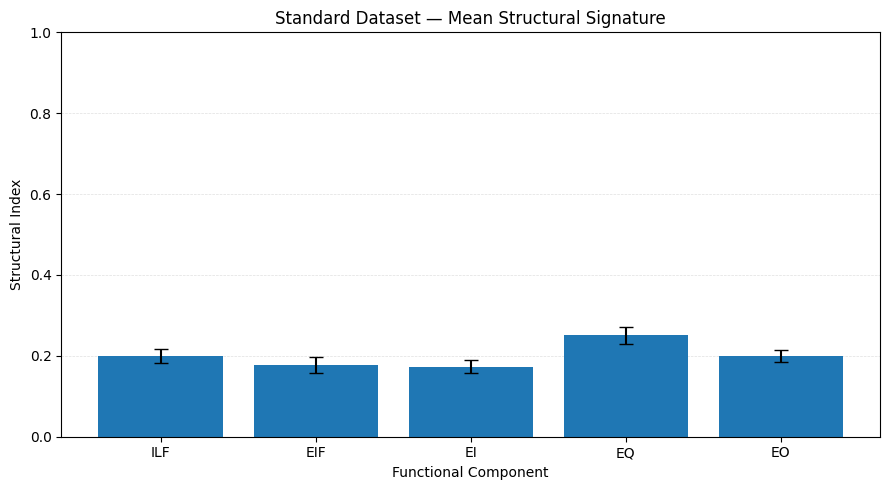

INFO | [U01.1] Standard dataset generation completed


In [54]:
# @title
# ============================================================
# STANDARD DATASET GENERATOR
# ============================================================
#
# Generates a structurally coherent synthetic baseline.
#
# The generation algorithm, constraints, acceptance criteria,
# and numerical thresholds are intentionally unchanged from
# the original experimental implementation.
# ============================================================

logger.info("[U01.1] Starting Standard dataset generation")


# ------------------------------------------------------------
# Scenario configuration
# ------------------------------------------------------------

DOMAIN = "Standard"
N_PROJECTS = 50

# Target productivity (FP/MD) and absolute variability
P = 2.0
VAR_P = 0.1

# Target structural signature: ILF, EIF, EI, EQ, EO
IS_TARGET = np.array(
    [0.20, 0.18, 0.17, 0.25, 0.20],
    dtype=float
)

# Structural variability
IS_VAR = 0.02

# Component-specific variability weights
IS_VAR_WEIGHTS = np.array(
    [1.0, 1.0, 1.0, 1.0, 1.0],
    dtype=float
)

# Global structural-index guardrails
IS_MIN = 0.05
IS_MAX = 0.45

# Project-size distribution
FP_TARGET_MEAN = 400
FP_TARGET_SPREAD = 120

# Hard FP boundaries
FP_MIN = 150
FP_MAX = 1200

# Initial random seed
SEED = 42

# Output
OUTPUT_CSV = QUALITY_DIR / "U01_01_standard_dataset.csv"
OUTPUT_FIGURE = QUALITY_DIR / "U01_01_standard_dataset.png"


# ------------------------------------------------------------
# IFPUG constants
# ------------------------------------------------------------

COMP_LABELS = [
    "ILF",
    "EIF",
    "EI",
    "EQ",
    "EO",
]

COMP_NAMES = [
    "IFPUG_ILF",
    "IFPUG_EIF",
    "IFPUG_EI",
    "IFPUG_EQ",
    "IFPUG_EO",
]

# Average IFPUG FP weights
WEIGHTS_FP = np.array(
    [10, 7, 4, 4, 5],
    dtype=float
)


# ------------------------------------------------------------
# Acceptance criteria
# ------------------------------------------------------------

MAX_TRIES = 50
BETA_NEG_MAX = 0
COND_MAX = 1e5
MIN_STD_IS = 0.010
MIN_R2 = 0.10


# ------------------------------------------------------------
# Generation functions
# ------------------------------------------------------------

def sample_prod(rng, productivity, variability):
    """
    Sample productivity within the configured interval.
    """

    lower_bound = max(
        productivity - variability,
        0.05
    )

    upper_bound = (
        productivity + variability
    )

    return float(
        rng.uniform(
            lower_bound,
            upper_bound
        )
    )


def sample_is_vector(
    rng,
    is_target,
    is_var,
    is_var_weights,
    is_min,
    is_max,
    max_tries=300
):
    """
    Generate a normalized structural-index vector around the
    target signature using component-specific Gaussian noise.

    The generated vector must satisfy the configured global
    minimum and maximum structural-index constraints.
    """

    is_target = np.array(
        is_target,
        dtype=float
    )

    is_target = (
        is_target
        / is_target.sum()
    )

    weights = np.array(
        is_var_weights,
        dtype=float
    )

    weights = np.clip(
        weights,
        0.0,
        None
    )

    for _ in range(max_tries):

        noise = rng.normal(
            0.0,
            is_var * weights,
            size=5
        )

        vector = (
            is_target + noise
        )

        vector = np.clip(
            vector,
            1e-6,
            None
        )

        vector = (
            vector
            / vector.sum()
        )

        if (
            vector.min() >= is_min
            and vector.max() <= is_max
        ):
            return vector

    raise ValueError(
        "Unable to generate a structural-index vector "
        "with the configured constraints. Reduce IS_VAR "
        "or relax IS_MIN / IS_MAX."
    )


def is_to_counts(
    is_vector,
    fp_target,
    weights_fp
):
    """
    Convert a structural-index vector into integer functional
    component counts while keeping total FP close to the
    requested target.
    """

    fp_by_component = (
        is_vector * fp_target
    )

    counts = np.round(
        fp_by_component / weights_fp
    ).astype(int)

    counts = np.clip(
        counts,
        1,
        None
    )

    fp_total = int(
        np.dot(
            counts,
            weights_fp
        )
    )

    return counts, fp_total


# ------------------------------------------------------------
# Beta estimation
# ------------------------------------------------------------

def estimate_beta_no_intercept(X, y):
    """
    Estimate OLS coefficients without intercept.
    """

    XtX = X.T @ X
    Xty = X.T @ y

    beta = np.linalg.solve(
        XtX,
        Xty
    )

    return beta, XtX


def r2_score(y, y_hat):
    """
    Calculate the standard R-squared statistic.
    """

    ss_res = np.sum(
        (y - y_hat) ** 2
    )

    ss_tot = np.sum(
        (y - y.mean()) ** 2
    )

    return (
        1.0 - ss_res / ss_tot
        if ss_tot > 0
        else -np.inf
    )


def acceptance_test(df):
    """
    Validate the generated dataset against the original
    structural and statistical acceptance criteria.
    """

    counts_matrix = (
        df[COMP_NAMES]
        .to_numpy(float)
    )

    fp_by_component = (
        counts_matrix
        * WEIGHTS_FP
    )

    X = (
        fp_by_component
        / fp_by_component.sum(
            axis=1,
            keepdims=True
        )
    )

    y = (
        df["IFPUG_FP"].to_numpy(float)
        / df["FP_EFFORT"].to_numpy(float)
    )


    # Minimum structural variability
    structural_std = X.std(
        axis=0
    )

    if np.any(
        structural_std < MIN_STD_IS
    ):
        return False, {
            "reason": "IS_STDEV_TOO_LOW",
            "is_std": structural_std,
        }


    # Beta estimation
    try:
        beta, XtX = (
            estimate_beta_no_intercept(
                X,
                y
            )
        )

    except np.linalg.LinAlgError:
        return False, {
            "reason": "SINGULAR_XTX"
        }


    # Numerical stability
    condition_number = (
        np.linalg.cond(XtX)
    )

    if (
        not np.isfinite(condition_number)
        or condition_number > COND_MAX
    ):
        return False, {
            "reason": "COND_TOO_HIGH",
            "cond": condition_number,
        }


    # Negative Beta coefficients
    negative_beta_count = int(
        (beta < 0).sum()
    )

    if (
        negative_beta_count
        > BETA_NEG_MAX
    ):
        return False, {
            "reason": "TOO_MANY_NEG_BETA",
            "neg_count": negative_beta_count,
            "beta": beta,
        }


    # Minimum R-squared
    y_hat = X @ beta

    r2 = r2_score(
        y,
        y_hat
    )

    if r2 < MIN_R2:
        return False, {
            "reason": "R2_TOO_LOW",
            "r2": r2,
            "beta": beta,
        }


    return True, {
        "beta": beta,
        "cond": condition_number,
        "r2": r2,
        "is_std": structural_std,
    }


# ------------------------------------------------------------
# Dataset generation and acceptance loop
# ------------------------------------------------------------

accepted = False
seed_try = SEED
last_info = None


for attempt in range(
    1,
    MAX_TRIES + 1
):

    rng = np.random.default_rng(
        seed_try
    )

    rows = []


    for project_index in range(
        1,
        N_PROJECTS + 1
    ):

        structural_vector = (
            sample_is_vector(
                rng,
                IS_TARGET,
                IS_VAR,
                IS_VAR_WEIGHTS,
                IS_MIN,
                IS_MAX
            )
        )


        fp_target = int(
            np.clip(
                rng.normal(
                    FP_TARGET_MEAN,
                    FP_TARGET_SPREAD
                ),
                FP_MIN,
                FP_MAX
            )
        )


        counts, fp_total = (
            is_to_counts(
                structural_vector,
                fp_target,
                WEIGHTS_FP
            )
        )


        productivity = sample_prod(
            rng,
            P,
            VAR_P
        )


        effort = (
            fp_total
            / productivity
        )


        rows.append(
            {
                "PROJECT_CODE":
                    f"{DOMAIN.replace(' ', '_')[:2].upper()}_{project_index:02d}",

                "APPLICATION_DOMAIN":
                    DOMAIN,

                "FP_EFFORT":
                    round(
                        float(effort),
                        2
                    ),

                "IFPUG_FP":
                    int(fp_total),

                "IFPUG_ILF":
                    int(counts[0]),

                "IFPUG_EIF":
                    int(counts[1]),

                "IFPUG_EI":
                    int(counts[2]),

                "IFPUG_EQ":
                    int(counts[3]),

                "IFPUG_EO":
                    int(counts[4]),
            }
        )


    df_standard = pd.DataFrame(
        rows
    )


    accepted, last_info = (
        acceptance_test(
            df_standard
        )
    )


    if accepted:

        SEED_ACCEPTED = seed_try

        logger.info(
            "[U01.1] Dataset accepted on attempt %d with seed %d",
            attempt,
            SEED_ACCEPTED
        )

        break


    seed_try += 1


if not accepted:

    raise RuntimeError(
        f"Standard dataset not accepted after "
        f"{MAX_TRIES} attempts. "
        f"Last rejection reason: {last_info}"
    )


# ------------------------------------------------------------
# Export generated dataset
# ------------------------------------------------------------

df_standard.to_csv(
    OUTPUT_CSV,
    sep=";",
    index=False,
    encoding="utf-8",
    decimal=","
)

logger.info(
    "[U01.1] Standard dataset saved: %s",
    OUTPUT_CSV
)

logger.info(
    "[U01.1] Generated projects: %d",
    len(df_standard)
)


# ------------------------------------------------------------
# Generation diagnostics
# ------------------------------------------------------------

effective_productivity = (
    df_standard["IFPUG_FP"]
    / df_standard["FP_EFFORT"]
)

beta = last_info["beta"]


logger.info(
    "[U01.1] Effective productivity min/mean/max: %.3f / %.3f / %.3f",
    effective_productivity.min(),
    effective_productivity.mean(),
    effective_productivity.max()
)

logger.info(
    "[U01.1] Target productivity range: %.3f - %.3f",
    max(P - VAR_P, 0.05),
    P + VAR_P
)

logger.info(
    "[U01.1] Estimated Beta coefficients: %s",
    {
        component: round(float(value), 4)
        for component, value
        in zip(COMP_LABELS, beta)
    }
)

logger.info(
    "[U01.1] Condition number: %.2e | R2: %.3f",
    last_info["cond"],
    last_info["r2"]
)


# ------------------------------------------------------------
# Reconstruct structural signature
# ------------------------------------------------------------

counts_matrix = (
    df_standard[COMP_NAMES]
    .to_numpy(float)
)

fp_by_component = (
    counts_matrix
    * WEIGHTS_FP
)

structural_matrix = (
    fp_by_component
    / fp_by_component.sum(
        axis=1,
        keepdims=True
    )
)

structural_mean = (
    structural_matrix.mean(
        axis=0
    )
)

structural_std = (
    structural_matrix.std(
        axis=0
    )
)


logger.info(
    "[U01.1] Mean structural signature: %s",
    {
        component: round(float(value), 3)
        for component, value
        in zip(
            COMP_LABELS,
            structural_mean
        )
    }
)


# ------------------------------------------------------------
# Standardized structural-signature chart
# ------------------------------------------------------------
#
# IMPORTANT:
# The same chart structure, component order, axis scale,
# and dimensions must also be used for U01.2 and U01.3
# to guarantee direct visual comparability.
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(9, 5)
)

x = np.arange(
    len(COMP_LABELS)
)

ax.bar(
    x,
    structural_mean,
    yerr=structural_std,
    capsize=5
)

ax.set_xticks(x)

ax.set_xticklabels(
    COMP_LABELS
)

ax.set_ylim(
    0,
    1
)

ax.set_xlabel(
    "Functional Component"
)

ax.set_ylabel(
    "Structural Index"
)

ax.set_title(
    "Standard Dataset — Mean Structural Signature"
)

ax.yaxis.grid(
    True,
    linestyle="--",
    linewidth=0.5,
    alpha=0.4
)

ax.set_axisbelow(True)

fig.tight_layout()


# Save before display
fig.savefig(
    OUTPUT_FIGURE,
    dpi=200,
    bbox_inches="tight"
)

logger.info(
    "[U01.1] Structural signature figure saved: %s",
    OUTPUT_FIGURE
)

plt.show()


logger.info(
    "[U01.1] Standard dataset generation completed"
)

INFO | [U01.2] Starting Mismatch IS vs Beta dataset generation
WARNING | [U01.2] No dataset satisfied the configured Beta anomaly criteria after 80 attempts. The final generated dataset is retained and classified as WEAK_MIS.
INFO | [U01.2] Mismatch IS vs Beta dataset saved: /content/drive/MyDrive/_MyDrive/Colab Notebooks/Functional Structural Signature Model/quality/U01_02_mismatch_is_beta_dataset.csv
INFO | [U01.2] Generated projects: 80
INFO | [U01.2] Scenario classification: WEAK_MIS
INFO | [U01.2] Final attempt: 80 | seed: 121
INFO | [U01.2] Effective productivity min/mean/max: 1.902 / 1.999 / 2.093
INFO | [U01.2] Target productivity range: 1.900 - 2.100
INFO | [U01.2] Estimated Beta coefficients: {'ILF': 1.6972, 'EIF': 2.1316, 'EI': 1.8174, 'EQ': 2.205, 'EO': 2.0781}
INFO | [U01.2] Negative Beta coefficients: 0
INFO | [U01.2] Maximum absolute Beta: 2.2050
INFO | [U01.2] Condition number: 2.25e+02
INFO | [U01.2] Structural-index standard deviations: {'ILF': 0.0328, 'EIF': 0.0296, 

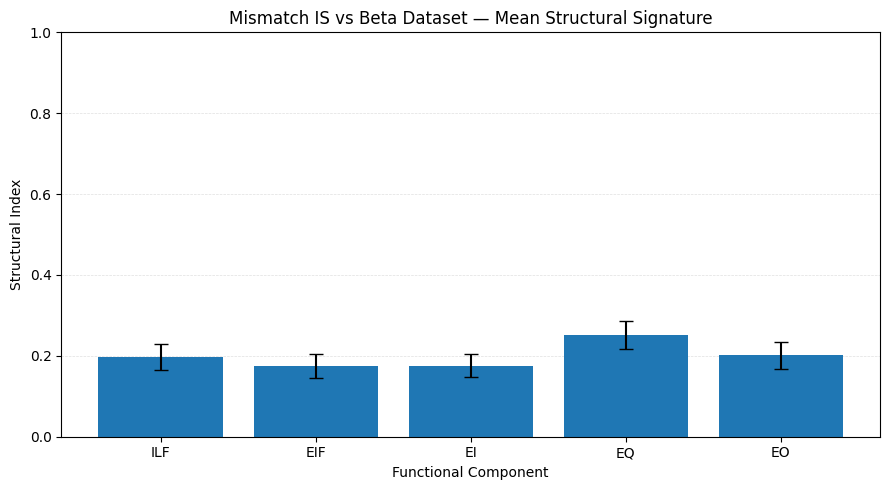

INFO | [U01.2] Beta anomaly criteria | negative >= 2 OR cond >= 2.00e+04 OR max|Beta| >= 4.00
INFO | [U01.2] Observed anomaly metrics | negative=0 | cond=2.25e+02 | max|Beta|=2.2050
INFO | [U01.2] Mismatch IS vs Beta dataset generation completed


In [55]:
# @title

# ============================================================
# U01.2 — MISMATCH IS vs BETA DATASET GENERATOR
# ============================================================
#
# Generates a structurally coherent synthetic dataset in which
# observed productivity is intentionally independent from the
# structural signature.
#
# The purpose is to create a controlled mismatch scenario where
# apparently coherent IS distributions may lead to anomalous or
# unstable Beta coefficients.
#
# The generation algorithm, constraints, anomaly criteria,
# thresholds, and fallback behavior are intentionally preserved
# from the original experimental implementation.
# ============================================================

logger.info("[U01.2] Starting Mismatch IS vs Beta dataset generation")


# ------------------------------------------------------------
# Scenario configuration
# ------------------------------------------------------------

DOMAIN = "Mismatch_IS_Beta"
N_PROJECTS = 80

# Target productivity (FP/MD) and absolute variability
P = 2.0
VAR_P = 0.10

# Target structural signature: ILF, EIF, EI, EQ, EO
#
# IMPORTANT:
# This target should preferably be aligned with the mean
# structural signature observed in the real baseline.
IS_TARGET = np.array(
    [0.20, 0.18, 0.17, 0.25, 0.20],
    dtype=float
)

# Dirichlet concentration:
# higher values -> tighter structural cluster
# lower values  -> greater structural dispersion
DIRICHLET_CONC = 180

# Global structural-index guardrails
IS_MIN = 0.03
IS_MAX = 0.50

# Project-size distribution
FP_TARGET_MEAN = 400
FP_TARGET_SPREAD = 150

# Hard FP boundaries
FP_MIN = 150
FP_MAX = 1200

# Initial random seed
SEED = 42

# Output
OUTPUT_CSV = QUALITY_DIR / "U01_02_mismatch_is_beta_dataset.csv"
OUTPUT_FIGURE = QUALITY_DIR / "U01_02_mismatch_is_beta_dataset.png"


# ------------------------------------------------------------
# IFPUG constants
# ------------------------------------------------------------

COMP_LABELS = [
    "ILF",
    "EIF",
    "EI",
    "EQ",
    "EO",
]

COMP_NAMES = [
    "IFPUG_ILF",
    "IFPUG_EIF",
    "IFPUG_EI",
    "IFPUG_EQ",
    "IFPUG_EO",
]

# Average IFPUG FP weights
WEIGHTS_FP = np.array(
    [10, 7, 4, 4, 5],
    dtype=float
)


# ------------------------------------------------------------
# Productivity mode
# ------------------------------------------------------------
#
# RANDOM is intentional.
#
# Productivity is sampled independently from the structural
# signature. This independence is the core mechanism producing
# the IS/Beta mismatch.
# ------------------------------------------------------------

Y_MODE = "RANDOM"


# ------------------------------------------------------------
# Beta anomaly criteria
# ------------------------------------------------------------

MAX_TRIES = 80

# Dataset considered anomalous if at least one condition holds
MIN_NEG_BETA = 2
MIN_COND = 2e4
MIN_MAX_ABS_BETA = 4.0


# ------------------------------------------------------------
# Structural-vector generation
# ------------------------------------------------------------

def sample_is_vector_dirichlet(
    rng,
    is_target,
    concentration,
    is_min,
    is_max,
    max_tries=2000
):
    """
    Generate a normalized structural-index vector using a
    Dirichlet distribution centered around the configured
    target structural signature.

    The resulting vector must satisfy the configured minimum
    and maximum structural-index constraints.
    """

    is_target = np.array(
        is_target,
        dtype=float
    )

    is_target = (
        is_target
        / is_target.sum()
    )

    alpha = np.clip(
        is_target * concentration,
        1e-3,
        None
    )

    for _ in range(max_tries):

        vector = rng.dirichlet(
            alpha
        )

        if (
            vector.min() >= is_min
            and vector.max() <= is_max
        ):
            return vector

    raise RuntimeError(
        "Unable to generate a structural-index vector with "
        "the configured Dirichlet constraints. Reduce "
        "DIRICHLET_CONC or relax IS_MIN / IS_MAX."
    )


# ------------------------------------------------------------
# Structural signature -> IFPUG component counts
# ------------------------------------------------------------

def is_to_counts_soft(
    rng,
    is_vector,
    fp_target,
    weights_fp
):
    """
    Convert a structural-index vector into integer IFPUG
    component counts.

    Small Gaussian noise is intentionally introduced before
    flooring the component counts in order to avoid an
    unrealistically deterministic transformation.
    """

    fp_by_component = (
        is_vector
        * fp_target
    )

    noisy_counts = (
        fp_by_component
        / weights_fp
        + rng.normal(
            0.0,
            0.35,
            size=len(weights_fp)
        )
    )

    counts = np.floor(
        np.clip(
            noisy_counts,
            1,
            None
        )
    ).astype(int)

    fp_total = int(
        np.dot(
            counts,
            weights_fp
        )
    )

    return counts, fp_total


# ------------------------------------------------------------
# Beta estimation
# ------------------------------------------------------------

def estimate_beta_no_intercept(
    X,
    y
):
    """
    Estimate OLS Beta coefficients without intercept.
    """

    XtX = (
        X.T
        @ X
    )

    Xty = (
        X.T
        @ y
    )

    beta = np.linalg.solve(
        XtX,
        Xty
    )

    return beta, XtX


# ------------------------------------------------------------
# Dataset generation
# ------------------------------------------------------------

def build_dataset(
    seed_value
):
    """
    Generate one complete mismatch dataset and calculate its
    structural and regression diagnostics.
    """

    rng = np.random.default_rng(
        seed_value
    )

    rows = []


    for project_index in range(
        1,
        N_PROJECTS + 1
    ):

        # ----------------------------------------------------
        # Generate coherent structural signature
        # ----------------------------------------------------

        structural_vector = (
            sample_is_vector_dirichlet(
                rng,
                IS_TARGET,
                DIRICHLET_CONC,
                IS_MIN,
                IS_MAX
            )
        )


        # ----------------------------------------------------
        # Generate target project size
        # ----------------------------------------------------

        fp_target = int(
            np.clip(
                rng.normal(
                    FP_TARGET_MEAN,
                    FP_TARGET_SPREAD
                ),
                FP_MIN,
                FP_MAX
            )
        )


        # ----------------------------------------------------
        # Convert structural signature to IFPUG counts
        # ----------------------------------------------------

        counts, fp_total = (
            is_to_counts_soft(
                rng,
                structural_vector,
                fp_target,
                WEIGHTS_FP
            )
        )


        # ----------------------------------------------------
        # Reconstruct actual structural signature
        #
        # This intentionally mirrors the real analysis
        # pipeline: IS is reconstructed from integer IFPUG
        # component counts rather than using the original
        # Dirichlet vector directly.
        # ----------------------------------------------------

        fp_by_component = (
            counts
            * WEIGHTS_FP
        )

        reconstructed_is = (
            fp_by_component
            / fp_by_component.sum()
        )


        # ----------------------------------------------------
        # Generate observed productivity
        #
        # RANDOM productivity is intentionally independent
        # from reconstructed IS.
        # ----------------------------------------------------

        productivity = float(
            rng.uniform(
                P - VAR_P,
                P + VAR_P
            )
        )

        effort = (
            fp_total
            / productivity
        )


        # ----------------------------------------------------
        # Store project
        # ----------------------------------------------------

        rows.append(
            {
                "PROJECT_CODE":
                    f"{DOMAIN.replace(' ', '_')[:2].upper()}_{project_index:02d}",

                "APPLICATION_DOMAIN":
                    DOMAIN,

                "FP_EFFORT":
                    round(
                        float(effort),
                        2
                    ),

                "IFPUG_FP":
                    int(fp_total),

                "IFPUG_ILF":
                    int(counts[0]),

                "IFPUG_EIF":
                    int(counts[1]),

                "IFPUG_EI":
                    int(counts[2]),

                "IFPUG_EQ":
                    int(counts[3]),

                "IFPUG_EO":
                    int(counts[4]),
            }
        )


    df = pd.DataFrame(
        rows
    )


    # --------------------------------------------------------
    # Reconstruct analysis matrix X
    # --------------------------------------------------------

    counts_matrix = (
        df[COMP_NAMES]
        .to_numpy(float)
    )

    fp_by_component = (
        counts_matrix
        * WEIGHTS_FP
    )

    X = (
        fp_by_component
        / fp_by_component.sum(
            axis=1,
            keepdims=True
        )
    )


    # --------------------------------------------------------
    # Effective productivity vector y
    # --------------------------------------------------------

    y = (
        df["IFPUG_FP"].to_numpy(float)
        / df["FP_EFFORT"].to_numpy(float)
    )


    # --------------------------------------------------------
    # Estimate Beta
    # --------------------------------------------------------

    beta, XtX = (
        estimate_beta_no_intercept(
            X,
            y
        )
    )


    # --------------------------------------------------------
    # Diagnostics
    # --------------------------------------------------------

    condition_number = float(
        np.linalg.cond(
            XtX
        )
    )

    negative_beta_count = int(
        (beta < 0).sum()
    )

    max_abs_beta = float(
        np.max(
            np.abs(beta)
        )
    )

    structural_std = (
        X.std(
            axis=0
        )
    )

    structural_mean = (
        X.mean(
            axis=0
        )
    )


    info = {
        "beta":
            beta,

        "cond":
            condition_number,

        "neg_count":
            negative_beta_count,

        "max_abs_beta":
            max_abs_beta,

        "is_std":
            structural_std,

        "is_mean":
            structural_mean,
    }

    return df, info


# ------------------------------------------------------------
# Mismatch anomaly test
# ------------------------------------------------------------

def is_beta_strange(
    info
):
    """
    Determine whether the generated dataset exhibits the
    intended anomalous Beta behavior.

    IMPORTANT:
    The logical OR between the three anomaly conditions is
    intentionally preserved from the original implementation.
    """

    return (
        info["neg_count"] >= MIN_NEG_BETA
        or info["cond"] >= MIN_COND
        or info["max_abs_beta"] >= MIN_MAX_ABS_BETA
    )


# ------------------------------------------------------------
# Dataset-generation and acceptance loop
# ------------------------------------------------------------

accepted = False
seed_try = SEED

df_final = None
info_final = None
SEED_ACCEPTED = None
ATTEMPT_ACCEPTED = None


for attempt in range(
    1,
    MAX_TRIES + 1
):

    df_try, info_try = (
        build_dataset(
            seed_try
        )
    )


    # Always retain the latest generated dataset.
    #
    # This is required to preserve the original fallback
    # behavior when no strong mismatch dataset is found.
    df_final = df_try
    info_final = info_try

    SEED_ACCEPTED = seed_try
    ATTEMPT_ACCEPTED = attempt


    if is_beta_strange(
        info_try
    ):

        accepted = True

        logger.info(
            "[U01.2] Strong mismatch dataset accepted "
            "on attempt %d with seed %d",
            attempt,
            seed_try
        )

        break


    seed_try += 1


# ------------------------------------------------------------
# Scenario classification
# ------------------------------------------------------------

if accepted:

    MISMATCH_CLASS = "STRONG_MIS"

    logger.info(
        "[U01.2] Dataset classified as STRONG_MIS"
    )

else:

    MISMATCH_CLASS = "WEAK_MIS"

    logger.warning(
        "[U01.2] No dataset satisfied the configured Beta "
        "anomaly criteria after %d attempts. "
        "The final generated dataset is retained and "
        "classified as WEAK_MIS.",
        MAX_TRIES
    )


# ------------------------------------------------------------
# Export generated dataset
# ------------------------------------------------------------

df_final.to_csv(
    OUTPUT_CSV,
    sep=";",
    index=False,
    encoding="utf-8",
    decimal=","
)

logger.info(
    "[U01.2] Mismatch IS vs Beta dataset saved: %s",
    OUTPUT_CSV
)

logger.info(
    "[U01.2] Generated projects: %d",
    len(df_final)
)


# ------------------------------------------------------------
# Generation diagnostics
# ------------------------------------------------------------

effective_productivity = (
    df_final["IFPUG_FP"]
    / df_final["FP_EFFORT"]
)

beta = (
    info_final["beta"]
)


logger.info(
    "[U01.2] Scenario classification: %s",
    MISMATCH_CLASS
)

logger.info(
    "[U01.2] Final attempt: %d | seed: %d",
    ATTEMPT_ACCEPTED,
    SEED_ACCEPTED
)

logger.info(
    "[U01.2] Effective productivity min/mean/max: "
    "%.3f / %.3f / %.3f",
    effective_productivity.min(),
    effective_productivity.mean(),
    effective_productivity.max()
)

logger.info(
    "[U01.2] Target productivity range: %.3f - %.3f",
    P - VAR_P,
    P + VAR_P
)

logger.info(
    "[U01.2] Estimated Beta coefficients: %s",
    {
        component: round(
            float(value),
            4
        )
        for component, value
        in zip(
            COMP_LABELS,
            beta
        )
    }
)

logger.info(
    "[U01.2] Negative Beta coefficients: %d",
    info_final["neg_count"]
)

logger.info(
    "[U01.2] Maximum absolute Beta: %.4f",
    info_final["max_abs_beta"]
)

logger.info(
    "[U01.2] Condition number: %.2e",
    info_final["cond"]
)

logger.info(
    "[U01.2] Structural-index standard deviations: %s",
    {
        component: round(
            float(value),
            4
        )
        for component, value
        in zip(
            COMP_LABELS,
            info_final["is_std"]
        )
    }
)


# ------------------------------------------------------------
# Reconstruct structural signature
# ------------------------------------------------------------

counts_matrix = (
    df_final[COMP_NAMES]
    .to_numpy(float)
)

fp_by_component = (
    counts_matrix
    * WEIGHTS_FP
)

structural_matrix = (
    fp_by_component
    / fp_by_component.sum(
        axis=1,
        keepdims=True
    )
)

structural_mean = (
    structural_matrix.mean(
        axis=0
    )
)

structural_std = (
    structural_matrix.std(
        axis=0
    )
)


logger.info(
    "[U01.2] Mean structural signature: %s",
    {
        component: round(
            float(value),
            3
        )
        for component, value
        in zip(
            COMP_LABELS,
            structural_mean
        )
    }
)


# ------------------------------------------------------------
# Standardized structural-signature chart
# ------------------------------------------------------------
#
# IMPORTANT:
# Chart structure, component order, axis scale and dimensions
# intentionally match U01.1 to guarantee direct visual
# comparison between Standard and Mismatch datasets.
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(9, 5)
)

x = np.arange(
    len(COMP_LABELS)
)

ax.bar(
    x,
    structural_mean,
    yerr=structural_std,
    capsize=5
)

ax.set_xticks(
    x
)

ax.set_xticklabels(
    COMP_LABELS
)

ax.set_ylim(
    0,
    1
)

ax.set_xlabel(
    "Functional Component"
)

ax.set_ylabel(
    "Structural Index"
)

ax.set_title(
    "Mismatch IS vs Beta Dataset — Mean Structural Signature"
)

ax.yaxis.grid(
    True,
    linestyle="--",
    linewidth=0.5,
    alpha=0.4
)

ax.set_axisbelow(
    True
)

fig.tight_layout()


# Save before display
fig.savefig(
    OUTPUT_FIGURE,
    dpi=200,
    bbox_inches="tight"
)

logger.info(
    "[U01.2] Structural signature figure saved: %s",
    OUTPUT_FIGURE
)

plt.show()


# ------------------------------------------------------------
# Final anomaly summary
# ------------------------------------------------------------

logger.info(
    "[U01.2] Beta anomaly criteria | "
    "negative >= %d OR cond >= %.2e OR max|Beta| >= %.2f",
    MIN_NEG_BETA,
    MIN_COND,
    MIN_MAX_ABS_BETA
)

logger.info(
    "[U01.2] Observed anomaly metrics | "
    "negative=%d | cond=%.2e | max|Beta|=%.4f",
    info_final["neg_count"],
    info_final["cond"],
    info_final["max_abs_beta"]
)

logger.info(
    "[U01.2] Mismatch IS vs Beta dataset generation completed"
)

INFO | [U01.3] Starting Extreme Bad Profile dataset generation
WARNING | [U01.3] Extreme acceptance criteria were not fully satisfied after 1000 attempts. The final generated dataset is retained and classified as WEAK_EXTREME.
INFO | [U01.3] Extreme Bad Profile dataset saved: /content/drive/MyDrive/_MyDrive/Colab Notebooks/Functional Structural Signature Model/quality/U01_03_extreme_bad_profile_dataset.csv
INFO | [U01.3] Generated projects: 80
INFO | [U01.3] Scenario classification: WEAK_EXTREME
INFO | [U01.3] Final attempt: 1000 | seed: 1041
INFO | [U01.3] Effective productivity min/mean/max: 0.200 / 1.787 / 8.023
INFO | [U01.3] Hidden extreme Beta coefficients: {'ILF': -6.0, 'EIF': -3.5, 'EI': 12.0, 'EQ': -5.0, 'EO': 9.0}
INFO | [U01.3] Estimated Beta coefficients: {'ILF': -3.8296, 'EIF': -0.985, 'EI': 9.6623, 'EQ': -3.399, 'EO': 7.2236}
INFO | [U01.3] Negative Beta coefficients: 3
INFO | [U01.3] Minimum Beta coefficient: -3.8296
INFO | [U01.3] Maximum absolute Beta: 9.6623
INFO | [U

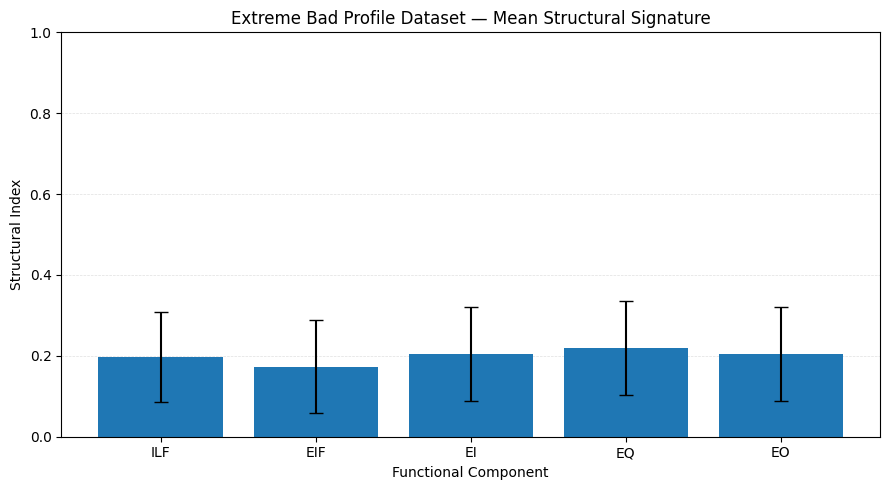

INFO | [U01.3] Extreme acceptance thresholds | mean std(IS) >= 0.100 | negative Beta >= 3 | min(Beta) <= -1.000 | max|Beta| >= 8.000 | cond >= 1.00e+05
INFO | [U01.3] Observed extreme metrics | mean std(IS)=0.1149 | negative Beta=3 | min(Beta)=-3.8296 | max|Beta|=9.6623 | cond=1.37e+01
INFO | [U01.3] First five generated projects:
PROJECT_CODE  APPLICATION_DOMAIN  FP_EFFORT  IFPUG_FP  IFPUG_ILF  IFPUG_EIF  IFPUG_EI  IFPUG_EQ  IFPUG_EO
       EX_01 Extreme_Bad_Profile     366.75       444          4         25        31        15         9
       EX_02 Extreme_Bad_Profile     384.36       427          6          8        14        35        23
       EX_03 Extreme_Bad_Profile    1680.00       336         16         19         1         1         7
       EX_04 Extreme_Bad_Profile      63.36       144          1          5         3         8        11
       EX_05 Extreme_Bad_Profile      56.72       432          2         11        21         9        43
INFO | [U01.3] Extreme Bad Prof

In [56]:
# @title
# ============================================================
# U01.3 — EXTREME BAD PROFILE DATASET GENERATOR
# ============================================================
#
# Generates an intentionally pathological synthetic dataset
# characterized by:
#
# - highly incoherent structural signatures;
# - strong structural dispersion;
# - an underlying productivity law driven by extreme Beta
#   coefficients, including multiple negative values;
# - high regression instability;
# - intentionally adverse numerical conditions.
#
# The generation algorithm, thresholds, hidden Beta law,
# acceptance criteria and fallback behavior are intentionally
# preserved from the original experimental implementation.
# ============================================================

logger.info("[U01.3] Starting Extreme Bad Profile dataset generation")


# ------------------------------------------------------------
# Scenario configuration
# ------------------------------------------------------------

DOMAIN = "Extreme_Bad_Profile"
N_PROJECTS = 80


# ------------------------------------------------------------
# Structural-signature configuration
# ------------------------------------------------------------
#
# The target signature is deliberately neutral, while the
# variability is intentionally very high.
#
# This produces heterogeneous and often strongly dominant
# structural profiles.
# ------------------------------------------------------------

IS_TARGET = np.array(
    [0.20, 0.20, 0.20, 0.20, 0.20],
    dtype=float
)

IS_VAR = 0.22

IS_VAR_WEIGHTS = np.array(
    [1.4, 1.2, 1.8, 1.8, 1.6],
    dtype=float
)

# Wide structural guardrails intentionally allow substantial
# dominance and marginality among functional components.
IS_MIN = 0.01
IS_MAX = 0.85


# ------------------------------------------------------------
# Project-size distribution
# ------------------------------------------------------------

FP_TARGET_MEAN = 500
FP_TARGET_SPREAD = 240

FP_MIN = 120
FP_MAX = 1600


# ------------------------------------------------------------
# Random seed and outputs
# ------------------------------------------------------------

SEED = 42

OUTPUT_CSV = (
    QUALITY_DIR
    / "U01_03_extreme_bad_profile_dataset.csv"
)

OUTPUT_FIGURE = (
    QUALITY_DIR
    / "U01_03_extreme_bad_profile_dataset.png"
)


# ------------------------------------------------------------
# IFPUG constants
# ------------------------------------------------------------

COMP_LABELS = [
    "ILF",
    "EIF",
    "EI",
    "EQ",
    "EO",
]

COMP_NAMES = [
    "IFPUG_ILF",
    "IFPUG_EIF",
    "IFPUG_EI",
    "IFPUG_EQ",
    "IFPUG_EO",
]

# Average IFPUG FP weights
WEIGHTS_FP = np.array(
    [10, 7, 4, 4, 5],
    dtype=float
)


# ------------------------------------------------------------
# Hidden pathological productivity law
# ------------------------------------------------------------
#
# Observed productivity is intentionally generated from a
# latent Beta vector containing strong negative coefficients.
#
# This creates a controlled extreme scenario where the
# regression is expected to recover negative and unstable
# component effects.
# ------------------------------------------------------------

BETA_TRUE_EXTREME = np.array(
    [-6.0, -3.5, 12.0, -5.0, 9.0],
    dtype=float
)

# Relative productivity noise
Y_NOISE_STD = 0.35

# Minimum productivity to avoid zero/negative effort
PROD_FLOOR = 0.20


# ------------------------------------------------------------
# Extreme acceptance criteria
# ------------------------------------------------------------

MAX_TRIES = 1000


# Structural incoherence
MIN_MEAN_STD_IS = 0.10


# Extreme Beta behavior
MIN_NEG_BETA = 3

MIN_BETA_MIN = -1.0

MIN_MAX_ABS_BETA = 8.0


# Numerical instability
MIN_COND = 1e5


# ------------------------------------------------------------
# Structural-vector generation
# ------------------------------------------------------------

def sample_is_vector(
    rng,
    is_target,
    is_var,
    is_var_weights,
    is_min,
    is_max,
    max_tries=2000
):
    """
    Generate a highly variable normalized structural-index
    vector around the configured target signature.

    Component-specific Gaussian noise intentionally produces
    substantial structural dispersion.

    The resulting vector must satisfy the configured global
    minimum and maximum structural-index constraints.
    """

    is_target = np.array(
        is_target,
        dtype=float
    )

    is_target = (
        is_target
        / is_target.sum()
    )


    weights = np.array(
        is_var_weights,
        dtype=float
    )

    weights = np.clip(
        weights,
        0.0,
        None
    )


    for _ in range(
        max_tries
    ):

        noise = rng.normal(
            0.0,
            is_var * weights,
            size=5
        )

        vector = (
            is_target
            + noise
        )

        vector = np.clip(
            vector,
            1e-9,
            None
        )

        vector = (
            vector
            / vector.sum()
        )


        if (
            vector.min() >= is_min
            and vector.max() <= is_max
        ):
            return vector


    raise ValueError(
        "Unable to generate a structural-index vector with "
        "the configured extreme constraints. Reduce IS_VAR "
        "or relax IS_MIN / IS_MAX."
    )


# ------------------------------------------------------------
# Structural signature -> IFPUG component counts
# ------------------------------------------------------------

def is_to_counts(
    is_vector,
    fp_target,
    weights_fp
):
    """
    Convert a structural-index vector into integer functional
    component counts while keeping total FP close to the
    requested target.
    """

    fp_by_component = (
        is_vector
        * fp_target
    )

    counts = np.round(
        fp_by_component
        / weights_fp
    ).astype(int)

    counts = np.clip(
        counts,
        1,
        None
    )

    fp_total = int(
        np.dot(
            counts,
            weights_fp
        )
    )

    return counts, fp_total


# ------------------------------------------------------------
# Beta estimation
# ------------------------------------------------------------

def estimate_beta_no_intercept(
    X,
    y
):
    """
    Estimate OLS Beta coefficients without intercept.
    """

    XtX = (
        X.T
        @ X
    )

    Xty = (
        X.T
        @ y
    )

    beta = np.linalg.solve(
        XtX,
        Xty
    )

    return beta, XtX


# ------------------------------------------------------------
# Dataset generation
# ------------------------------------------------------------

def build_dataset(
    seed_value
):
    """
    Generate one complete Extreme Bad Profile dataset and
    calculate the corresponding structural and regression
    diagnostics.
    """

    rng = np.random.default_rng(
        seed_value
    )

    rows = []


    for project_index in range(
        1,
        N_PROJECTS + 1
    ):

        # ----------------------------------------------------
        # Generate highly dispersed structural signature
        # ----------------------------------------------------

        structural_vector = (
            sample_is_vector(
                rng,
                IS_TARGET,
                IS_VAR,
                IS_VAR_WEIGHTS,
                IS_MIN,
                IS_MAX
            )
        )


        # ----------------------------------------------------
        # Generate target project size
        # ----------------------------------------------------

        fp_target = int(
            np.clip(
                rng.normal(
                    FP_TARGET_MEAN,
                    FP_TARGET_SPREAD
                ),
                FP_MIN,
                FP_MAX
            )
        )


        # ----------------------------------------------------
        # Convert IS to IFPUG component counts
        # ----------------------------------------------------

        counts, fp_total = (
            is_to_counts(
                structural_vector,
                fp_target,
                WEIGHTS_FP
            )
        )


        # ----------------------------------------------------
        # Reconstruct structural signature from counts
        #
        # As in the real analysis pipeline, the X row is
        # reconstructed from integer IFPUG counts rather than
        # taken directly from the generated latent vector.
        # ----------------------------------------------------

        fp_by_component = (
            counts
            * WEIGHTS_FP
        )

        X_row = (
            fp_by_component
            / fp_by_component.sum()
        )


        # ----------------------------------------------------
        # Generate pathological productivity
        # ----------------------------------------------------
        #
        # Latent productivity is derived from the extreme Beta
        # vector and perturbed using relative Gaussian noise.
        # ----------------------------------------------------

        productivity_base = float(
            np.dot(
                X_row,
                BETA_TRUE_EXTREME
            )
        )

        productivity = (
            productivity_base
            * float(
                1.0
                + rng.normal(
                    0.0,
                    Y_NOISE_STD
                )
            )
        )


        # ----------------------------------------------------
        # Positive productivity guardrail
        # ----------------------------------------------------

        productivity = max(
            productivity,
            PROD_FLOOR
        )


        effort = (
            fp_total
            / productivity
        )


        # ----------------------------------------------------
        # Store project
        # ----------------------------------------------------

        rows.append(
            {
                "PROJECT_CODE":
                    f"{DOMAIN.replace(' ', '_')[:2].upper()}_{project_index:02d}",

                "APPLICATION_DOMAIN":
                    DOMAIN,

                "FP_EFFORT":
                    round(
                        float(effort),
                        2
                    ),

                "IFPUG_FP":
                    int(fp_total),

                "IFPUG_ILF":
                    int(counts[0]),

                "IFPUG_EIF":
                    int(counts[1]),

                "IFPUG_EI":
                    int(counts[2]),

                "IFPUG_EQ":
                    int(counts[3]),

                "IFPUG_EO":
                    int(counts[4]),
            }
        )


    df = pd.DataFrame(
        rows
    )


    # --------------------------------------------------------
    # Reconstruct analysis matrix X
    # --------------------------------------------------------

    counts_matrix = (
        df[COMP_NAMES]
        .to_numpy(float)
    )

    fp_by_component = (
        counts_matrix
        * WEIGHTS_FP
    )

    X = (
        fp_by_component
        / fp_by_component.sum(
            axis=1,
            keepdims=True
        )
    )


    # --------------------------------------------------------
    # Effective productivity vector y
    # --------------------------------------------------------

    y = (
        df["IFPUG_FP"].to_numpy(float)
        / df["FP_EFFORT"].to_numpy(float)
    )


    # --------------------------------------------------------
    # Estimate Beta
    # --------------------------------------------------------

    beta, XtX = (
        estimate_beta_no_intercept(
            X,
            y
        )
    )


    # --------------------------------------------------------
    # Regression diagnostics
    # --------------------------------------------------------

    condition_number = float(
        np.linalg.cond(
            XtX
        )
    )

    negative_beta_count = int(
        (beta < 0).sum()
    )

    max_abs_beta = float(
        np.max(
            np.abs(beta)
        )
    )

    beta_min = float(
        np.min(
            beta
        )
    )


    # --------------------------------------------------------
    # Structural diagnostics
    # --------------------------------------------------------

    structural_std = (
        X.std(
            axis=0
        )
    )

    structural_mean = (
        X.mean(
            axis=0
        )
    )

    mean_structural_std = float(
        np.mean(
            structural_std
        )
    )


    info = {
        "beta":
            beta,

        "cond":
            condition_number,

        "neg_count":
            negative_beta_count,

        "beta_min":
            beta_min,

        "max_abs_beta":
            max_abs_beta,

        "is_std":
            structural_std,

        "is_mean":
            structural_mean,

        "mean_std_is":
            mean_structural_std,
    }


    return df, info


# ------------------------------------------------------------
# Extreme-profile acceptance test
# ------------------------------------------------------------

def accept_extreme(
    info
):
    """
    Determine whether the generated dataset simultaneously
    satisfies all intended pathological conditions.

    Acceptance requires:

    1. high structural dispersion;
    2. strongly negative/extreme Beta coefficients;
    3. high numerical instability.

    The logical structure is intentionally preserved from the
    original implementation.
    """

    structural_bad = (
        info["mean_std_is"]
        >= MIN_MEAN_STD_IS
    )


    beta_bad = (
        info["neg_count"] >= MIN_NEG_BETA
        and info["beta_min"] <= MIN_BETA_MIN
        and info["max_abs_beta"] >= MIN_MAX_ABS_BETA
    )


    condition_bad = (
        info["cond"]
        >= MIN_COND
    )


    return (
        structural_bad
        and beta_bad
        and condition_bad
    )


# ------------------------------------------------------------
# Dataset-generation and acceptance loop
# ------------------------------------------------------------

accepted = False

seed_try = SEED

df_final = None
info_final = None

SEED_ACCEPTED = None
ATTEMPT_ACCEPTED = None


for attempt in range(
    1,
    MAX_TRIES + 1
):

    df_try, info_try = (
        build_dataset(
            seed_try
        )
    )


    # Always retain the most recent generated dataset.
    #
    # This preserves the original fallback behavior when no
    # dataset satisfies every extreme acceptance criterion.
    df_final = df_try
    info_final = info_try

    SEED_ACCEPTED = seed_try
    ATTEMPT_ACCEPTED = attempt


    if accept_extreme(
        info_try
    ):

        accepted = True

        logger.info(
            "[U01.3] Extreme dataset accepted on attempt %d "
            "with seed %d",
            attempt,
            seed_try
        )

        break


    seed_try += 1


# ------------------------------------------------------------
# Scenario classification
# ------------------------------------------------------------

if accepted:

    EXTREME_CLASS = "STRONG_EXTREME"

    logger.info(
        "[U01.3] Dataset classified as STRONG_EXTREME"
    )


else:

    EXTREME_CLASS = "WEAK_EXTREME"

    logger.warning(
        "[U01.3] Extreme acceptance criteria were not fully "
        "satisfied after %d attempts. "
        "The final generated dataset is retained and "
        "classified as WEAK_EXTREME.",
        MAX_TRIES
    )


# ------------------------------------------------------------
# Export generated dataset
# ------------------------------------------------------------

df_final.to_csv(
    OUTPUT_CSV,
    sep=";",
    index=False,
    encoding="utf-8",
    decimal=","
)


logger.info(
    "[U01.3] Extreme Bad Profile dataset saved: %s",
    OUTPUT_CSV
)

logger.info(
    "[U01.3] Generated projects: %d",
    len(df_final)
)


# ------------------------------------------------------------
# Generation diagnostics
# ------------------------------------------------------------

effective_productivity = (
    df_final["IFPUG_FP"]
    / df_final["FP_EFFORT"]
)

beta = (
    info_final["beta"]
)


logger.info(
    "[U01.3] Scenario classification: %s",
    EXTREME_CLASS
)

logger.info(
    "[U01.3] Final attempt: %d | seed: %d",
    ATTEMPT_ACCEPTED,
    SEED_ACCEPTED
)

logger.info(
    "[U01.3] Effective productivity min/mean/max: "
    "%.3f / %.3f / %.3f",
    effective_productivity.min(),
    effective_productivity.mean(),
    effective_productivity.max()
)


# ------------------------------------------------------------
# True vs estimated Beta
# ------------------------------------------------------------

logger.info(
    "[U01.3] Hidden extreme Beta coefficients: %s",
    {
        component: round(
            float(value),
            4
        )
        for component, value
        in zip(
            COMP_LABELS,
            BETA_TRUE_EXTREME
        )
    }
)


logger.info(
    "[U01.3] Estimated Beta coefficients: %s",
    {
        component: round(
            float(value),
            4
        )
        for component, value
        in zip(
            COMP_LABELS,
            beta
        )
    }
)


logger.info(
    "[U01.3] Negative Beta coefficients: %d",
    info_final["neg_count"]
)

logger.info(
    "[U01.3] Minimum Beta coefficient: %.4f",
    info_final["beta_min"]
)

logger.info(
    "[U01.3] Maximum absolute Beta: %.4f",
    info_final["max_abs_beta"]
)

logger.info(
    "[U01.3] Condition number: %.2e",
    info_final["cond"]
)

logger.info(
    "[U01.3] Mean structural-index standard deviation: %.4f",
    info_final["mean_std_is"]
)


logger.info(
    "[U01.3] Structural-index standard deviations: %s",
    {
        component: round(
            float(value),
            4
        )
        for component, value
        in zip(
            COMP_LABELS,
            info_final["is_std"]
        )
    }
)


# ------------------------------------------------------------
# Reconstruct structural signature
# ------------------------------------------------------------

counts_matrix = (
    df_final[COMP_NAMES]
    .to_numpy(float)
)

fp_by_component = (
    counts_matrix
    * WEIGHTS_FP
)

structural_matrix = (
    fp_by_component
    / fp_by_component.sum(
        axis=1,
        keepdims=True
    )
)

structural_mean = (
    structural_matrix.mean(
        axis=0
    )
)

structural_std = (
    structural_matrix.std(
        axis=0
    )
)


logger.info(
    "[U01.3] Mean structural signature: %s",
    {
        component: round(
            float(value),
            3
        )
        for component, value
        in zip(
            COMP_LABELS,
            structural_mean
        )
    }
)


# ------------------------------------------------------------
# Standardized structural-signature chart
# ------------------------------------------------------------
#
# IMPORTANT:
# Chart structure, component order, axis scale and dimensions
# intentionally match U01.1 and U01.2 to guarantee direct
# visual comparison across all three synthetic scenarios.
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(9, 5)
)

x = np.arange(
    len(COMP_LABELS)
)


ax.bar(
    x,
    structural_mean,
    yerr=structural_std,
    capsize=5
)


ax.set_xticks(
    x
)

ax.set_xticklabels(
    COMP_LABELS
)

ax.set_ylim(
    0,
    1
)

ax.set_xlabel(
    "Functional Component"
)

ax.set_ylabel(
    "Structural Index"
)

ax.set_title(
    "Extreme Bad Profile Dataset — Mean Structural Signature"
)


ax.yaxis.grid(
    True,
    linestyle="--",
    linewidth=0.5,
    alpha=0.4
)

ax.set_axisbelow(
    True
)

fig.tight_layout()


# Save before display
fig.savefig(
    OUTPUT_FIGURE,
    dpi=200,
    bbox_inches="tight"
)


logger.info(
    "[U01.3] Structural signature figure saved: %s",
    OUTPUT_FIGURE
)

plt.show()


# ------------------------------------------------------------
# Final acceptance summary
# ------------------------------------------------------------

logger.info(
    "[U01.3] Extreme acceptance thresholds | "
    "mean std(IS) >= %.3f | "
    "negative Beta >= %d | "
    "min(Beta) <= %.3f | "
    "max|Beta| >= %.3f | "
    "cond >= %.2e",
    MIN_MEAN_STD_IS,
    MIN_NEG_BETA,
    MIN_BETA_MIN,
    MIN_MAX_ABS_BETA,
    MIN_COND
)


logger.info(
    "[U01.3] Observed extreme metrics | "
    "mean std(IS)=%.4f | "
    "negative Beta=%d | "
    "min(Beta)=%.4f | "
    "max|Beta|=%.4f | "
    "cond=%.2e",
    info_final["mean_std_is"],
    info_final["neg_count"],
    info_final["beta_min"],
    info_final["max_abs_beta"],
    info_final["cond"]
)


# ------------------------------------------------------------
# Dataset preview
# ------------------------------------------------------------

logger.info(
    "[U01.3] First five generated projects:\n%s",
    df_final.head(5).to_string(
        index=False
    )
)


logger.info(
    "[U01.3] Extreme Bad Profile dataset generation completed"
)

# U02 — Baseline Multicollinearity & Beta Stability Analysis

This utility evaluates the statistical reliability and stability of the baseline dataset across application domains through three complementary analyses:

Variance Inflation Factor (VIF)
Assesses multicollinearity and informational redundancy among the five IFPUG functional components (ILF, EIF, EI, EQ, EO).
OLS Beta Coefficients (β)
Estimates component-specific productivity coefficients to evaluate their sign, magnitude, plausibility, and consistency.
Bootstrap Stability Analysis (N = 1000)
Evaluates parameter robustness through non-parametric resampling, estimating Standard Errors and 95% Confidence Intervals for each β coefficient.

The combined analysis identifies potential multicollinearity, coefficient instability, and excessive sampling variability, providing a quantitative validation of baseline robustness.


INFO | [U02.1] Starting Baseline Multicollinearity & Beta Stability Analysis
INFO | [U02.1] Baseline loaded: 207 projects
INFO | [U02.1] Analysing domain: Billing
INFO | [U02.1] Domain Billing | projects=62 | active OLS components=5/5 | R2=0.1249 | Adj R2=0.0635
INFO | [U02.1] Domain Billing | Beta={'ILF': 2.3927, 'EIF': 3.5542, 'EI': 0.0377, 'EQ': 2.7935, 'EO': 2.4882}
INFO | [U02.1] Domain Billing | successful bootstrap iterations=1000/1000
INFO | [U02.1] Analysing domain: Data Platform
INFO | [U02.1] Domain Data Platform | projects=67 | active OLS components=5/5 | R2=0.0467 | Adj R2=-0.0148
INFO | [U02.1] Domain Data Platform | Beta={'ILF': 2.7374, 'EIF': 1.63, 'EI': 2.6936, 'EQ': 2.4262, 'EO': 1.812}
INFO | [U02.1] Domain Data Platform | successful bootstrap iterations=1000/1000
INFO | [U02.1] Analysing domain: Integration
INFO | [U02.1] Domain Integration | projects=78 | active OLS components=3/5 | R2=0.0003 | Adj R2=-0.0264
INFO | [U02.1] Domain Integration | Beta={'ILF': 0.0, 'E

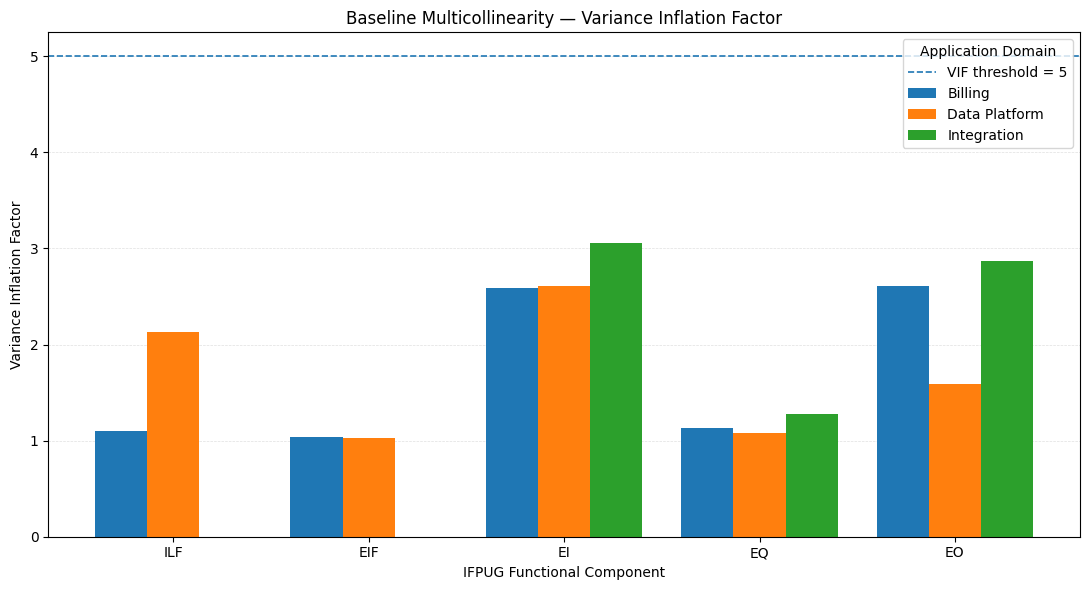

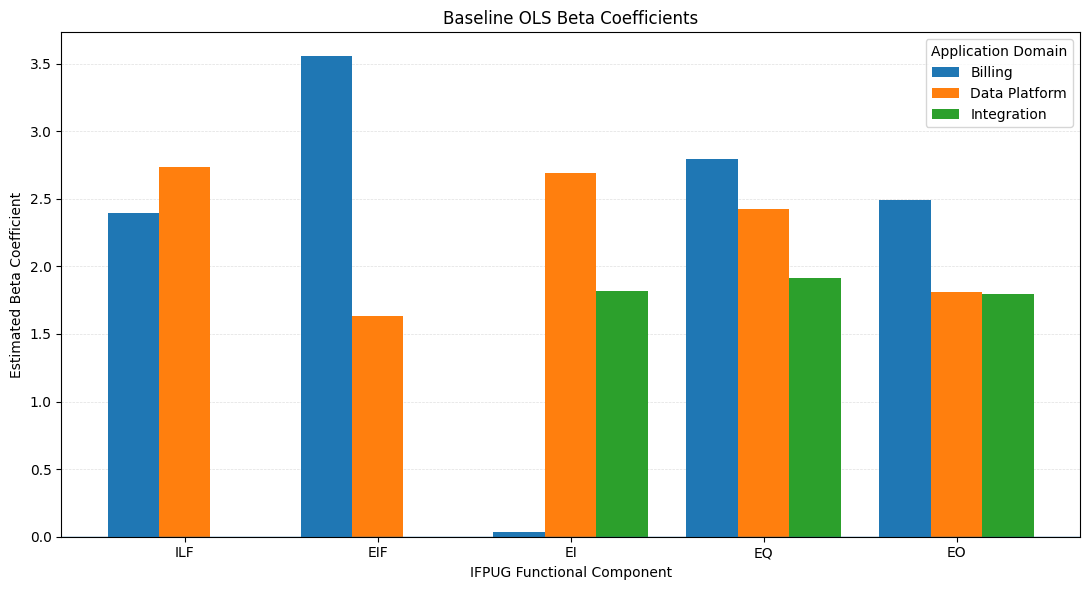

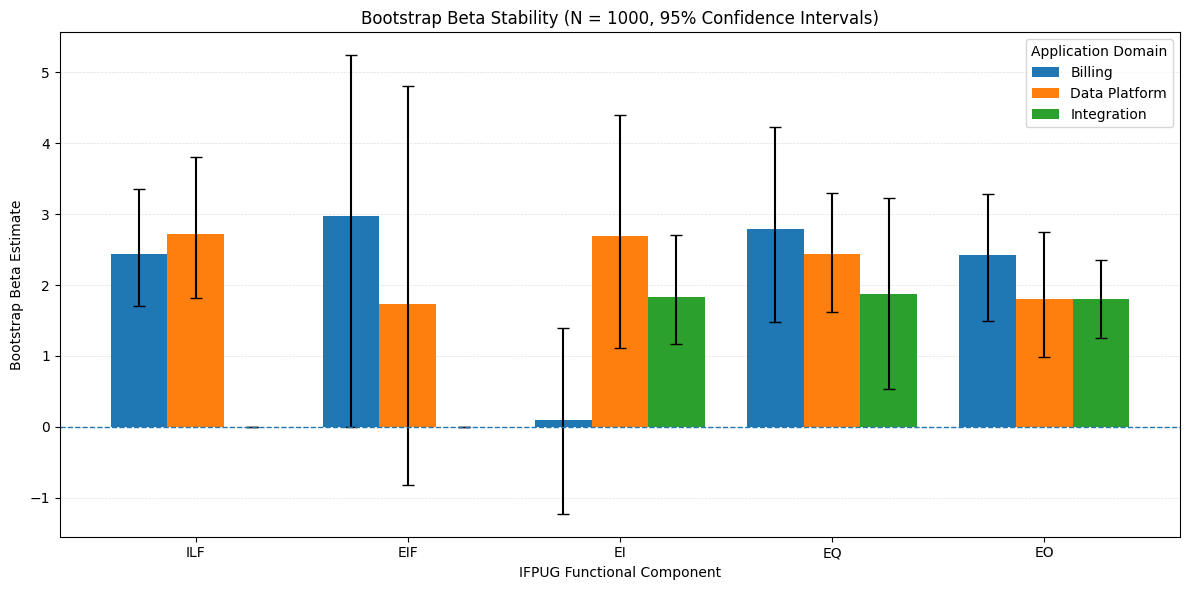

INFO | [U02.1] Baseline Multicollinearity & Beta Stability Analysis completed


In [59]:
# @title
# ============================================================
# U02.1 — BASELINE MULTICOLLINEARITY & BETA STABILITY ANALYSIS
# ============================================================
#
# Performs three complementary statistical diagnostics:
#
# 1. Variance Inflation Factor (VIF)
#    Evaluates multicollinearity among raw IFPUG component
#    counts: ILF, EIF, EI, EQ and EO.
#
# 2. Baseline OLS Beta coefficients
#    Estimates productivity coefficients using reconstructed
#    Structural Indices and a no-intercept OLS model.
#
# 3. Bootstrap Stability Analysis (N = 1000)
#    Evaluates sampling robustness of Beta coefficients through
#    non-parametric resampling and 95% confidence intervals.
#
# Analysis is performed independently for each application
# domain.
# ============================================================


# ------------------------------------------------------------
# Dependencies
# ------------------------------------------------------------

import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm

from statsmodels.stats.outliers_influence import (
    variance_inflation_factor
)


logger.info(
    "[U02.1] Starting Baseline Multicollinearity "
    "& Beta Stability Analysis"
)


# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

RAW_BASELINE_FILENAME = "RAW_BASELINE.csv"

RAW_BASELINE_PATH = os.path.join(
    INPUT_DIR,
    RAW_BASELINE_FILENAME
)

N_BOOTSTRAP = 1000
RNG_SEED = 42

VARIANCE_EPS = 1e-6


# ------------------------------------------------------------
# IFPUG constants
# ------------------------------------------------------------

COMP_LABELS = [
    "ILF",
    "EIF",
    "EI",
    "EQ",
    "EO",
]

COMP_NAMES = [
    "IFPUG_ILF",
    "IFPUG_EIF",
    "IFPUG_EI",
    "IFPUG_EQ",
    "IFPUG_EO",
]

WEIGHTS_FP = np.array(
    [10, 7, 4, 4, 5],
    dtype=float
)


# ------------------------------------------------------------
# Output files
# ------------------------------------------------------------

OUTPUT_VIF = os.path.join(
    QUALITY_DIR,
    "U02_01_vif_analysis.csv"
)

OUTPUT_BETA = os.path.join(
    QUALITY_DIR,
    "U02_01_beta_ols_analysis.csv"
)

OUTPUT_BOOTSTRAP = os.path.join(
    QUALITY_DIR,
    "U02_01_beta_bootstrap_1000.csv"
)

OUTPUT_VIF_SUMMARY = os.path.join(
    QUALITY_DIR,
    "U02_01_vif_summary.csv"
)


# ------------------------------------------------------------
# Load baseline
# ------------------------------------------------------------

if not os.path.exists(
    RAW_BASELINE_PATH
):

    raise FileNotFoundError(
        f"RAW baseline file not found: "
        f"{RAW_BASELINE_PATH}"
    )


df_baseline = pd.read_csv(
    RAW_BASELINE_PATH,
    sep=";",
    decimal=",",
    encoding="utf-8"
)


logger.info(
    "[U02.1] Baseline loaded: %d projects",
    len(df_baseline)
)


# ------------------------------------------------------------
# Input validation
# ------------------------------------------------------------

required_columns = [
    "APPLICATION_DOMAIN",
    "FP_EFFORT",
    "IFPUG_FP",
    *COMP_NAMES,
]


missing_columns = [
    column
    for column in required_columns
    if column not in df_baseline.columns
]


if missing_columns:

    raise ValueError(
        "Missing required baseline columns: "
        f"{missing_columns}"
    )


if df_baseline.empty:

    raise ValueError(
        "RAW baseline dataset is empty."
    )


# ------------------------------------------------------------
# Result containers
# ------------------------------------------------------------

vif_results = []
beta_results = []
bootstrap_results = []


# ------------------------------------------------------------
# Utility — Structural matrix reconstruction
# ------------------------------------------------------------

def reconstruct_structural_matrix(
    df_domain
):
    """
    Reconstruct Structural Indices from raw IFPUG component
    counts.

    Each component contribution is calculated using the
    standard IFPUG average FP weights and divided by total
    IFPUG_FP.
    """

    counts = (
        df_domain[COMP_NAMES]
        .fillna(0)
        .to_numpy(dtype=float)
    )

    fp_by_component = (
        counts
        * WEIGHTS_FP
    )

    total_fp = (
        df_domain["IFPUG_FP"]
        .to_numpy(float)
        .reshape(-1, 1)
    )

    X_prop = np.divide(
        fp_by_component,
        total_fp,
        out=np.zeros_like(
            fp_by_component
        ),
        where=total_fp != 0
    )

    return X_prop


# ------------------------------------------------------------
# Utility — Observed productivity
# ------------------------------------------------------------

def calculate_productivity(
    df_domain
):
    """
    Calculate observed productivity as:

        Productivity = IFPUG_FP / FP_EFFORT
    """

    fp = (
        df_domain["IFPUG_FP"]
        .to_numpy(float)
    )

    effort = (
        df_domain["FP_EFFORT"]
        .to_numpy(float)
    )


    if np.any(
        effort <= 0
    ):

        raise ValueError(
            "FP_EFFORT contains zero or negative values."
        )


    return (
        fp
        / effort
    )


# ------------------------------------------------------------
# Utility — VIF on raw IFPUG counts
# ------------------------------------------------------------

def calculate_vif(
    df_domain,
    domain
):
    """
    Calculate Variance Inflation Factors using raw IFPUG
    component counts.

    Components with approximately zero variance are excluded
    from VIF estimation and explicitly reported as inactive.
    """

    X_vif_raw = (
        df_domain[COMP_NAMES]
        .dropna()
    )


    active_vif_cols = [
        column
        for column in COMP_NAMES
        if X_vif_raw[column].std()
        > VARIANCE_EPS
    ]


    inactive_vif_cols = [
        column
        for column in COMP_NAMES
        if column not in active_vif_cols
    ]


    # --------------------------------------------------------
    # Active components
    # --------------------------------------------------------

    if active_vif_cols:

        X_vif = sm.add_constant(
            X_vif_raw[
                active_vif_cols
            ],
            has_constant="add"
        )


        for column_index, column in enumerate(
            active_vif_cols,
            start=1
        ):

            try:

                vif_value = (
                    variance_inflation_factor(
                        X_vif.values,
                        column_index
                    )
                )


                if (
                    np.isnan(vif_value)
                    or np.isinf(vif_value)
                ):

                    vif_numeric = np.nan
                    vif_formatted = "N/A"

                else:

                    vif_numeric = round(
                        float(vif_value),
                        4
                    )

                    vif_formatted = (
                        f"{vif_value:.2f}"
                    )


            except Exception:

                vif_numeric = np.nan
                vif_formatted = "N/A"


            vif_results.append(
                {
                    "APPLICATION_DOMAIN":
                        domain,

                    "COMPONENTE_IFPUG":
                        column,

                    "VIF":
                        vif_numeric,

                    "VIF_FORMATTED":
                        vif_formatted,

                    "ACTIVE_COMPONENT":
                        True,
                }
            )


    # --------------------------------------------------------
    # Inactive components
    # --------------------------------------------------------

    for column in inactive_vif_cols:

        vif_results.append(
            {
                "APPLICATION_DOMAIN":
                    domain,

                "COMPONENTE_IFPUG":
                    column,

                "VIF":
                    np.nan,

                "VIF_FORMATTED":
                    "N/A (Variance ≈ 0)",

                "ACTIVE_COMPONENT":
                    False,
            }
        )


# ------------------------------------------------------------
# Utility — OLS Beta estimation
# ------------------------------------------------------------

def estimate_beta_ols(
    X_prop,
    y_obs
):
    """
    Estimate no-intercept OLS Beta coefficients using only
    Structural Index columns with non-negligible variance.
    """

    valid_mask = (
        np.std(
            X_prop,
            axis=0
        )
        > VARIANCE_EPS
    )

    valid_indices = np.where(
        valid_mask
    )[0]

    X_valid = (
        X_prop[
            :,
            valid_mask
        ]
    )


    beta_full = np.zeros(
        len(COMP_NAMES),
        dtype=float
    )


    if X_valid.shape[1] == 0:

        return (
            beta_full,
            valid_mask,
            0.0,
            0.0
        )


    beta_valid, _, _, _ = (
        np.linalg.lstsq(
            X_valid,
            y_obs,
            rcond=None
        )
    )


    beta_full[
        valid_indices
    ] = beta_valid


    y_pred = (
        X_valid
        @ beta_valid
    )


    ss_res = np.sum(
        (y_obs - y_pred) ** 2
    )

    ss_tot = np.sum(
        (
            y_obs
            - np.mean(y_obs)
        ) ** 2
    )


    r2 = (
        1.0
        - ss_res / ss_tot
        if ss_tot != 0
        else 0.0
    )


    n_obs = len(
        y_obs
    )

    p_vars = (
        X_valid.shape[1]
    )


    r2_adj = (
        1.0
        - (1.0 - r2)
        * (n_obs - 1)
        / (n_obs - p_vars)
        if n_obs > p_vars
        else r2
    )


    return (
        beta_full,
        valid_mask,
        r2,
        r2_adj
    )


# ------------------------------------------------------------
# Utility — Bootstrap stability
# ------------------------------------------------------------

def bootstrap_beta_stability(
    X_prop,
    y_obs,
    valid_mask,
    n_bootstrap,
    seed
):
    """
    Perform non-parametric bootstrap resampling for Beta
    coefficient stability assessment.
    """

    valid_indices = np.where(
        valid_mask
    )[0]

    X_valid = (
        X_prop[
            :,
            valid_mask
        ]
    )


    if X_valid.shape[1] == 0:

        return np.empty(
            (
                0,
                len(COMP_NAMES)
            )
        )


    rng = np.random.default_rng(
        seed
    )

    n_samples = len(
        y_obs
    )

    bootstrap_betas = []


    for _ in range(
        n_bootstrap
    ):

        boot_indices = rng.choice(
            n_samples,
            size=n_samples,
            replace=True
        )


        X_boot = (
            X_valid[
                boot_indices
            ]
        )

        y_boot = (
            y_obs[
                boot_indices
            ]
        )


        try:

            beta_boot_valid, _, _, _ = (
                np.linalg.lstsq(
                    X_boot,
                    y_boot,
                    rcond=None
                )
            )


            beta_boot_full = np.zeros(
                len(COMP_NAMES),
                dtype=float
            )


            beta_boot_full[
                valid_indices
            ] = beta_boot_valid


            bootstrap_betas.append(
                beta_boot_full
            )


        except Exception:

            continue


    return np.asarray(
        bootstrap_betas,
        dtype=float
    )


# ------------------------------------------------------------
# Domain-level analysis
# ------------------------------------------------------------

domains = (
    df_baseline[
        "APPLICATION_DOMAIN"
    ]
    .dropna()
    .unique()
)


for domain in domains:

    logger.info(
        "[U02.1] Analysing domain: %s",
        domain
    )


    df_domain = (
        df_baseline[
            df_baseline[
                "APPLICATION_DOMAIN"
            ]
            == domain
        ]
        .copy()
    )


    # --------------------------------------------------------
    # A. Variance Inflation Factor
    # --------------------------------------------------------

    calculate_vif(
        df_domain,
        domain
    )


    # --------------------------------------------------------
    # Reconstruct Structural Indices
    # --------------------------------------------------------

    X_prop = (
        reconstruct_structural_matrix(
            df_domain
        )
    )


    # --------------------------------------------------------
    # Observed productivity
    # --------------------------------------------------------

    y_obs = (
        calculate_productivity(
            df_domain
        )
    )


    # --------------------------------------------------------
    # B. OLS Beta coefficients
    # --------------------------------------------------------

    (
        beta_full_ols,
        valid_mask,
        r2,
        r2_adj
    ) = estimate_beta_ols(
        X_prop,
        y_obs
    )


    for index, component in enumerate(
        COMP_NAMES
    ):

        beta_results.append(
            {
                "APPLICATION_DOMAIN":
                    domain,

                "COMPONENTE_IFPUG":
                    component,

                "BETA_COEFFICIENT":
                    round(
                        float(
                            beta_full_ols[
                                index
                            ]
                        ),
                        6
                    ),

                "R2":
                    round(
                        float(r2),
                        4
                    ),

                "R2_ADJUSTED":
                    round(
                        float(r2_adj),
                        4
                    ),

                "ACTIVE_COMPONENT":
                    bool(
                        valid_mask[
                            index
                        ]
                    ),
            }
        )


    # --------------------------------------------------------
    # C. Bootstrap resampling
    # --------------------------------------------------------

    bootstrap_betas = (
        bootstrap_beta_stability(
            X_prop=X_prop,
            y_obs=y_obs,
            valid_mask=valid_mask,
            n_bootstrap=N_BOOTSTRAP,
            seed=RNG_SEED
        )
    )


    if len(
        bootstrap_betas
    ) > 0:

        beta_means = np.mean(
            bootstrap_betas,
            axis=0
        )

        beta_std_errors = np.std(
            bootstrap_betas,
            axis=0,
            ddof=1
        )

        ci_lower = np.percentile(
            bootstrap_betas,
            2.5,
            axis=0
        )

        ci_upper = np.percentile(
            bootstrap_betas,
            97.5,
            axis=0
        )


    else:

        beta_means = np.zeros(
            len(COMP_NAMES)
        )

        beta_std_errors = np.zeros(
            len(COMP_NAMES)
        )

        ci_lower = np.zeros(
            len(COMP_NAMES)
        )

        ci_upper = np.zeros(
            len(COMP_NAMES)
        )


    for index, component in enumerate(
        COMP_NAMES
    ):

        bootstrap_results.append(
            {
                "APPLICATION_DOMAIN":
                    domain,

                "COMPONENTE_IFPUG":
                    component,

                "BETA_ORIGINAL":
                    round(
                        beta_full_ols[
                            index
                        ],
                        4
                    ),

                "BOOTSTRAP_MEAN":
                    round(
                        beta_means[
                            index
                        ],
                        4
                    ),

                "BOOTSTRAP_STD_ERR":
                    round(
                        beta_std_errors[
                            index
                        ],
                        4
                    ),

                "CI_95_LOWER":
                    round(
                        ci_lower[
                            index
                        ],
                        4
                    ),

                "CI_95_UPPER":
                    round(
                        ci_upper[
                            index
                        ],
                        4
                    ),

                "CI_95_FORMATTED":
                    (
                        f"[{ci_lower[index]:.2f}, "
                        f"{ci_upper[index]:.2f}]"
                    ),

                "ACTIVE_COMPONENT":
                    bool(
                        valid_mask[
                            index
                        ]
                    ),

                "BOOTSTRAP_ITERATIONS":
                    int(
                        len(
                            bootstrap_betas
                        )
                    ),
            }
        )


    # --------------------------------------------------------
    # Domain diagnostics
    # --------------------------------------------------------

    logger.info(
        "[U02.1] Domain %s | projects=%d | "
        "active OLS components=%d/%d | "
        "R2=%.4f | Adj R2=%.4f",
        domain,
        len(df_domain),
        int(valid_mask.sum()),
        len(COMP_NAMES),
        r2,
        r2_adj
    )


    logger.info(
        "[U02.1] Domain %s | Beta=%s",
        domain,
        {
            component: round(
                float(value),
                4
            )
            for component, value
            in zip(
                COMP_LABELS,
                beta_full_ols
            )
        }
    )


    logger.info(
        "[U02.1] Domain %s | successful bootstrap "
        "iterations=%d/%d",
        domain,
        len(bootstrap_betas),
        N_BOOTSTRAP
    )


# ------------------------------------------------------------
# Build result tables
# ------------------------------------------------------------

df_vif = pd.DataFrame(
    vif_results
)

df_beta = pd.DataFrame(
    beta_results
)

df_bootstrap = pd.DataFrame(
    bootstrap_results
)


df_vif_summary = (
    df_vif
    .pivot(
        index="COMPONENTE_IFPUG",
        columns="APPLICATION_DOMAIN",
        values="VIF_FORMATTED"
    )
    .reset_index()
)


# ------------------------------------------------------------
# Export CSV
# ------------------------------------------------------------

df_vif.to_csv(
    OUTPUT_VIF,
    sep=";",
    index=False,
    encoding="utf-8",
    decimal=","
)

df_beta.to_csv(
    OUTPUT_BETA,
    sep=";",
    index=False,
    encoding="utf-8",
    decimal=","
)

df_bootstrap.to_csv(
    OUTPUT_BOOTSTRAP,
    sep=";",
    index=False,
    encoding="utf-8",
    decimal=","
)

df_vif_summary.to_csv(
    OUTPUT_VIF_SUMMARY,
    sep=";",
    index=False,
    encoding="utf-8"
)


logger.info(
    "[U02.1] VIF results saved: %s",
    OUTPUT_VIF
)

logger.info(
    "[U02.1] OLS Beta results saved: %s",
    OUTPUT_BETA
)

logger.info(
    "[U02.1] Bootstrap results saved: %s",
    OUTPUT_BOOTSTRAP
)

logger.info(
    "[U02.1] VIF summary saved: %s",
    OUTPUT_VIF_SUMMARY
)


# ============================================================
# DIAGNOSTIC VISUALIZATIONS
# ============================================================


# ------------------------------------------------------------
# Figure 1 — VIF
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(11, 6)
)

domain_list = list(
    domains
)

x = np.arange(
    len(COMP_NAMES)
)

n_domains = len(
    domain_list
)

bar_width = (
    0.8
    / max(
        n_domains,
        1
    )
)


for domain_index, domain in enumerate(
    domain_list
):

    domain_data = (
        df_vif[
            df_vif[
                "APPLICATION_DOMAIN"
            ]
            == domain
        ]
        .set_index(
            "COMPONENTE_IFPUG"
        )
        .reindex(
            COMP_NAMES
        )
    )


    vif_values = (
        domain_data["VIF"]
        .to_numpy(
            dtype=float
        )
    )


    offset = (
        domain_index
        - (n_domains - 1) / 2
    ) * bar_width


    ax.bar(
        x + offset,
        vif_values,
        width=bar_width,
        label=domain
    )


ax.axhline(
    y=5.0,
    linestyle="--",
    linewidth=1.2,
    label="VIF threshold = 5"
)

ax.set_xticks(
    x
)

ax.set_xticklabels(
    COMP_LABELS
)

ax.set_xlabel(
    "IFPUG Functional Component"
)

ax.set_ylabel(
    "Variance Inflation Factor"
)

ax.set_title(
    "Baseline Multicollinearity — "
    "Variance Inflation Factor"
)

ax.legend(
    title="Application Domain"
)

ax.yaxis.grid(
    True,
    linestyle="--",
    linewidth=0.5,
    alpha=0.4
)

ax.set_axisbelow(
    True
)

fig.tight_layout()

plt.show()


# ------------------------------------------------------------
# Figure 2 — OLS Beta coefficients
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(11, 6)
)


for domain_index, domain in enumerate(
    domain_list
):

    domain_data = (
        df_beta[
            df_beta[
                "APPLICATION_DOMAIN"
            ]
            == domain
        ]
        .set_index(
            "COMPONENTE_IFPUG"
        )
        .reindex(
            COMP_NAMES
        )
    )


    beta_values = (
        domain_data[
            "BETA_COEFFICIENT"
        ]
        .to_numpy(
            dtype=float
        )
    )


    offset = (
        domain_index
        - (n_domains - 1) / 2
    ) * bar_width


    ax.bar(
        x + offset,
        beta_values,
        width=bar_width,
        label=domain
    )


ax.axhline(
    y=0,
    linewidth=1.0
)

ax.set_xticks(
    x
)

ax.set_xticklabels(
    COMP_LABELS
)

ax.set_xlabel(
    "IFPUG Functional Component"
)

ax.set_ylabel(
    "Estimated Beta Coefficient"
)

ax.set_title(
    "Baseline OLS Beta Coefficients"
)

ax.legend(
    title="Application Domain"
)

ax.yaxis.grid(
    True,
    linestyle="--",
    linewidth=0.5,
    alpha=0.4
)

ax.set_axisbelow(
    True
)

fig.tight_layout()

plt.show()


# ------------------------------------------------------------
# Figure 3 — Bootstrap stability
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(12, 6)
)


for domain_index, domain in enumerate(
    domain_list
):

    domain_data = (
        df_bootstrap[
            df_bootstrap[
                "APPLICATION_DOMAIN"
            ]
            == domain
        ]
        .set_index(
            "COMPONENTE_IFPUG"
        )
        .reindex(
            COMP_NAMES
        )
    )


    means = (
        domain_data[
            "BOOTSTRAP_MEAN"
        ]
        .to_numpy(
            dtype=float
        )
    )


    lower = (
        domain_data[
            "CI_95_LOWER"
        ]
        .to_numpy(
            dtype=float
        )
    )


    upper = (
        domain_data[
            "CI_95_UPPER"
        ]
        .to_numpy(
            dtype=float
        )
    )


    error_lower = (
        means
        - lower
    )

    error_upper = (
        upper
        - means
    )


    offset = (
        domain_index
        - (n_domains - 1) / 2
    ) * bar_width


    ax.bar(
        x + offset,
        means,
        width=bar_width,
        yerr=[
            error_lower,
            error_upper
        ],
        capsize=4,
        label=domain
    )


ax.axhline(
    y=0,
    linestyle="--",
    linewidth=1.0
)

ax.set_xticks(
    x
)

ax.set_xticklabels(
    COMP_LABELS
)

ax.set_xlabel(
    "IFPUG Functional Component"
)

ax.set_ylabel(
    "Bootstrap Beta Estimate"
)

ax.set_title(
    "Bootstrap Beta Stability "
    "(N = 1000, 95% Confidence Intervals)"
)

ax.legend(
    title="Application Domain"
)

ax.yaxis.grid(
    True,
    linestyle="--",
    linewidth=0.5,
    alpha=0.4
)

ax.set_axisbelow(
    True
)

fig.tight_layout()

plt.show()


logger.info(
    "[U02.1] Baseline Multicollinearity "
    "& Beta Stability Analysis completed"
)

# U03 — Coherence-Class Percentile Sensitivity Analysis

This utility evaluates the robustness of the Coherence Class classification by testing alternative percentile thresholds used to define High, Medium, and Low coherence levels.

Three configurations are compared:

Narrow: P33–P66
Baseline: P40–P80
Wide: P50–P90

For each application domain, the analysis measures the average productivity deviation associated with each coherence class and calculates a Separation Ratio between Low- and High-Coherence projects.

The objective is to verify whether the discriminatory capability of the coherence model remains stable when the percentile thresholds are changed. A consistent Separation Ratio across configurations provides evidence that the classification logic is not overly dependent on a specific percentile choice and therefore exhibits adequate sensitivity robustness.

INFO | [U03] Starting Coherence-Class Percentile Sensitivity Analysis
INFO | [U03] Loading configuration: Narrow (P33-66)
INFO | [U03] Configuration Narrow (P33-66) loaded: 207 projects
INFO | [U03] Narrow (P33-66) | Billing | High=0.0554 | Medium=0.1818 | Low=0.4958 | Separation=8.96x
INFO | [U03] Narrow (P33-66) | Data Platform | High=0.0880 | Medium=0.2461 | Low=0.4343 | Separation=4.94x
INFO | [U03] Narrow (P33-66) | Integration | High=0.0506 | Medium=0.1439 | Low=0.3598 | Separation=7.11x
INFO | [U03] Loading configuration: Baseline (P40-80)
INFO | [U03] Configuration Baseline (P40-80) loaded: 207 projects
INFO | [U03] Baseline (P40-80) | Billing | High=0.0634 | Medium=0.2602 | Low=0.5471 | Separation=8.62x
INFO | [U03] Baseline (P40-80) | Data Platform | High=0.1040 | Medium=0.2850 | Low=0.5009 | Separation=4.82x
INFO | [U03] Baseline (P40-80) | Integration | High=0.0637 | Medium=0.1955 | Low=0.4407 | Separation=6.92x
INFO | [U03] Loading configuration: Wide (P50-90)
INFO | [U03]


 U03 — COHERENCE-CLASS PERCENTILE SENSITIVITY ANALYSIS

    CONFIGURATION APPLICATION_DOMAIN  DEV_HIGH  DEV_MEDIUM  DEV_LOW  SEPARATION_RATIO
  Narrow (P33-66)            Billing    0.0554      0.1818   0.4958            8.9574
  Narrow (P33-66)      Data Platform    0.0880      0.2461   0.4343            4.9380
  Narrow (P33-66)        Integration    0.0506      0.1439   0.3598            7.1067
Baseline (P40-80)            Billing    0.0634      0.2602   0.5471            8.6238
Baseline (P40-80)      Data Platform    0.1040      0.2850   0.5009            4.8186
Baseline (P40-80)        Integration    0.0637      0.1955   0.4407            6.9182
    Wide (P50-90)            Billing    0.0770      0.3545   0.6866            8.9164
    Wide (P50-90)      Data Platform    0.1298      0.3291   0.6192            4.7715
    Wide (P50-90)        Integration    0.0816      0.2667   0.4877            5.9759


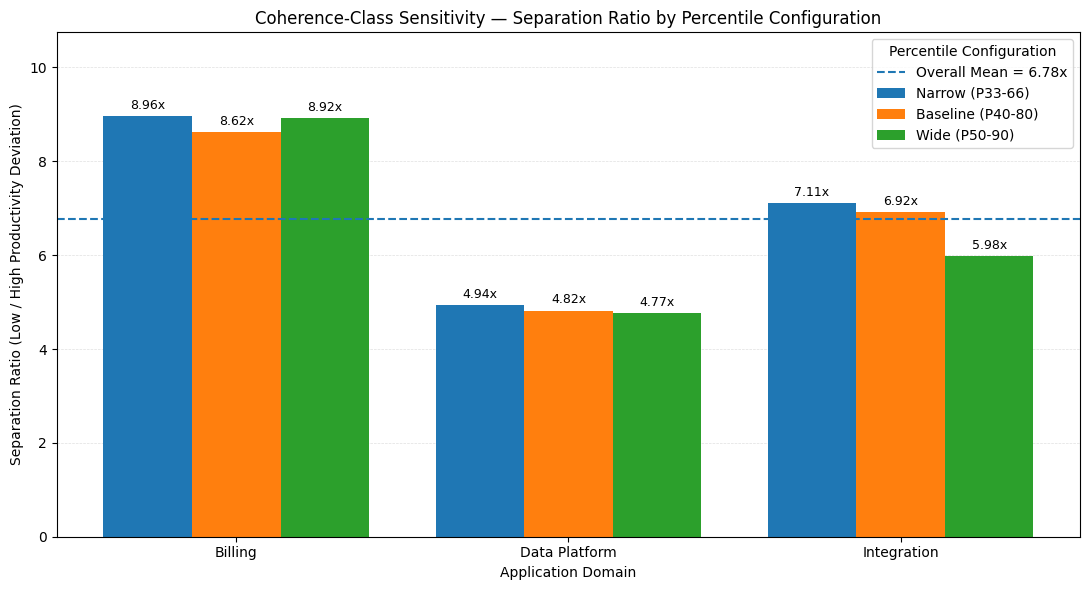

INFO | [U03] Sensitivity chart saved: /content/drive/MyDrive/_MyDrive/Colab Notebooks/Functional Structural Signature Model/quality/U03_sensitivity_separation_ratio.png
INFO | [U03] Overall mean Separation Ratio: 6.7807
INFO | [U03] Coherence-Class Percentile Sensitivity Analysis completed


In [62]:
# @title
# ============================================================
# U03 — COHERENCE-CLASS PERCENTILE SENSITIVITY ANALYSIS
# ============================================================
#
# Evaluates the sensitivity of the Coherence Class assignment
# to alternative percentile thresholds.
#
# Three configurations are compared:
#
# 1. Narrow   : P33 - P66
# 2. Baseline : P40 - P80
# 3. Wide     : P50 - P90
#
# For each application domain and configuration, the analysis
# calculates the mean productivity deviation associated with:
#
# - High Coherence
# - Medium Coherence
# - Low Coherence
#
# A Separation Ratio is then computed as:
#
#     Low-Coherence Deviation
#     -----------------------
#     High-Coherence Deviation
#
# The objective is to verify whether the discriminatory power
# of the coherence classification remains stable when the
# percentile thresholds are modified.
# ============================================================


# ------------------------------------------------------------
# Dependencies
# ------------------------------------------------------------

import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


logger.info(
    "[U03] Starting Coherence-Class Percentile "
    "Sensitivity Analysis"
)


# ------------------------------------------------------------
# Sensitivity configurations
# ------------------------------------------------------------

FILES_CONFIG = {
    "Narrow (P33-66)":
        "U03_TB_BASELINE_export (P33-66).csv",

    "Baseline (P40-80)":
        "U03_TB_BASELINE_export (P40-80).csv",

    "Wide (P50-90)":
        "U03_TB_BASELINE_export (P50-90).csv",
}


# ------------------------------------------------------------
# Required columns
# ------------------------------------------------------------

REQUIRED_COLUMNS = [
    "APPLICATION_DOMAIN",
    "CLASSE_COERENZA",
    "IFPUG_PROD_GREZZA_FP",
    "IFPUG_PROD_ATTESA_FP",
]


# ------------------------------------------------------------
# Output files
# ------------------------------------------------------------

OUTPUT_SUMMARY = os.path.join(
    QUALITY_DIR,
    "U03_sensitivity_analysis_summary.csv"
)

OUTPUT_CHART = os.path.join(
    QUALITY_DIR,
    "U03_sensitivity_separation_ratio.png"
)


# ------------------------------------------------------------
# Result container
# ------------------------------------------------------------

summary_rows = []


# ------------------------------------------------------------
# Utility — Productivity deviation
# ------------------------------------------------------------

def ensure_productivity_deviation(
    df
):
    """
    Ensure DEV_PROD is available.

    If the column is not present in the input dataset, it is
    reconstructed as the absolute relative deviation between
    observed and expected productivity.
    """

    if "DEV_PROD" in df.columns:

        return df


    expected = (
        df["IFPUG_PROD_ATTESA_FP"]
        .to_numpy(float)
    )

    observed = (
        df["IFPUG_PROD_GREZZA_FP"]
        .to_numpy(float)
    )


    deviation = np.divide(
        np.abs(
            observed
            - expected
        ),
        expected,
        out=np.full_like(
            expected,
            np.nan,
            dtype=float
        ),
        where=expected != 0
    )


    df = df.copy()

    df["DEV_PROD"] = (
        deviation
    )


    return df


# ------------------------------------------------------------
# Utility — Mean deviation by coherence class
# ------------------------------------------------------------

def mean_deviation_by_class(
    df_domain,
    class_keyword
):
    """
    Calculate mean DEV_PROD for a coherence class using
    case-insensitive keyword matching.
    """

    mask = (
        df_domain[
            "CLASSE_COERENZA"
        ]
        .astype(str)
        .str.contains(
            class_keyword,
            case=False,
            na=False
        )
    )


    values = (
        df_domain.loc[
            mask,
            "DEV_PROD"
        ]
    )


    if values.empty:

        return np.nan


    return float(
        values.mean()
    )


# ------------------------------------------------------------
# Process sensitivity configurations
# ------------------------------------------------------------

loaded_configurations = 0


for config_name, filename in FILES_CONFIG.items():

    file_path = os.path.join(
        QUALITY_DIR,
        filename
    )


    # --------------------------------------------------------
    # File validation
    # --------------------------------------------------------

    if not os.path.exists(
        file_path
    ):

        logger.warning(
            "[U03] Sensitivity file not found: %s",
            file_path
        )

        continue


    logger.info(
        "[U03] Loading configuration: %s",
        config_name
    )


    df_config = pd.read_csv(
        file_path,
        sep=";",
        decimal=",",
        encoding="utf-8"
    )


    loaded_configurations += 1


    # --------------------------------------------------------
    # Column validation
    # --------------------------------------------------------

    missing_columns = [
        column
        for column in REQUIRED_COLUMNS
        if (
            column not in df_config.columns
            and not (
                column in [
                    "IFPUG_PROD_GREZZA_FP",
                    "IFPUG_PROD_ATTESA_FP",
                ]
                and "DEV_PROD"
                in df_config.columns
            )
        )
    ]


    if missing_columns:

        raise ValueError(
            f"Configuration '{config_name}' "
            f"is missing required columns: "
            f"{missing_columns}"
        )


    # --------------------------------------------------------
    # Ensure DEV_PROD
    # --------------------------------------------------------

    if "DEV_PROD" not in df_config.columns:

        df_config = (
            ensure_productivity_deviation(
                df_config
            )
        )


    logger.info(
        "[U03] Configuration %s loaded: %d projects",
        config_name,
        len(df_config)
    )


    # --------------------------------------------------------
    # Domain-level analysis
    # --------------------------------------------------------

    domains = (
        df_config[
            "APPLICATION_DOMAIN"
        ]
        .dropna()
        .unique()
    )


    for domain in domains:

        df_domain = (
            df_config[
                df_config[
                    "APPLICATION_DOMAIN"
                ]
                == domain
            ]
            .copy()
        )


        # ----------------------------------------------------
        # Mean productivity deviation by coherence class
        # ----------------------------------------------------

        dev_high = (
            mean_deviation_by_class(
                df_domain,
                "Alta"
            )
        )

        dev_medium = (
            mean_deviation_by_class(
                df_domain,
                "Media"
            )
        )

        dev_low = (
            mean_deviation_by_class(
                df_domain,
                "Bassa"
            )
        )


        # ----------------------------------------------------
        # Separation Ratio
        # ----------------------------------------------------

        if (
            np.isfinite(dev_high)
            and dev_high > 0
            and np.isfinite(dev_low)
        ):

            separation_ratio = (
                dev_low
                / dev_high
            )

        else:

            separation_ratio = (
                np.nan
            )


        summary_rows.append(
            {
                "CONFIGURATION":
                    config_name,

                "APPLICATION_DOMAIN":
                    domain,

                "DEV_HIGH":
                    (
                        round(
                            dev_high,
                            4
                        )
                        if np.isfinite(dev_high)
                        else np.nan
                    ),

                "DEV_MEDIUM":
                    (
                        round(
                            dev_medium,
                            4
                        )
                        if np.isfinite(dev_medium)
                        else np.nan
                    ),

                "DEV_LOW":
                    (
                        round(
                            dev_low,
                            4
                        )
                        if np.isfinite(dev_low)
                        else np.nan
                    ),

                "SEPARATION_RATIO":
                    (
                        round(
                            separation_ratio,
                            4
                        )
                        if np.isfinite(
                            separation_ratio
                        )
                        else np.nan
                    ),
            }
        )


        logger.info(
            "[U03] %s | %s | "
            "High=%.4f | Medium=%.4f | Low=%.4f | "
            "Separation=%.2fx",
            config_name,
            domain,
            dev_high,
            dev_medium,
            dev_low,
            separation_ratio
        )


# ------------------------------------------------------------
# Global validation
# ------------------------------------------------------------

if loaded_configurations == 0:

    raise FileNotFoundError(
        "No sensitivity-analysis input files were found."
    )


if not summary_rows:

    raise RuntimeError(
        "Sensitivity analysis produced no results."
    )


# ------------------------------------------------------------
# Build summary table
# ------------------------------------------------------------

df_summary = pd.DataFrame(
    summary_rows
)


# ------------------------------------------------------------
# Export summary
# ------------------------------------------------------------

df_summary.to_csv(
    OUTPUT_SUMMARY,
    sep=";",
    index=False,
    encoding="utf-8",
    decimal=","
)


logger.info(
    "[U03] Sensitivity summary saved: %s",
    OUTPUT_SUMMARY
)


# ------------------------------------------------------------
# Notebook summary
# ------------------------------------------------------------

print(
    "\n"
    "============================================================"
)

print(
    " U03 — COHERENCE-CLASS PERCENTILE SENSITIVITY ANALYSIS"
)

print(
    "============================================================\n"
)

print(
    df_summary.to_string(
        index=False
    )
)


# ============================================================
# DIAGNOSTIC VISUALIZATION
# ============================================================


# ------------------------------------------------------------
# Separation Ratio by domain and configuration
# ------------------------------------------------------------

domain_list = list(
    df_summary[
        "APPLICATION_DOMAIN"
    ]
    .dropna()
    .unique()
)

configuration_list = list(
    FILES_CONFIG.keys()
)


fig, ax = plt.subplots(
    figsize=(11, 6)
)


x = np.arange(
    len(domain_list)
)

n_configurations = len(
    configuration_list
)

bar_width = (
    0.8
    / max(
        n_configurations,
        1
    )
)


for config_index, config_name in enumerate(
    configuration_list
):

    config_data = (
        df_summary[
            df_summary[
                "CONFIGURATION"
            ]
            == config_name
        ]
        .set_index(
            "APPLICATION_DOMAIN"
        )
        .reindex(
            domain_list
        )
    )


    ratios = (
        config_data[
            "SEPARATION_RATIO"
        ]
        .to_numpy(
            dtype=float
        )
    )


    offset = (
        config_index
        - (n_configurations - 1) / 2
    ) * bar_width


    bars = ax.bar(
        x + offset,
        ratios,
        width=bar_width,
        label=config_name
    )


    # --------------------------------------------------------
    # Bar labels
    # --------------------------------------------------------

    for bar, value in zip(
        bars,
        ratios
    ):

        if (
            np.isfinite(value)
            and value > 0
        ):

            ax.annotate(
                f"{value:.2f}x",
                (
                    bar.get_x()
                    + bar.get_width() / 2,
                    bar.get_height()
                ),
                ha="center",
                va="bottom",
                fontsize=9,
                xytext=(0, 3),
                textcoords="offset points"
            )


# ------------------------------------------------------------
# Overall mean Separation Ratio
# ------------------------------------------------------------

mean_ratio = (
    df_summary[
        "SEPARATION_RATIO"
    ]
    .mean()
)


if np.isfinite(
    mean_ratio
):

    ax.axhline(
        y=mean_ratio,
        linestyle="--",
        linewidth=1.5,
        label=(
            f"Overall Mean = "
            f"{mean_ratio:.2f}x"
        )
    )


# ------------------------------------------------------------
# Chart formatting
# ------------------------------------------------------------

ax.set_xticks(
    x
)

ax.set_xticklabels(
    domain_list
)

ax.set_xlabel(
    "Application Domain"
)

ax.set_ylabel(
    "Separation Ratio "
    "(Low / High Productivity Deviation)"
)

ax.set_title(
    "Coherence-Class Sensitivity — "
    "Separation Ratio by Percentile Configuration"
)

ax.yaxis.grid(
    True,
    linestyle="--",
    linewidth=0.5,
    alpha=0.4
)

ax.set_axisbelow(
    True
)


valid_ratios = (
    df_summary[
        "SEPARATION_RATIO"
    ]
    .dropna()
)


if not valid_ratios.empty:

    ax.set_ylim(
        0,
        max(
            valid_ratios.max()
            * 1.20,
            1.0
        )
    )


ax.legend(
    title="Percentile Configuration"
)

fig.tight_layout()


# ------------------------------------------------------------
# Save and display
# ------------------------------------------------------------

fig.savefig(
    OUTPUT_CHART,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


logger.info(
    "[U03] Sensitivity chart saved: %s",
    OUTPUT_CHART
)


# ------------------------------------------------------------
# Final diagnostic
# ------------------------------------------------------------

logger.info(
    "[U03] Overall mean Separation Ratio: %.4f",
    mean_ratio
)

logger.info(
    "[U03] Coherence-Class Percentile "
    "Sensitivity Analysis completed"
)

# U04 — OLS vs Gradient Boosting Generalization Analysis

This utility evaluates whether a non-linear model provides a meaningful predictive advantage over the linear baseline.

Two model architectures are compared:

Linear Baseline — Ordinary Least Squares (OLS)
Gradient Boosting Regressor (GBR)

For each application domain, both models are evaluated using 5-Fold Cross Validation, with predictive performance measured through the Mean Absolute Error (MAE).

The analysis compares both the average cross-validation error and its variability across folds, providing evidence about the models' out-of-sample generalization capability.

The objective is to determine whether the additional complexity of Gradient Boosting produces a significant reduction in prediction error or whether the simpler linear baseline already provides comparable or better generalization performance.

INFO | [U04] Starting OLS vs Gradient Boosting Generalization Analysis
INFO | [U04] Dataset loaded: 207 projects
INFO | [U04] Analysing domain: Billing
INFO | [U04] Domain Billing | OLS MAE=9.1116 ± 2.5861 | GBR MAE=12.6513 ± 4.6780 | GBR improvement=-38.85%
INFO | [U04] Analysing domain: Data Platform
INFO | [U04] Domain Data Platform | OLS MAE=7.8171 ± 3.0271 | GBR MAE=8.6646 ± 2.0402 | GBR improvement=-10.84%
INFO | [U04] Analysing domain: Integration
INFO | [U04] Domain Integration | OLS MAE=5.5785 ± 1.3641 | GBR MAE=5.2308 ± 2.4758 | GBR improvement=6.23%
INFO | [U04] Summary results saved: /content/drive/MyDrive/_MyDrive/Colab Notebooks/Functional Structural Signature Model/quality/U04_ols_vs_gradient_boosting_5cv.csv


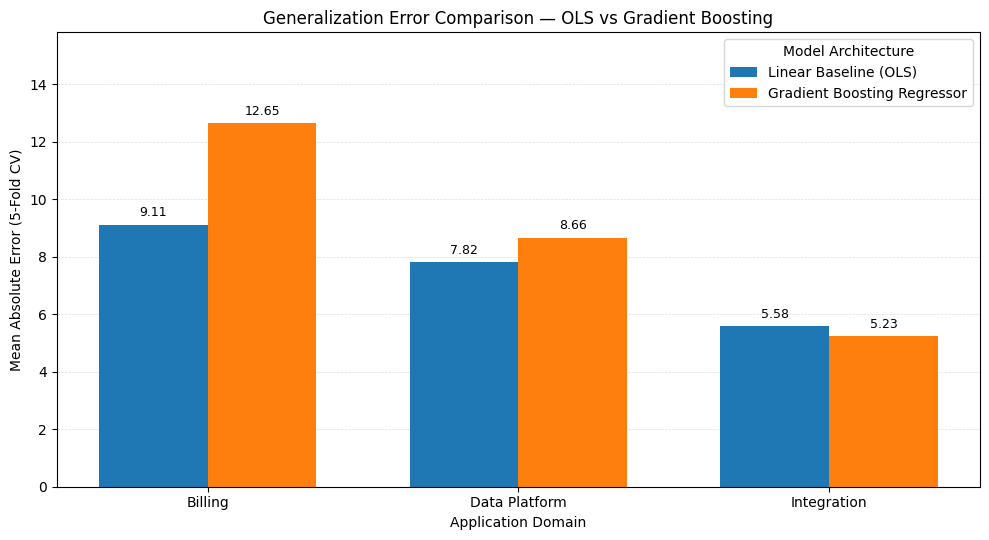

INFO | [U04] Comparative chart saved: /content/drive/MyDrive/_MyDrive/Colab Notebooks/Functional Structural Signature Model/quality/U04_ols_vs_gradient_boosting_5cv.png
INFO | [U04] OLS vs Gradient Boosting Generalization Analysis completed


In [80]:
# @title
# ============================================================
# U04 — OLS vs GRADIENT BOOSTING GENERALIZATION ANALYSIS
# ============================================================
#
# Compares the out-of-sample predictive performance of:
#
# 1. Linear Baseline Model (OLS)
# 2. Gradient Boosting Regressor
#
# using 5-Fold Cross Validation independently for each
# application domain.
#
# Performance is evaluated through Mean Absolute Error (MAE).
#
# The objective is to assess whether a non-linear model provides
# a meaningful generalization advantage over the linear baseline.
# ============================================================


# ------------------------------------------------------------
# Dependencies
# ------------------------------------------------------------

import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import KFold


logger.info(
    "[U04] Starting OLS vs Gradient Boosting "
    "Generalization Analysis"
)


# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

INPUT_FILENAME = "TB_BASELINE_export.csv"

INPUT_PATH = os.path.join(
    OUTPUT_DIR,
    INPUT_FILENAME
)

N_SPLITS = 5
RANDOM_STATE = 42


FEATURES = [
    "IFPUG_ILF",
    "IFPUG_EIF",
    "IFPUG_EI",
    "IFPUG_EQ",
    "IFPUG_EO",
]

TARGET = "FP_EFFORT"


OUTPUT_RESULTS = os.path.join(
    QUALITY_DIR,
    "U04_ols_vs_gradient_boosting_5cv.csv"
)

OUTPUT_CHART = os.path.join(
    QUALITY_DIR,
    "U04_ols_vs_gradient_boosting_5cv.png"
)


# ------------------------------------------------------------
# Load dataset
# ------------------------------------------------------------

if not os.path.exists(
    INPUT_PATH
):

    raise FileNotFoundError(
        f"Input dataset not found: {INPUT_PATH}"
    )


df = pd.read_csv(
    INPUT_PATH,
    sep=",",
    decimal=".",
    encoding="utf-8"
)


# ------------------------------------------------------------
# Input validation
# ------------------------------------------------------------

required_columns = [
    "APPLICATION_DOMAIN",
    TARGET,
    *FEATURES,
]


missing_columns = [
    column
    for column in required_columns
    if column not in df.columns
]


if missing_columns:

    raise ValueError(
        "Dataset is missing required columns: "
        f"{missing_columns}"
    )


if df.empty:

    raise ValueError(
        "Input dataset is empty."
    )


logger.info(
    "[U04] Dataset loaded: %d projects",
    len(df)
)


# ------------------------------------------------------------
# Cross-validation configuration
# ------------------------------------------------------------

kf = KFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE
)


# ------------------------------------------------------------
# Result containers
# ------------------------------------------------------------

summary_rows = []
fold_rows = []


# ------------------------------------------------------------
# Domain-level analysis
# ------------------------------------------------------------

domains = (
    df["APPLICATION_DOMAIN"]
    .dropna()
    .unique()
)


for domain in domains:

    logger.info(
        "[U04] Analysing domain: %s",
        domain
    )


    df_domain = (
        df[
            df["APPLICATION_DOMAIN"]
            == domain
        ]
        .copy()
    )


    # --------------------------------------------------------
    # Minimum sample validation
    # --------------------------------------------------------

    if len(df_domain) < N_SPLITS:

        logger.warning(
            "[U04] Domain %s skipped: "
            "projects=%d < folds=%d",
            domain,
            len(df_domain),
            N_SPLITS
        )

        continue


    X = (
        df_domain[FEATURES]
        .astype(float)
    )

    y = (
        df_domain[TARGET]
        .astype(float)
    )


    mae_ols = []
    mae_gbr = []


    # --------------------------------------------------------
    # 5-Fold Cross Validation
    # --------------------------------------------------------

    for fold_index, (
        train_idx,
        test_idx
    ) in enumerate(
        kf.split(X),
        start=1
    ):

        X_train = (
            X.iloc[
                train_idx
            ]
        )

        X_test = (
            X.iloc[
                test_idx
            ]
        )

        y_train = (
            y.iloc[
                train_idx
            ]
        )

        y_test = (
            y.iloc[
                test_idx
            ]
        )


        # ----------------------------------------------------
        # OLS
        # ----------------------------------------------------

        X_train_ols = sm.add_constant(
            X_train,
            has_constant="add"
        )

        X_test_ols = sm.add_constant(
            X_test,
            has_constant="add"
        )


        model_ols = sm.OLS(
            y_train,
            X_train_ols
        ).fit()


        y_pred_ols = (
            model_ols.predict(
                X_test_ols
            )
        )


        fold_mae_ols = (
            mean_absolute_error(
                y_test,
                y_pred_ols
            )
        )


        mae_ols.append(
            fold_mae_ols
        )


        # ----------------------------------------------------
        # Gradient Boosting Regressor
        # ----------------------------------------------------

        model_gbr = (
            GradientBoostingRegressor(
                n_estimators=30,
                max_depth=2,
                random_state=RANDOM_STATE
            )
        )


        model_gbr.fit(
            X_train,
            y_train
        )


        y_pred_gbr = (
            model_gbr.predict(
                X_test
            )
        )


        fold_mae_gbr = (
            mean_absolute_error(
                y_test,
                y_pred_gbr
            )
        )


        mae_gbr.append(
            fold_mae_gbr
        )


        # ----------------------------------------------------
        # Store fold-level metrics
        # ----------------------------------------------------

        fold_rows.append(
            {
                "APPLICATION_DOMAIN":
                    domain,

                "FOLD":
                    fold_index,

                "OLS_MAE":
                    round(
                        float(
                            fold_mae_ols
                        ),
                        4
                    ),

                "GBR_MAE":
                    round(
                        float(
                            fold_mae_gbr
                        ),
                        4
                    ),
            }
        )


    # --------------------------------------------------------
    # Aggregate metrics
    # --------------------------------------------------------

    mean_ols = float(
        np.mean(
            mae_ols
        )
    )

    std_ols = float(
        np.std(
            mae_ols,
            ddof=1
        )
    )

    mean_gbr = float(
        np.mean(
            mae_gbr
        )
    )

    std_gbr = float(
        np.std(
            mae_gbr,
            ddof=1
        )
    )


    improvement_pct = (
        (
            mean_ols
            - mean_gbr
        )
        / mean_ols
        * 100.0
        if mean_ols > 0
        else np.nan
    )


    summary_rows.append(
        {
            "APPLICATION_DOMAIN":
                domain,

            "OLS_MAE_MEAN":
                round(
                    mean_ols,
                    4
                ),

            "OLS_MAE_STD":
                round(
                    std_ols,
                    4
                ),

            "GBR_MAE_MEAN":
                round(
                    mean_gbr,
                    4
                ),

            "GBR_MAE_STD":
                round(
                    std_gbr,
                    4
                ),

            "GBR_IMPROVEMENT_PCT":
                (
                    round(
                        improvement_pct,
                        2
                    )
                    if np.isfinite(
                        improvement_pct
                    )
                    else np.nan
                ),
        }
    )


    logger.info(
        "[U04] Domain %s | "
        "OLS MAE=%.4f ± %.4f | "
        "GBR MAE=%.4f ± %.4f | "
        "GBR improvement=%.2f%%",
        domain,
        mean_ols,
        std_ols,
        mean_gbr,
        std_gbr,
        improvement_pct
    )


# ------------------------------------------------------------
# Build result tables
# ------------------------------------------------------------

df_summary = pd.DataFrame(
    summary_rows
)

df_folds = pd.DataFrame(
    fold_rows
)


if df_summary.empty:

    raise RuntimeError(
        "No domain produced valid cross-validation results."
    )


# ------------------------------------------------------------
# Export results
# ------------------------------------------------------------

df_summary.to_csv(
    OUTPUT_RESULTS,
    sep=";",
    index=False,
    encoding="utf-8",
    decimal=","
)


logger.info(
    "[U04] Summary results saved: %s",
    OUTPUT_RESULTS
)


# ============================================================
# DIAGNOSTIC VISUALIZATION
# ============================================================


# ------------------------------------------------------------
# Comparative MAE chart
# ------------------------------------------------------------

domain_list = list(
    df_summary[
        "APPLICATION_DOMAIN"
    ]
)

x = np.arange(
    len(
        domain_list
    )
)

bar_width = 0.35


fig, ax = plt.subplots(
    figsize=(10, 5.5)
)


bars_ols = ax.bar(
    x - bar_width / 2,
    df_summary[
        "OLS_MAE_MEAN"
    ],
    width=bar_width,
    label="Linear Baseline (OLS)"
)


bars_gbr = ax.bar(
    x + bar_width / 2,
    df_summary[
        "GBR_MAE_MEAN"
    ],
    width=bar_width,
    label="Gradient Boosting Regressor"
)


# ------------------------------------------------------------
# Bar labels
# ------------------------------------------------------------

for bars in [
    bars_ols,
    bars_gbr
]:

    for bar in bars:

        height = (
            bar.get_height()
        )


        if (
            np.isfinite(
                height
            )
            and height > 0
        ):

            ax.annotate(
                f"{height:.2f}",
                (
                    bar.get_x()
                    + bar.get_width() / 2,
                    height
                ),
                ha="center",
                va="bottom",
                fontsize=9,
                xytext=(0, 4),
                textcoords="offset points"
            )


# ------------------------------------------------------------
# Chart formatting
# ------------------------------------------------------------

ax.set_xticks(
    x
)

ax.set_xticklabels(
    domain_list
)

ax.set_xlabel(
    "Application Domain"
)

ax.set_ylabel(
    "Mean Absolute Error (5-Fold CV)"
)

ax.set_title(
    "Generalization Error Comparison — "
    "OLS vs Gradient Boosting"
)

ax.legend(
    title="Model Architecture"
)

ax.yaxis.grid(
    True,
    linestyle="--",
    linewidth=0.5,
    alpha=0.4
)

ax.set_axisbelow(
    True
)


max_mae = max(
    df_summary[
        "OLS_MAE_MEAN"
    ].max(),
    df_summary[
        "GBR_MAE_MEAN"
    ].max()
)


ax.set_ylim(
    0,
    max_mae * 1.25
)


fig.tight_layout()


# ------------------------------------------------------------
# Save and display
# ------------------------------------------------------------

fig.savefig(
    OUTPUT_CHART,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


logger.info(
    "[U04] Comparative chart saved: %s",
    OUTPUT_CHART
)


logger.info(
    "[U04] OLS vs Gradient Boosting "
    "Generalization Analysis completed"
)

# U05 — Goodness-of-Fit & Residual Diagnostics

This utility provides an integrated statistical assessment of the **baseline model quality and robustness**.

1. **Goodness-of-Fit:** Evaluates whether the baseline model explains a meaningful proportion of the observed effort variability through Adjusted R² and the F-statistic.

2. **Residual Diagnostics (KS + Wilcoxon):** Assesses the residual distribution and verifies whether prediction errors exhibit systematic location bias.

3. **Stability & Generalization:** Complements the VIF, Bootstrap, and 5-Fold Cross-Validation analyses performed by the previous utilities, providing an overall assessment of coefficient stability and out-of-sample predictive robustness.

The objective is to verify that the baseline model is **statistically adequate, residual-balanced, stable, and capable of robust generalization across application domains**.

INFO | [U05] Starting Goodness-of-Fit & Residual Diagnostics
INFO | [U05] Dataset loaded: 207 projects
INFO | [U05] Analysing domain: Billing
INFO | [U05] Domain Billing | N=62 | p=5 | Adj R2=0.9062 | F=118.7273 | KS p=0.6750 | Wilcoxon p=0.0056
INFO | [U05] Analysing domain: Data Platform
INFO | [U05] Domain Data Platform | N=67 | p=5 | Adj R2=0.7599 | F=42.5790 | KS p=0.2363 | Wilcoxon p=0.5740
INFO | [U05] Analysing domain: Integration
INFO | [U05] Domain Integration | N=78 | p=3 | Adj R2=0.8340 | F=129.6176 | KS p=0.2384 | Wilcoxon p=0.0009
INFO | [U05] Goodness-of-fit results saved: /content/drive/MyDrive/_MyDrive/Colab Notebooks/Functional Structural Signature Model/quality/U05_goodness_of_fit_residual_results.csv



 U05 — GOODNESS-OF-FIT & RESIDUAL DIAGNOSTICS

APPLICATION_DOMAIN  SAMPLE_SIZE_N  ACTIVE_PREDICTORS_P  CENTERED_R2  CENTERED_ADJ_R2  F_STATISTIC  F_P_VALUE  KS_STATISTIC  KS_P_VALUE  WILCOXON_STATISTIC  WILCOXON_P_VALUE  RESIDUAL_MEAN  RESIDUAL_STD
           Billing             62                    5       0.9124           0.9062     118.7273        0.0        0.0891      0.6750               581.0            0.0056        -3.1574       10.7419
     Data Platform             67                    5       0.7745           0.7599      42.5790        0.0        0.1237      0.2363              1049.0            0.5740         0.0453        9.1746
       Integration             78                    3       0.8383           0.8340     129.6176        0.0        0.1146      0.2384               876.0            0.0009        -1.6726        6.7423


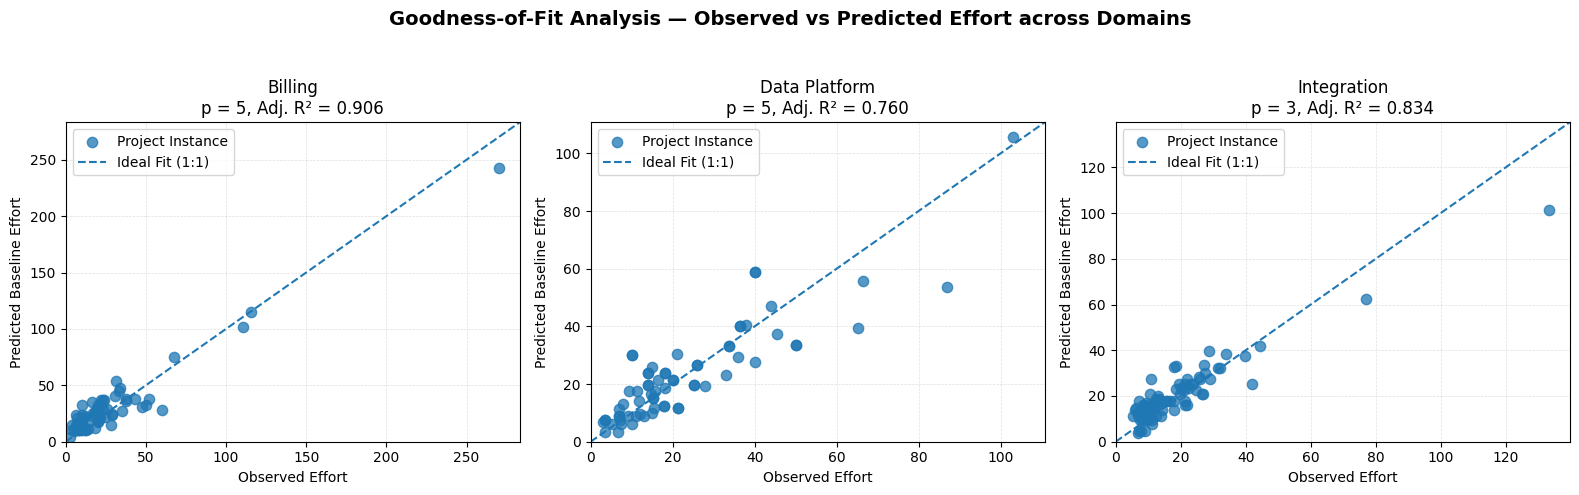

INFO | [U05] Goodness-of-fit chart saved: /content/drive/MyDrive/_MyDrive/Colab Notebooks/Functional Structural Signature Model/quality/U05_goodness_of_fit_observed_vs_predicted.png
INFO | [U05] Goodness-of-Fit & Residual Diagnostics completed


In [82]:
# @title
# ============================================================
# U05 — GOODNESS-OF-FIT & RESIDUAL DIAGNOSTICS
# ============================================================
#
# Evaluates the goodness-of-fit of the baseline effort model
# independently for each application domain.
#
# The analysis includes:
#
# 1. Centered Adjusted R²
# 2. F-statistic and associated p-value
# 3. Kolmogorov-Smirnov residual distribution test
# 4. Wilcoxon signed-rank residual test
# 5. Observed vs Predicted effort visualization
#
# The objective is to assess the explanatory capability of the
# baseline model and identify potential systematic residual
# deviations or poor domain-level fit.
# ============================================================


# ------------------------------------------------------------
# Dependencies
# ------------------------------------------------------------

import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from scipy import stats


logger.info(
    "[U05] Starting Goodness-of-Fit "
    "& Residual Diagnostics"
)


# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

INPUT_FILENAME = "TB_BASELINE_export.csv"

INPUT_PATH = os.path.join(
    OUTPUT_DIR,
    INPUT_FILENAME
)

FEATURES = [
    "IFPUG_ILF",
    "IFPUG_EIF",
    "IFPUG_EI",
    "IFPUG_EQ",
    "IFPUG_EO",
]

TARGET = "FP_EFFORT"

VARIANCE_EPS = 1e-6


# ------------------------------------------------------------
# Output files
# ------------------------------------------------------------

OUTPUT_RESULTS = os.path.join(
    QUALITY_DIR,
    "U05_goodness_of_fit_residual_results.csv"
)

OUTPUT_CHART = os.path.join(
    QUALITY_DIR,
    "U05_goodness_of_fit_observed_vs_predicted.png"
)


# ------------------------------------------------------------
# Load dataset
# ------------------------------------------------------------

if not os.path.exists(
    INPUT_PATH
):

    raise FileNotFoundError(
        f"Input dataset not found: {INPUT_PATH}"
    )


df = pd.read_csv(
    INPUT_PATH,
    sep=",",
    decimal=".",
    encoding="utf-8"
)


logger.info(
    "[U05] Dataset loaded: %d projects",
    len(df)
)


# ------------------------------------------------------------
# Input validation
# ------------------------------------------------------------

required_columns = [
    "APPLICATION_DOMAIN",
    TARGET,
    *FEATURES,
]


missing_columns = [
    column
    for column in required_columns
    if column not in df.columns
]


if missing_columns:

    raise ValueError(
        "Dataset is missing required columns: "
        f"{missing_columns}"
    )


if df.empty:

    raise ValueError(
        "Input dataset is empty."
    )


# ------------------------------------------------------------
# Result containers
# ------------------------------------------------------------

results = []
domain_data = {}


# ------------------------------------------------------------
# Domain-level analysis
# ------------------------------------------------------------

domains = (
    df["APPLICATION_DOMAIN"]
    .dropna()
    .unique()
)


for domain in domains:

    logger.info(
        "[U05] Analysing domain: %s",
        domain
    )


    df_domain = (
        df[
            df["APPLICATION_DOMAIN"]
            == domain
        ]
        .copy()
    )


    n_obs = len(
        df_domain
    )


    # --------------------------------------------------------
    # Observed effort
    # --------------------------------------------------------

    y_obs = (
        df_domain[TARGET]
        .to_numpy(float)
    )


    # --------------------------------------------------------
    # Functional component matrix
    # --------------------------------------------------------

    counts = (
        df_domain[FEATURES]
        .fillna(0)
        .to_numpy(dtype=float)
    )


    # --------------------------------------------------------
    # Active predictors
    # --------------------------------------------------------

    valid_mask = (
        np.std(
            counts,
            axis=0
        )
        > VARIANCE_EPS
    )


    X_valid = (
        counts[
            :,
            valid_mask
        ]
    )


    p_vars = (
        X_valid.shape[1]
    )


    if p_vars == 0:

        logger.warning(
            "[U05] Domain %s skipped: "
            "no active predictors",
            domain
        )

        continue


    if n_obs <= p_vars:

        logger.warning(
            "[U05] Domain %s has insufficient degrees "
            "of freedom: N=%d, p=%d",
            domain,
            n_obs,
            p_vars
        )


    # --------------------------------------------------------
    # OLS estimation — no intercept
    # --------------------------------------------------------

    beta, _, _, _ = (
        np.linalg.lstsq(
            X_valid,
            y_obs,
            rcond=None
        )
    )


    y_pred = (
        X_valid
        @ beta
    )


    residuals = (
        y_obs
        - y_pred
    )


    # --------------------------------------------------------
    # Centered R² and Adjusted R²
    # --------------------------------------------------------

    ss_res = np.sum(
        residuals ** 2
    )


    ss_tot_centered = np.sum(
        (
            y_obs
            - np.mean(y_obs)
        ) ** 2
    )


    r2_centered = (
        1.0
        - ss_res / ss_tot_centered
        if ss_tot_centered != 0
        else 0.0
    )


    adj_r2_centered = (
        1.0
        - (1.0 - r2_centered)
        * (n_obs - 1)
        / (n_obs - p_vars)
        if n_obs > p_vars
        else r2_centered
    )


    # --------------------------------------------------------
    # F-statistic
    # --------------------------------------------------------

    if (
        p_vars > 0
        and n_obs > p_vars
    ):

        ms_reg = (
            ss_tot_centered
            - ss_res
        ) / p_vars


        ms_res = (
            ss_res
            / (n_obs - p_vars)
        )


        if ms_res > 0:

            f_stat = (
                ms_reg
                / ms_res
            )


            f_pvalue = (
                stats.f.sf(
                    f_stat,
                    p_vars,
                    n_obs - p_vars
                )
            )

        else:

            f_stat = np.nan
            f_pvalue = np.nan

    else:

        f_stat = np.nan
        f_pvalue = np.nan


    # --------------------------------------------------------
    # Residual diagnostics
    # --------------------------------------------------------

    residual_std = np.std(
        residuals,
        ddof=1
    )


    # Kolmogorov-Smirnov test
    if (
        np.isfinite(residual_std)
        and residual_std > 0
    ):

        ks_stat, ks_pvalue = (
            stats.kstest(
                residuals,
                "norm",
                args=(
                    np.mean(residuals),
                    residual_std
                )
            )
        )

    else:

        ks_stat = np.nan
        ks_pvalue = np.nan


    # Wilcoxon signed-rank test
    try:

        w_stat, w_pvalue = (
            stats.wilcoxon(
                residuals
            )
        )

    except ValueError:

        w_stat = np.nan
        w_pvalue = np.nan


    # --------------------------------------------------------
    # Store results
    # --------------------------------------------------------

    results.append(
        {
            "APPLICATION_DOMAIN":
                domain,

            "SAMPLE_SIZE_N":
                n_obs,

            "ACTIVE_PREDICTORS_P":
                p_vars,

            "CENTERED_R2":
                round(
                    float(r2_centered),
                    4
                ),

            "CENTERED_ADJ_R2":
                round(
                    float(adj_r2_centered),
                    4
                ),

            "F_STATISTIC":
                (
                    round(
                        float(f_stat),
                        4
                    )
                    if np.isfinite(f_stat)
                    else np.nan
                ),

            "F_P_VALUE":
                (
                    round(
                        float(f_pvalue),
                        6
                    )
                    if np.isfinite(f_pvalue)
                    else np.nan
                ),

            "KS_STATISTIC":
                (
                    round(
                        float(ks_stat),
                        4
                    )
                    if np.isfinite(ks_stat)
                    else np.nan
                ),

            "KS_P_VALUE":
                (
                    round(
                        float(ks_pvalue),
                        4
                    )
                    if np.isfinite(ks_pvalue)
                    else np.nan
                ),

            "WILCOXON_STATISTIC":
                (
                    round(
                        float(w_stat),
                        4
                    )
                    if np.isfinite(w_stat)
                    else np.nan
                ),

            "WILCOXON_P_VALUE":
                (
                    round(
                        float(w_pvalue),
                        4
                    )
                    if np.isfinite(w_pvalue)
                    else np.nan
                ),

            "RESIDUAL_MEAN":
                round(
                    float(
                        np.mean(residuals)
                    ),
                    4
                ),

            "RESIDUAL_STD":
                round(
                    float(residual_std),
                    4
                ),
        }
    )


    # --------------------------------------------------------
    # Store visualization data
    # --------------------------------------------------------

    domain_data[
        domain
    ] = {
        "y_obs":
            y_obs,

        "y_pred":
            y_pred,

        "residuals":
            residuals,

        "p_vars":
            p_vars,

        "adj_r2":
            adj_r2_centered,
    }


    logger.info(
        "[U05] Domain %s | N=%d | p=%d | "
        "Adj R2=%.4f | F=%.4f | "
        "KS p=%.4f | Wilcoxon p=%.4f",
        domain,
        n_obs,
        p_vars,
        adj_r2_centered,
        f_stat,
        ks_pvalue,
        w_pvalue
    )


# ------------------------------------------------------------
# Build result table
# ------------------------------------------------------------

res_df = pd.DataFrame(
    results
)


if res_df.empty:

    raise RuntimeError(
        "Goodness-of-fit analysis produced no valid results."
    )


# ------------------------------------------------------------
# Notebook summary
# ------------------------------------------------------------

print(
    "\n"
    "============================================================"
)

print(
    " U05 — GOODNESS-OF-FIT & RESIDUAL DIAGNOSTICS"
)

print(
    "============================================================\n"
)

print(
    res_df.to_string(
        index=False
    )
)


# ------------------------------------------------------------
# Export CSV
# ------------------------------------------------------------

res_df.to_csv(
    OUTPUT_RESULTS,
    sep=";",
    decimal=",",
    index=False,
    encoding="utf-8"
)


logger.info(
    "[U05] Goodness-of-fit results saved: %s",
    OUTPUT_RESULTS
)


# ============================================================
# DIAGNOSTIC VISUALIZATION
# ============================================================


# ------------------------------------------------------------
# Observed vs Predicted Effort
# ------------------------------------------------------------

valid_domains = list(
    domain_data.keys()
)

n_domains = len(
    valid_domains
)


fig, axes = plt.subplots(
    1,
    n_domains,
    figsize=(
        5.3 * n_domains,
        5
    ),
    squeeze=False
)


axes = axes.flatten()


for index, domain in enumerate(
    valid_domains
):

    y_obs = (
        domain_data[
            domain
        ]["y_obs"]
    )

    y_pred = (
        domain_data[
            domain
        ]["y_pred"]
    )

    p_num = (
        domain_data[
            domain
        ]["p_vars"]
    )

    adj_r2 = (
        domain_data[
            domain
        ]["adj_r2"]
    )


    ax = (
        axes[index]
    )


    ax.scatter(
        y_obs,
        y_pred,
        alpha=0.75,
        s=55,
        label="Project Instance"
    )


    # --------------------------------------------------------
    # Ideal 1:1 reference
    # --------------------------------------------------------

    min_value = min(
        np.min(y_obs),
        np.min(y_pred)
    )

    max_value = max(
        np.max(y_obs),
        np.max(y_pred)
    )


    padding = (
        (max_value - min_value)
        * 0.05
    )


    lower_limit = max(
        0,
        min_value - padding
    )

    upper_limit = (
        max_value
        + padding
    )


    ax.plot(
        [
            lower_limit,
            upper_limit
        ],
        [
            lower_limit,
            upper_limit
        ],
        linestyle="--",
        linewidth=1.5,
        label="Ideal Fit (1:1)"
    )


    # --------------------------------------------------------
    # Panel formatting
    # --------------------------------------------------------

    ax.set_title(
        f"{domain}\n"
        f"p = {p_num}, "
        f"Adj. R² = {adj_r2:.3f}"
    )

    ax.set_xlabel(
        "Observed Effort"
    )

    ax.set_ylabel(
        "Predicted Baseline Effort"
    )

    ax.set_xlim(
        lower_limit,
        upper_limit
    )

    ax.set_ylim(
        lower_limit,
        upper_limit
    )

    ax.grid(
        True,
        linestyle="--",
        linewidth=0.5,
        alpha=0.4
    )

    ax.set_axisbelow(
        True
    )

    ax.legend(
        loc="upper left"
    )


fig.suptitle(
    "Goodness-of-Fit Analysis — "
    "Observed vs Predicted Effort across Domains",
    fontsize=14,
    fontweight="bold"
)


fig.tight_layout(
    rect=[
        0,
        0,
        1,
        0.94
    ]
)


# ------------------------------------------------------------
# Save and display
# ------------------------------------------------------------

fig.savefig(
    OUTPUT_CHART,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


logger.info(
    "[U05] Goodness-of-fit chart saved: %s",
    OUTPUT_CHART
)


logger.info(
    "[U05] Goodness-of-Fit "
    "& Residual Diagnostics completed"
)

# U06 — Statistical Separation & Outlier Validation

INFO | [U06] Starting Statistical Separation & Outlier Validation
INFO | [U06] Dataset loaded: 207 projects
INFO | [U06] Analysing domain: Billing
INFO | [U06] Domain Billing | Consistent=37 | Outlier=25 | MWU distance p=0.000023 | MWU productivity p=0.532477 | Silhouette=0.2222
INFO | [U06] Analysing domain: Data Platform
INFO | [U06] Domain Data Platform | Consistent=43 | Outlier=24 | MWU distance p=0.000054 | MWU productivity p=0.508944 | Silhouette=0.2142
INFO | [U06] Analysing domain: Integration
INFO | [U06] Domain Integration | Consistent=53 | Outlier=25 | MWU distance p=0.001107 | MWU productivity p=0.863976 | Silhouette=0.2851
INFO | [U06] Results saved: /content/drive/MyDrive/_MyDrive/Colab Notebooks/Functional Structural Signature Model/quality/U06_separation_metrics_results.csv
/tmp/ipykernel_489/3424571772.py:674: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped i


 U06 — STATISTICAL SEPARATION & OUTLIER VALIDATION

APPLICATION_DOMAIN  N_CONSISTENT  N_OUTLIER  MEDIAN_DISTANCE_CONSISTENT  MEDIAN_DISTANCE_OUTLIER  DISTANCE_MEDIAN_RATIO  MWU_STAT_DIST  MWU_PVAL_DIST  MWU_STAT_PROD  MWU_PVAL_PROD  SILHOUETTE_SCORE
           Billing            37         25                      0.2290                   0.4264                 1.8619          167.5       0.000023          418.5       0.532477            0.2222
     Data Platform            43         24                      0.1960                   0.6128                 3.1260          207.0       0.000054          465.0       0.508944            0.2142
       Integration            53         25                      0.1143                   0.2431                 2.1268          358.0       0.001107          646.0       0.863976            0.2851


/tmp/ipykernel_489/3424571772.py:674: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(
/tmp/ipykernel_489/3424571772.py:674: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


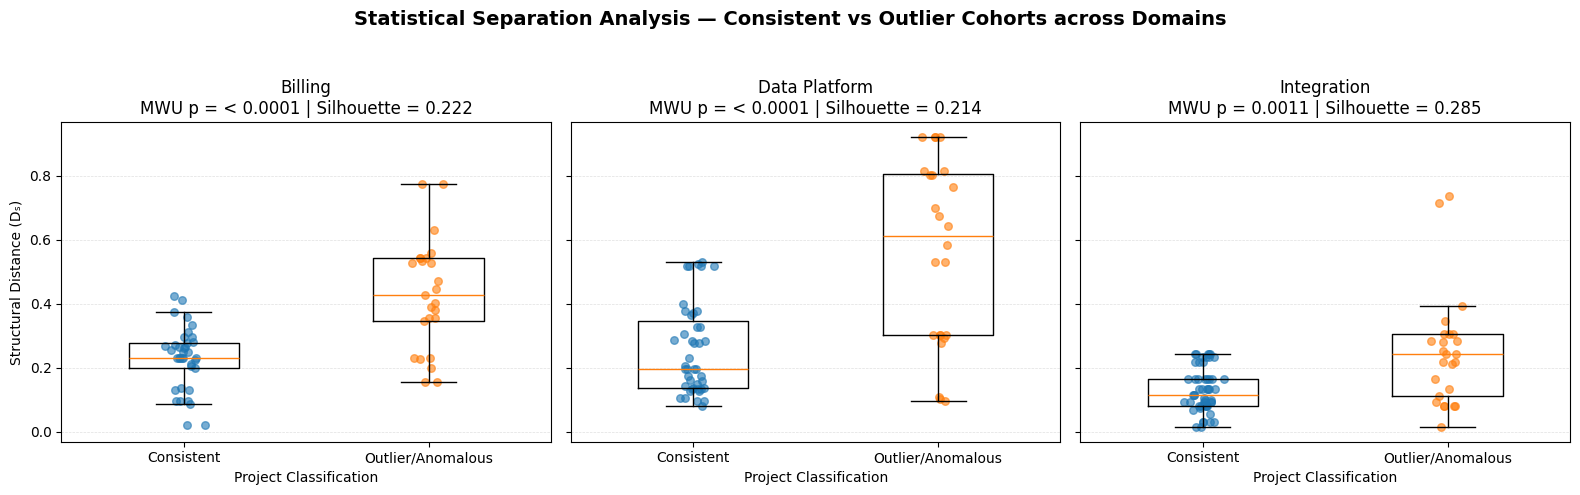

INFO | [U06] Separation chart saved: /content/drive/MyDrive/_MyDrive/Colab Notebooks/Functional Structural Signature Model/quality/U06_structural_distance_separation.png
INFO | [U06] Statistical Separation & Outlier Validation completed


In [83]:
# @title
# ============================================================
# U06 — STATISTICAL SEPARATION & OUTLIER VALIDATION
# ============================================================
#
# Evaluates whether projects classified as structurally
# consistent are statistically distinguishable from projects
# classified as low-coherence / anomalous.
#
# The analysis includes:
#
# 1. Mann-Whitney U test on Structural Distance
# 2. Mann-Whitney U test on observed productivity
# 3. Silhouette Score in the joint space:
#       Structural Distance × Observed Productivity
# 4. Domain-level visualization of structural separation
#
# High- and Medium-Coherence projects are grouped as
# "Consistent", while Low-Coherence projects are classified
# as "Outlier/Anomalous".
#
# The objective is to assess whether the coherence classification
# identifies statistically distinct project populations.
# ============================================================


# ------------------------------------------------------------
# Dependencies
# ------------------------------------------------------------

import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from scipy import stats
from sklearn.metrics import silhouette_score


logger.info(
    "[U06] Starting Statistical Separation "
    "& Outlier Validation"
)


# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

INPUT_FILENAME = "TB_BASELINE_export.csv"

INPUT_PATH = os.path.join(
    OUTPUT_DIR,
    INPUT_FILENAME
)

REQUIRED_COLUMNS = [
    "APPLICATION_DOMAIN",
    "CLASSE_COERENZA",
    "DIST_STRUTTURALE",
    "IFPUG_PROD_GREZZA_FP",
]


# ------------------------------------------------------------
# Output files
# ------------------------------------------------------------

OUTPUT_RESULTS = os.path.join(
    QUALITY_DIR,
    "U06_separation_metrics_results.csv"
)

OUTPUT_CHART = os.path.join(
    QUALITY_DIR,
    "U06_structural_distance_separation.png"
)


# ------------------------------------------------------------
# Load dataset
# ------------------------------------------------------------

if not os.path.exists(INPUT_PATH):

    raise FileNotFoundError(
        f"Input dataset not found: {INPUT_PATH}"
    )


df = pd.read_csv(
    INPUT_PATH,
    sep=",",
    decimal=".",
    encoding="utf-8"
)


logger.info(
    "[U06] Dataset loaded: %d projects",
    len(df)
)


# ------------------------------------------------------------
# Input validation
# ------------------------------------------------------------

missing_columns = [
    column
    for column in REQUIRED_COLUMNS
    if column not in df.columns
]


if missing_columns:

    raise ValueError(
        "Dataset is missing required columns: "
        f"{missing_columns}"
    )


if df.empty:

    raise ValueError(
        "Input dataset is empty."
    )


# ------------------------------------------------------------
# Utility — Coherence grouping
# ------------------------------------------------------------

def classify_coherence_group(value):
    """
    Aggregate High- and Medium-Coherence projects into the
    Consistent cohort and Low-Coherence projects into the
    Outlier/Anomalous cohort.

    Matching is case-insensitive and supports both Italian
    and English coherence labels.
    """

    value = str(value).strip().lower()

    if (
        "alta" in value
        or "high" in value
        or "media" in value
        or "medium" in value
    ):

        return "Consistent"


    if (
        "bassa" in value
        or "low" in value
    ):

        return "Outlier/Anomalous"


    return np.nan


# ------------------------------------------------------------
# Apply classification
# ------------------------------------------------------------

df["GROUP"] = (
    df["CLASSE_COERENZA"]
    .apply(classify_coherence_group)
)


unclassified = int(
    df["GROUP"].isna().sum()
)


if unclassified > 0:

    logger.warning(
        "[U06] %d projects could not be mapped to a "
        "coherence group and will be excluded.",
        unclassified
    )


# ------------------------------------------------------------
# Result container
# ------------------------------------------------------------

results = []


# ------------------------------------------------------------
# Domain-level analysis
# ------------------------------------------------------------

domains = (
    df["APPLICATION_DOMAIN"]
    .dropna()
    .unique()
)


for domain in domains:

    logger.info(
        "[U06] Analysing domain: %s",
        domain
    )


    df_domain = (
        df[
            df["APPLICATION_DOMAIN"]
            == domain
        ]
        .copy()
    )


    consistent_mask = (
        df_domain["GROUP"]
        == "Consistent"
    )

    outlier_mask = (
        df_domain["GROUP"]
        == "Outlier/Anomalous"
    )


    # --------------------------------------------------------
    # Structural Distance groups
    # --------------------------------------------------------

    consistent_distance = (
        df_domain.loc[
            consistent_mask,
            "DIST_STRUTTURALE"
        ]
        .dropna()
        .astype(float)
    )

    outlier_distance = (
        df_domain.loc[
            outlier_mask,
            "DIST_STRUTTURALE"
        ]
        .dropna()
        .astype(float)
    )


    # --------------------------------------------------------
    # Productivity groups
    # --------------------------------------------------------

    consistent_productivity = (
        df_domain.loc[
            consistent_mask,
            "IFPUG_PROD_GREZZA_FP"
        ]
        .dropna()
        .astype(float)
    )

    outlier_productivity = (
        df_domain.loc[
            outlier_mask,
            "IFPUG_PROD_GREZZA_FP"
        ]
        .dropna()
        .astype(float)
    )


    # --------------------------------------------------------
    # Mann-Whitney U — Structural Distance
    # --------------------------------------------------------

    if (
        len(consistent_distance) > 0
        and len(outlier_distance) > 0
    ):

        stat_distance, pvalue_distance = (
            stats.mannwhitneyu(
                consistent_distance,
                outlier_distance,
                alternative="two-sided"
            )
        )

    else:

        stat_distance = np.nan
        pvalue_distance = np.nan


    # --------------------------------------------------------
    # Mann-Whitney U — Productivity
    # --------------------------------------------------------

    if (
        len(consistent_productivity) > 0
        and len(outlier_productivity) > 0
    ):

        stat_productivity, pvalue_productivity = (
            stats.mannwhitneyu(
                consistent_productivity,
                outlier_productivity,
                alternative="two-sided"
            )
        )

    else:

        stat_productivity = np.nan
        pvalue_productivity = np.nan


    # --------------------------------------------------------
    # Silhouette Score
    # --------------------------------------------------------

    silhouette_data = (
        df_domain[
            [
                "DIST_STRUTTURALE",
                "IFPUG_PROD_GREZZA_FP",
                "GROUP",
            ]
        ]
        .dropna()
        .copy()
    )


    labels = (
        silhouette_data["GROUP"]
    )


    X_silhouette = (
        silhouette_data[
            [
                "DIST_STRUTTURALE",
                "IFPUG_PROD_GREZZA_FP",
            ]
        ]
        .to_numpy(float)
    )


    n_silhouette_samples = len(
        X_silhouette
    )

    n_groups = (
        labels.nunique()
    )


    if (
        n_groups > 1
        and n_silhouette_samples > n_groups
    ):

        silhouette = (
            silhouette_score(
                X_silhouette,
                labels
            )
        )

    else:

        silhouette = np.nan


    # --------------------------------------------------------
    # Descriptive separation metrics
    # --------------------------------------------------------

    median_consistent_distance = (
        float(
            consistent_distance.median()
        )
        if len(consistent_distance) > 0
        else np.nan
    )


    median_outlier_distance = (
        float(
            outlier_distance.median()
        )
        if len(outlier_distance) > 0
        else np.nan
    )


    distance_median_ratio = (
        median_outlier_distance
        / median_consistent_distance
        if (
            np.isfinite(
                median_consistent_distance
            )
            and median_consistent_distance > 0
            and np.isfinite(
                median_outlier_distance
            )
        )
        else np.nan
    )


    # --------------------------------------------------------
    # Store results
    # --------------------------------------------------------

    results.append(
        {
            "APPLICATION_DOMAIN":
                domain,

            "N_CONSISTENT":
                len(consistent_distance),

            "N_OUTLIER":
                len(outlier_distance),

            "MEDIAN_DISTANCE_CONSISTENT":
                round(
                    median_consistent_distance,
                    4
                )
                if np.isfinite(
                    median_consistent_distance
                )
                else np.nan,

            "MEDIAN_DISTANCE_OUTLIER":
                round(
                    median_outlier_distance,
                    4
                )
                if np.isfinite(
                    median_outlier_distance
                )
                else np.nan,

            "DISTANCE_MEDIAN_RATIO":
                round(
                    distance_median_ratio,
                    4
                )
                if np.isfinite(
                    distance_median_ratio
                )
                else np.nan,

            "MWU_STAT_DIST":
                round(
                    float(stat_distance),
                    4
                )
                if np.isfinite(
                    stat_distance
                )
                else np.nan,

            "MWU_PVAL_DIST":
                round(
                    float(pvalue_distance),
                    6
                )
                if np.isfinite(
                    pvalue_distance
                )
                else np.nan,

            "MWU_STAT_PROD":
                round(
                    float(stat_productivity),
                    4
                )
                if np.isfinite(
                    stat_productivity
                )
                else np.nan,

            "MWU_PVAL_PROD":
                round(
                    float(pvalue_productivity),
                    6
                )
                if np.isfinite(
                    pvalue_productivity
                )
                else np.nan,

            "SILHOUETTE_SCORE":
                round(
                    float(silhouette),
                    4
                )
                if np.isfinite(
                    silhouette
                )
                else np.nan,
        }
    )


    logger.info(
        "[U06] Domain %s | "
        "Consistent=%d | Outlier=%d | "
        "MWU distance p=%.6f | "
        "MWU productivity p=%.6f | "
        "Silhouette=%.4f",
        domain,
        len(consistent_distance),
        len(outlier_distance),
        pvalue_distance,
        pvalue_productivity,
        silhouette
    )


# ------------------------------------------------------------
# Build results table
# ------------------------------------------------------------

df_results = pd.DataFrame(
    results
)


if df_results.empty:

    raise RuntimeError(
        "Separation analysis produced no valid results."
    )


# ------------------------------------------------------------
# Export CSV
# ------------------------------------------------------------

df_results.to_csv(
    OUTPUT_RESULTS,
    sep=";",
    decimal=",",
    index=False,
    encoding="utf-8"
)


# ------------------------------------------------------------
# Notebook summary
# ------------------------------------------------------------

print(
    "\n"
    "============================================================"
)

print(
    " U06 — STATISTICAL SEPARATION & OUTLIER VALIDATION"
)

print(
    "============================================================\n"
)

print(
    df_results.to_string(
        index=False
    )
)


logger.info(
    "[U06] Results saved: %s",
    OUTPUT_RESULTS
)


# ============================================================
# DIAGNOSTIC VISUALIZATION
# ============================================================


# ------------------------------------------------------------
# Structural Distance separation
# ------------------------------------------------------------

valid_domains = list(
    domains
)

n_domains = len(
    valid_domains
)


fig, axes = plt.subplots(
    1,
    n_domains,
    figsize=(
        5.3 * n_domains,
        5
    ),
    sharey=True,
    squeeze=False
)


axes = axes.flatten()


for index, domain in enumerate(
    valid_domains
):

    df_domain = (
        df[
            df["APPLICATION_DOMAIN"]
            == domain
        ]
        .dropna(
            subset=[
                "GROUP",
                "DIST_STRUTTURALE"
            ]
        )
        .copy()
    )


    ax = axes[index]


    groups = [
        "Consistent",
        "Outlier/Anomalous",
    ]


    plot_values = [
        df_domain.loc[
            df_domain["GROUP"] == group,
            "DIST_STRUTTURALE"
        ].to_numpy(float)
        for group in groups
    ]


    # --------------------------------------------------------
    # Boxplot
    # --------------------------------------------------------

    ax.boxplot(
        plot_values,
        labels=groups,
        widths=0.45,
        showfliers=False
    )


    # --------------------------------------------------------
    # Individual project observations
    # --------------------------------------------------------

    rng = np.random.default_rng(
        42
    )


    for group_index, values in enumerate(
        plot_values,
        start=1
    ):

        if len(values) == 0:

            continue


        jitter = rng.normal(
            0,
            0.04,
            size=len(values)
        )


        ax.scatter(
            np.full(
                len(values),
                group_index
            )
            + jitter,
            values,
            alpha=0.6,
            s=30
        )


    # --------------------------------------------------------
    # Statistical annotations
    # --------------------------------------------------------

    result_row = (
        df_results[
            df_results[
                "APPLICATION_DOMAIN"
            ]
            == domain
        ]
        .iloc[0]
    )


    pvalue = (
        result_row[
            "MWU_PVAL_DIST"
        ]
    )

    silhouette = (
        result_row[
            "SILHOUETTE_SCORE"
        ]
    )


    pvalue_text = (
        f"{pvalue:.4f}"
        if (
            pd.notna(pvalue)
            and pvalue >= 0.0001
        )
        else (
            "< 0.0001"
            if pd.notna(pvalue)
            else "N/A"
        )
    )


    silhouette_text = (
        f"{silhouette:.3f}"
        if pd.notna(
            silhouette
        )
        else "N/A"
    )


    ax.set_title(
        f"{domain}\n"
        f"MWU p = {pvalue_text} | "
        f"Silhouette = {silhouette_text}"
    )


    ax.set_xlabel(
        "Project Classification"
    )


    if index == 0:

        ax.set_ylabel(
            "Structural Distance (Dₛ)"
        )

    else:

        ax.set_ylabel(
            ""
        )


    ax.yaxis.grid(
        True,
        linestyle="--",
        linewidth=0.5,
        alpha=0.4
    )

    ax.set_axisbelow(
        True
    )


fig.suptitle(
    "Statistical Separation Analysis — "
    "Consistent vs Outlier Cohorts across Domains",
    fontsize=14,
    fontweight="bold"
)


fig.tight_layout(
    rect=[
        0,
        0,
        1,
        0.94
    ]
)


# ------------------------------------------------------------
# Save and display
# ------------------------------------------------------------

fig.savefig(
    OUTPUT_CHART,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


logger.info(
    "[U06] Separation chart saved: %s",
    OUTPUT_CHART
)


logger.info(
    "[U06] Statistical Separation "
    "& Outlier Validation completed"
)

# [OPTIONAL EXPERIMENT] Structural Clustering with K-Means (TO BE CHECK)

This optional experiment applies K-Means clustering to baseline projects using
their normalized functional structural indices.

Clustering is performed independently within each application domain. The
number of clusters is selected automatically according to the silhouette score,
subject to a minimum cluster-size constraint.

This section is experimental and is not part of the Core processing pipeline.

In [15]:
# ============================================================
# OPTIONAL EXPERIMENT — STRUCTURAL K-MEANS CLUSTERING
# ============================================================

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


# ------------------------------------------------------------
# Clustering parameters
# ------------------------------------------------------------

MIN_CLUSTER_SIZE = 6
GLOBAL_K_MIN = 2
GLOBAL_K_MAX = 8


logger.info("[OPTIONAL] Starting structural K-Means clustering")


# ------------------------------------------------------------
# Load baseline data
# ------------------------------------------------------------

conn = sqlite3.connect(DB_PATH)

df_base = pd.read_sql_query(
    "SELECT * FROM TB_BASELINE;",
    conn
)

df_base["DATASET_TYPE"] = (
    df_base["DATASET_TYPE"]
    .astype(str)
    .str.strip()
    .str.upper()
)

df_base["CLUSTER"] = (
    df_base["CLUSTER"]
    .astype(str)
    .str.strip()
)

df_B = df_base[
    df_base["DATASET_TYPE"] == "B"
].copy()

logger.info(
    "[OPTIONAL] Baseline projects loaded: %d",
    len(df_B)
)


# ------------------------------------------------------------
# Structural clustering features
# ------------------------------------------------------------

IS_COLS = [
    "IS_ILF",
    "IS_EIF",
    "IS_EI",
    "IS_EQ",
    "IS_EO",
]


# ------------------------------------------------------------
# Select the best feasible K-Means solution
# ------------------------------------------------------------

def best_kmeans_with_min_size(
    X,
    k_min,
    k_max,
    min_cluster_size
):
    """
    Select the K-Means solution with the highest silhouette score
    while enforcing a minimum number of projects per cluster.

    When silhouette scores are approximately equivalent, the
    solution with the larger number of clusters is preferred.
    """

    best_k = None
    best_labels = None
    best_score = -1.0

    EPS = 1e-2

    for k in range(k_min, k_max + 1):

        if k <= 1:
            continue

        model = KMeans(
            n_clusters=k,
            n_init=20,
            random_state=42
        )

        labels = model.fit_predict(X)

        cluster_sizes = pd.Series(labels).value_counts()
        min_size = cluster_sizes.min()

        logger.info(
            "[OPTIONAL] k=%d | minimum cluster size=%d",
            k,
            min_size
        )

        if min_size < min_cluster_size:
            continue

        score = silhouette_score(X, labels)

        logger.info(
            "[OPTIONAL] k=%d | silhouette=%.4f",
            k,
            score
        )

        if (
            score > best_score + EPS
            or (
                best_k is not None
                and abs(score - best_score) <= EPS
                and k > best_k
            )
        ):
            best_score = score
            best_k = k
            best_labels = labels

    if best_k is None:
        logger.info(
            "[OPTIONAL] No clustering solution satisfies "
            "the minimum cluster-size constraint"
        )

        return None, None

    logger.info(
        "[OPTIONAL] Selected k=%d | silhouette=%.4f",
        best_k,
        best_score
    )

    return best_k, best_labels


# ------------------------------------------------------------
# Perform clustering by application domain
# ------------------------------------------------------------

cluster_results = []

for domain, df_domain in df_B.groupby("APPLICATION_DOMAIN"):

    logger.info(
        "[OPTIONAL] Processing application domain: %s",
        domain
    )

    df_domain = (
        df_domain
        .dropna(subset=IS_COLS)
        .copy()
    )

    n_projects = len(df_domain)

    logger.info(
        "[OPTIONAL] Valid projects in domain '%s': %d",
        domain,
        n_projects
    )

    if n_projects < MIN_CLUSTER_SIZE:

        logger.info(
            "[OPTIONAL] Domain '%s' contains fewer than %d projects. "
            "Assigning all projects to cluster 1",
            domain,
            MIN_CLUSTER_SIZE
        )

        df_domain["CLUSTER_NEW"] = "1"
        cluster_results.append(df_domain)

        continue

    X = df_domain[IS_COLS].values.astype(float)

    k_max_feasible = min(
        GLOBAL_K_MAX,
        n_projects // MIN_CLUSTER_SIZE
    )

    if k_max_feasible < GLOBAL_K_MIN:

        logger.info(
            "[OPTIONAL] Domain '%s' cannot support at least %d clusters. "
            "Assigning all projects to cluster 1",
            domain,
            GLOBAL_K_MIN
        )

        df_domain["CLUSTER_NEW"] = "1"
        cluster_results.append(df_domain)

        continue

    best_k, labels = best_kmeans_with_min_size(
        X,
        k_min=GLOBAL_K_MIN,
        k_max=k_max_feasible,
        min_cluster_size=MIN_CLUSTER_SIZE
    )

    if best_k is None:

        df_domain["CLUSTER_NEW"] = "1"

    else:

        df_domain["CLUSTER_NEW"] = (
            labels + 1
        ).astype(str)

    logger.info(
        "[OPTIONAL] Cluster distribution for '%s': %s",
        domain,
        df_domain["CLUSTER_NEW"]
        .value_counts()
        .sort_index()
        .to_dict()
    )

    cluster_results.append(df_domain)


# ------------------------------------------------------------
# Merge clustering results
# ------------------------------------------------------------

df_B_new = pd.concat(
    cluster_results,
    ignore_index=True
)

logger.info(
    "[OPTIONAL] Total clustered baseline projects: %d",
    len(df_B_new)
)


# ------------------------------------------------------------
# Update baseline cluster assignments
# ------------------------------------------------------------

cursor = conn.cursor()
updated_rows = 0

for _, row in df_B_new.iterrows():

    cursor.execute(
        """
        UPDATE TB_BASELINE
        SET CLUSTER = ?
        WHERE PROJECT_CODE = ?
          AND APPLICATION_DOMAIN = ?
          AND DATASET_TYPE = 'B';
        """,
        (
            row["CLUSTER_NEW"],
            row["PROJECT_CODE"],
            row["APPLICATION_DOMAIN"],
        )
    )

    updated_rows += cursor.rowcount


conn.commit()
conn.close()

logger.info(
    "[OPTIONAL] Structural clustering completed: %d records updated",
    updated_rows
)

INFO | [OPTIONAL] Starting structural K-Means clustering
INFO | [OPTIONAL] Baseline projects loaded: 207
INFO | [OPTIONAL] Processing application domain: Billing
INFO | [OPTIONAL] Valid projects in domain 'Billing': 62
INFO | [OPTIONAL] k=2 | minimum cluster size=16
INFO | [OPTIONAL] k=2 | silhouette=0.3433
INFO | [OPTIONAL] k=3 | minimum cluster size=8
INFO | [OPTIONAL] k=3 | silhouette=0.3580
INFO | [OPTIONAL] k=4 | minimum cluster size=8
INFO | [OPTIONAL] k=4 | silhouette=0.3215
INFO | [OPTIONAL] k=5 | minimum cluster size=4
INFO | [OPTIONAL] k=6 | minimum cluster size=3
INFO | [OPTIONAL] k=7 | minimum cluster size=3
INFO | [OPTIONAL] k=8 | minimum cluster size=3
INFO | [OPTIONAL] Selected k=3 | silhouette=0.3580
INFO | [OPTIONAL] Cluster distribution for 'Billing': {'1': 8, '2': 38, '3': 16}
INFO | [OPTIONAL] Processing application domain: Data Platform
INFO | [OPTIONAL] Valid projects in domain 'Data Platform': 67
INFO | [OPTIONAL] k=2 | minimum cluster size=5
INFO | [OPTIONAL] k=